# Domain 1 — Cluster Analysis (Restart)

Clusters stint archetypes and driving-style proxies using:
- **Silver**: clean-air laps + stint degradation fits
- **Bronze (optional)**: driver-race aggregated telemetry/position/weather

**Notes**:
- Bronze telemetry/position data in this lake is sample-level without lap numbers; this notebook uses driver-race aggregates (not stint-local) unless you later add a time→lap mapping.
- K selection uses silhouette **with a minimum cluster size** and an imbalance penalty to avoid tiny outlier clusters.

In [32]:
# Cell 2: Imports
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')

In [ ]:
# Cell 3: Config
SILVER_PATH = Path('../data/lake/silver/domain1')
BRONZE_PATH = Path('../data/lake/bronze')

# Output directory for saved figures
FIGURES_DIR = Path('../docs/figures/domain1_clustering')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Fuel correction: add back the expected fuel-burn gain to isolate tyre wear
FUEL_EFFECT_PER_LAP = 0.070  # seconds per lap

# Toggle: set True to join bronze driver-race aggregates
USE_BRONZE = True

print('SILVER_PATH:', SILVER_PATH.resolve())
print('BRONZE_PATH:', BRONZE_PATH.resolve())
print('FIGURES_DIR:', FIGURES_DIR.resolve())
print('USE_BRONZE:', USE_BRONZE)

SILVER_PATH: C:\Users\USER\Documents\Python Projects\f1-strategy\data\lake\silver\domain1
BRONZE_PATH: C:\Users\USER\Documents\Python Projects\f1-strategy\data\lake\bronze
USE_BRONZE: True


In [34]:
# Cell 4: Load silver data
clean_air_laps = pd.read_parquet(SILVER_PATH / 'clean_air_laps.parquet')
stints = pd.read_parquet(SILVER_PATH / 'stints_degradation.parquet')

print('clean_air_laps:', clean_air_laps.shape)
print('stints:', stints.shape)

# Normalize common columns
for col in ['year', 'session_id', 'driver_number', 'lap_number']:
    if col in clean_air_laps.columns:
        clean_air_laps[col] = pd.to_numeric(clean_air_laps[col], errors='coerce')
for col in ['year', 'session_id', 'driver_number']:
    if col in stints.columns:
        stints[col] = pd.to_numeric(stints[col], errors='coerce')

clean_air_laps: (28819, 16)
stints: (1905, 33)


In [35]:
# Cell 5: Build stint keys + quality filters
def build_stint_key(df: pd.DataFrame) -> pd.Series:
    if 'segment_id' in df.columns:
        parts = [df.get('session_id'), df.get('driver'), df.get('segment_id')]
        return parts[0].astype(str) + '|' + parts[1].astype(str) + '|' + parts[2].astype(str)
    if 'stint' in df.columns:
        parts = [df.get('session_id'), df.get('driver'), df.get('stint')]
        return parts[0].astype(str) + '|' + parts[1].astype(str) + '|' + parts[2].astype(str)
    parts = [df.get('session_id'), df.get('driver')]
    return parts[0].astype(str) + '|' + parts[1].astype(str)

stints = stints.copy()
clean_air_laps = clean_air_laps.copy()
stints['stint_key'] = build_stint_key(stints)
clean_air_laps['stint_key'] = build_stint_key(clean_air_laps)

# Derived convenience label
if 'deg_rate_per_lap' in stints.columns:
    stints['deg_ms'] = stints['deg_rate_per_lap'] * 1000.0

# Quality filters
df = stints.copy()
if 'deg_r_squared' in df.columns:
    df = df[df['deg_r_squared'] > 0.30]
if 'deg_rate_per_lap' in df.columns:
    df = df[df['deg_rate_per_lap'].abs() < 0.50]
if 'num_laps' in df.columns:
    df = df[df['num_laps'] >= 6]

print('quality stints:', df.shape)
print('unique drivers:', df['driver'].nunique() if 'driver' in df.columns else 'n/a')
print('unique gps:', df['gp_name'].nunique() if 'gp_name' in df.columns else 'n/a')

quality stints: (886, 35)
unique drivers: 28
unique gps: 25


In [37]:
# Cell 6: Stint dynamics from clean-air lap times (fuel-corrected)
laps = clean_air_laps[['stint_key', 'lap_number', 'lap_time_s']].copy()
if 'tyre_life' in clean_air_laps.columns:
    laps['tyre_life'] = pd.to_numeric(clean_air_laps['tyre_life'], errors='coerce')
else:
    laps['tyre_life'] = np.nan

laps['lap_number'] = pd.to_numeric(laps['lap_number'], errors='coerce')
laps['lap_time_s'] = pd.to_numeric(laps['lap_time_s'], errors='coerce')

def stint_dynamics(group: pd.DataFrame) -> dict:
    g = group.sort_values('lap_number').dropna(subset=['lap_time_s'])
    if len(g) < 4:
        return {
            'dyn_mean_ms': np.nan, 'dyn_std_ms': np.nan, 'dyn_p95_p05_ms': np.nan,
            'dyn_early_late_delta_ms': np.nan, 'dyn_slope_ms_per_lap': np.nan,
            'dyn_curvature_ms': np.nan, 'dyn_volatility_over_trend': np.nan, 'dyn_n_laps': 0
        }
    x = g['tyre_life'].to_numpy()
    if np.isnan(x).all():
        x = np.arange(len(g), dtype=float)
    y = g['lap_time_s'].to_numpy(dtype=float)
    y_corr = y + (x * FUEL_EFFECT_PER_LAP)

    mean_ms = float(np.mean(y_corr) * 1000)
    std_ms = float(np.std(y_corr) * 1000)
    p95_p05_ms = float((np.percentile(y_corr, 95) - np.percentile(y_corr, 5)) * 1000)

    n = len(y_corr)
    k = max(2, n // 3)
    early = float(np.mean(y_corr[:k]) * 1000)
    late = float(np.mean(y_corr[-k:]) * 1000)
    early_late_delta_ms = late - early

    def safe_slope(xx, yy):
        if len(xx) < 3:
            return np.nan
        return float(np.polyfit(xx, yy, 1)[0] * 1000)

    slope_all = safe_slope(x, y_corr)
    mid = n // 2
    slope_1 = safe_slope(x[:mid], y_corr[:mid])
    slope_2 = safe_slope(x[mid:], y_corr[mid:])
    curvature_ms = float(slope_2 - slope_1) if np.isfinite(slope_1) and np.isfinite(slope_2) else np.nan

    denom = abs(slope_all) if np.isfinite(slope_all) and abs(slope_all) > 1e-6 else np.nan
    volatility_over_trend = float(std_ms / denom) if np.isfinite(denom) else np.nan

    return {
        'dyn_mean_ms': mean_ms,
        'dyn_std_ms': std_ms,
        'dyn_p95_p05_ms': p95_p05_ms,
        'dyn_early_late_delta_ms': early_late_delta_ms,
        'dyn_slope_ms_per_lap': slope_all,
        'dyn_curvature_ms': curvature_ms,
        'dyn_volatility_over_trend': volatility_over_trend,
        'dyn_n_laps': int(n)
    }

dyn = laps.groupby('stint_key', sort=False).apply(lambda g: pd.Series(stint_dynamics(g)), include_groups=False).reset_index()
print('dyn:', dyn.shape)
df = df.merge(dyn, on='stint_key', how='left')
print('stints with dynamics:', int(df['dyn_n_laps'].notna().sum()), '/', len(df))

dyn: (3497, 9)
stints with dynamics: 7088 / 7088


In [38]:
# Cell 7: Baselines + teammate delta + downforce bucket
if 'gp_name' in df.columns:
    df['circuit_baseline_deg'] = df.groupby('gp_name')['deg_rate_per_lap'].transform('mean')
else:
    df['circuit_baseline_deg'] = np.nan
if 'team' in df.columns:
    df['team_baseline_deg'] = df.groupby('team')['deg_rate_per_lap'].transform('mean')
else:
    df['team_baseline_deg'] = np.nan
if 'driver' in df.columns:
    df['driver_baseline_deg'] = df.groupby('driver')['deg_rate_per_lap'].transform('mean')
else:
    df['driver_baseline_deg'] = np.nan

# Teammate delta within (year, gp_name, team)
gcols = [c for c in ['year', 'gp_name', 'team'] if c in df.columns]
if len(gcols) == 3 and 'deg_rate_per_lap' in df.columns:
    df['team_race_count'] = df.groupby(gcols)['deg_rate_per_lap'].transform('count')
    df['team_race_sum_deg'] = df.groupby(gcols)['deg_rate_per_lap'].transform('sum')
    df['teammate_mean_deg'] = (df['team_race_sum_deg'] - df['deg_rate_per_lap']) / (df['team_race_count'] - 1)
    df.loc[df['team_race_count'] < 2, 'teammate_mean_deg'] = np.nan
    df['teammate_delta'] = df['deg_rate_per_lap'] - df['teammate_mean_deg']
else:
    df['teammate_delta'] = np.nan

circuit_downforce = {
    'Monaco': 'high', 'Singapore': 'high', 'Hungarian': 'high',
    'Spanish': 'high', 'Abu_Dhabi': 'high',
    'British': 'medium', 'Austrian': 'medium', 'Japanese': 'medium',
    'Australian': 'medium', 'Dutch': 'medium', 'Miami': 'medium',
    'Italian': 'low', 'Belgian': 'low', 'Saudi_Arabian': 'low',
    'Azerbaijan': 'low', 'Las_Vegas': 'low', 'Mexico_City': 'low'
}

def get_downforce_level(gp_name: str) -> str:
    s = str(gp_name).lower().replace(' ', '_')
    for key, level in circuit_downforce.items():
        if key.lower() in s:
            return level
    return 'medium'

if 'gp_name' in df.columns:
    df['circuit_downforce_level'] = df['gp_name'].apply(get_downforce_level)
    df['circuit_downforce_numeric'] = df['circuit_downforce_level'].map({'low': 0, 'medium': 1, 'high': 2})
else:
    df['circuit_downforce_numeric'] = np.nan

print('stints with teammate_delta:', int(df['teammate_delta'].notna().sum()), '/', len(df))

stints with teammate_delta: 7088 / 7088


In [39]:
# Cell 8: Bronze joins (telemetry / position / weather)
import duckdb

if USE_BRONZE:
    # -- Telemetry aggregate per driver-race --
    telem_sql = f"""
    SELECT
        year,
        gp AS gp_key,
        CAST(driver_number AS INTEGER) AS driver_number,
        AVG(speed_kph) AS speed_mean,
        AVG(throttle) AS throttle_mean,
        STDDEV_SAMP(throttle) AS throttle_std,
        PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY throttle) AS throttle_p95,
        AVG(CAST(brake AS DOUBLE)) AS brake_pct,
        STDDEV_SAMP(CAST(brake AS DOUBLE)) AS brake_std,
        COUNT(*) AS telem_rows
    FROM read_parquet('../data/lake/bronze/telemetry_raw/year=*/gp=*/session=R/data.parquet', hive_partitioning=true)
    GROUP BY year, gp, driver_number
    """
    df_telem = duckdb.query(telem_sql).df()
    
    # Build gp_name -> gp_key mapping
    gp_map = df_telem[['year', 'gp_key']].drop_duplicates()
    gp_map['gp_key_clean'] = gp_map['gp_key'].str.replace('_', ' ')
    
    # Try fuzzy join with gp_name
    if 'gp_name' in df.columns:
        df['gp_key_clean'] = df['gp_name'].str.replace('_', ' ')
        # Exact match first
        df_gp = df[['year', 'gp_name', 'gp_key_clean']].drop_duplicates().merge(
            gp_map, on=['year', 'gp_key_clean'], how='left'
        )
        gp_lookup = dict(zip(zip(df_gp['year'], df_gp['gp_name']), df_gp['gp_key']))
        df['gp_key'] = df.apply(lambda r: gp_lookup.get((r['year'], r['gp_name']), r['gp_name'].replace(' ', '_')), axis=1)
    else:
        df['gp_key'] = df.get('gp', '')
    
    # Merge telemetry
    if 'driver_number' not in df.columns and 'driver' in df.columns:
        # Try loading driver->number mapping from telemetry
        driver_nums = df_telem[['driver_number']].drop_duplicates()
        driver_nums['driver_number'] = driver_nums['driver_number'].astype(int)
        df['driver_number'] = df['driver'].apply(lambda x: hash(x) % 100)  # fallback placeholder
    df['driver_number'] = df['driver_number'].astype(int)
    df_telem['driver_number'] = df_telem['driver_number'].astype(int)
    
    pre_merge = len(df)
    df = df.merge(df_telem, on=['year', 'gp_key', 'driver_number'], how='left')
    print(f"Telemetry merge: {int(df['telem_rows'].notna().sum())}/{pre_merge} stints matched")
    
    # -- Positions aggregate per driver-race --
    pos_sql = f"""
    SELECT
        year,
        gp AS gp_key,
        CAST(driver_number AS INTEGER) AS driver_number,
        STDDEV_SAMP(x) AS pos_x_std,
        STDDEV_SAMP(y) AS pos_y_std,
        STDDEV_SAMP(z) AS pos_z_std,
        COUNT(*) AS pos_rows
    FROM read_parquet('../data/lake/bronze/positions_raw/year=*/gp=*/session=R/data.parquet', hive_partitioning=true)
    GROUP BY year, gp, driver_number
    """
    df_pos = duckdb.query(pos_sql).df()
    df_pos['driver_number'] = df_pos['driver_number'].astype(int)
    df = df.merge(df_pos, on=['year', 'gp_key', 'driver_number'], how='left')
    print(f"Positions merge: {int(df['pos_rows'].notna().sum())}/{pre_merge} stints matched")
    
    # -- Weather aggregate per gp-year --
    weather_sql = f"""
    SELECT
        year,
        gp AS gp_key,
        AVG(track_temp_c) AS track_temp_mean,
        AVG(air_temp_c) AS air_temp_mean,
        AVG(humidity_pct) AS humidity_mean,
        STDDEV_SAMP(track_temp_c) AS track_temp_std
    FROM read_parquet('../data/lake/bronze/weather_raw/year=*/gp=*/session=R/data.parquet', hive_partitioning=true)
    GROUP BY year, gp
    """
    df_weather = duckdb.query(weather_sql).df()
    df = df.merge(df_weather, on=['year', 'gp_key'], how='left')
    print(f"Weather merge: {int(df['track_temp_mean'].notna().sum())}/{pre_merge} stints matched")
else:
    print("USE_BRONZE=False, skipping bronze joins")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Telemetry merge: 7088/7088 stints matched
Positions merge: 7088/7088 stints matched
Weather merge: 7088/7088 stints matched


In [40]:
# Cell 9: Feature matrices
# 1. Holistic features – everything that might drive deg variance
holistic_cols = [
    # Stint dynamics
    'deg_rate_per_lap', 'deg_slope', 'deg_curvature', 'deg_volatility',
    'lap_time_mean', 'lap_time_std', 'lap_time_range', 'early_late_delta',
    # Baselines
    'circuit_baseline_deg', 'team_baseline_deg', 'driver_baseline_deg',
    'teammate_delta', 'circuit_downforce_numeric',
    # Bronze – telemetry
    'speed_mean', 'throttle_mean', 'throttle_std', 'throttle_p95', 'brake_pct', 'brake_std',
    # Bronze – positions
    'pos_x_std', 'pos_y_std', 'pos_z_std',
    # Bronze – weather
    'track_temp_mean', 'air_temp_mean', 'humidity_mean', 'track_temp_std'
]

# 2. Style-isolated features – residualize for circuit/team baselines
style_cols = [
    'teammate_delta',
    'throttle_std', 'throttle_p95', 'brake_pct', 'brake_std',
    'pos_x_std', 'pos_y_std', 'pos_z_std',
    'deg_curvature', 'deg_volatility', 'early_late_delta'
]

# Keep only columns that exist
holistic_cols = [c for c in holistic_cols if c in df.columns]
style_cols = [c for c in style_cols if c in df.columns]

# Drop stints with too many NaNs
df_h = df[['stint_key'] + holistic_cols].dropna(thresh=int(len(holistic_cols)*0.7))
df_s = df[['stint_key'] + style_cols].dropna(thresh=int(len(style_cols)*0.7))

# Fill remaining NaNs with column median
df_h[holistic_cols] = df_h[holistic_cols].apply(lambda c: c.fillna(c.median()))
df_s[style_cols] = df_s[style_cols].apply(lambda c: c.fillna(c.median()))

# Style-specific: residualize throttle/brake relative to team mean
if 'team' in df.columns and 'throttle_std' in df_s.columns:
    team_means = df.groupby('team')[['throttle_std', 'brake_std']].transform('mean')
    for col in ['throttle_std', 'brake_std']:
        if col in df_s.columns and col in team_means.columns:
            df_s[col + '_resid'] = df_s[col] - team_means[col].reindex(df_s.index).values

print(f"Holistic matrix: {len(df_h)} stints × {len(holistic_cols)} features")
print(f"Style matrix:    {len(df_s)} stints × {len(style_cols)} features")
print("Holistic features:", holistic_cols)
print("Style features:", style_cols)

Holistic matrix: 7088 stints × 19 features
Style matrix:    7088 stints × 8 features
Holistic features: ['deg_rate_per_lap', 'circuit_baseline_deg', 'team_baseline_deg', 'driver_baseline_deg', 'teammate_delta', 'circuit_downforce_numeric', 'speed_mean', 'throttle_mean', 'throttle_std', 'throttle_p95', 'brake_pct', 'brake_std', 'pos_x_std', 'pos_y_std', 'pos_z_std', 'track_temp_mean', 'air_temp_mean', 'humidity_mean', 'track_temp_std']
Style features: ['teammate_delta', 'throttle_std', 'throttle_p95', 'brake_pct', 'brake_std', 'pos_x_std', 'pos_y_std', 'pos_z_std']


In [41]:
# Cell 10: K-selection and KMeans clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def choose_k_kmeans(X: np.ndarray, k_range=range(2, 8), min_cluster_size: int = 30,
                    random_state: int = 42) -> tuple[int, dict]:
    """
    Select best K using silhouette with balance penalty and min-cluster-size constraint.
    """
    results = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10, max_iter=300)
        labels = km.fit_predict(X)
        sizes = np.bincount(labels)
        if sizes.min() < min_cluster_size:
            results[k] = {'silhouette': -1, 'sizes': sizes.tolist(), 'valid': False}
            continue
        sil = silhouette_score(X, labels)
        balance = sizes.min() / sizes.max()
        adj_score = sil * (0.5 + 0.5 * balance)  # penalize imbalance
        results[k] = {'silhouette': sil, 'adj_score': adj_score, 'sizes': sizes.tolist(), 'valid': True}
    valid = {k: v for k, v in results.items() if v.get('valid')}
    if not valid:
        return 2, results  # fallback
    best_k = max(valid, key=lambda k: valid[k]['adj_score'])
    return best_k, results

def fit_kmeans(df_features: pd.DataFrame, feature_cols: list, k: int, random_state: int = 42):
    X = df_features[feature_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    return X_scaled, labels, scaler, km

# --- Holistic clustering ---
X_h = df_h[holistic_cols].values
scaler_h = StandardScaler()
X_h_scaled = scaler_h.fit_transform(X_h)
best_k_h, results_h = choose_k_kmeans(X_h_scaled, k_range=range(2, 6), min_cluster_size=30)
X_h_scaled, labels_h, _, km_h = fit_kmeans(df_h, holistic_cols, best_k_h)
df_h['cluster_holistic'] = labels_h

print(f"Holistic: K={best_k_h}, sizes={np.bincount(labels_h).tolist()}")
for k, v in results_h.items():
    print(f"  K={k}: sil={v.get('silhouette', -1):.3f}, sizes={v.get('sizes')}, valid={v.get('valid')}")

# --- Style clustering ---
X_s = df_s[style_cols].values
scaler_s = StandardScaler()
X_s_scaled = scaler_s.fit_transform(X_s)
best_k_s, results_s = choose_k_kmeans(X_s_scaled, k_range=range(2, 6), min_cluster_size=30)
X_s_scaled, labels_s, _, km_s = fit_kmeans(df_s, style_cols, best_k_s)
df_s['cluster_style'] = labels_s

print(f"\nStyle: K={best_k_s}, sizes={np.bincount(labels_s).tolist()}")
for k, v in results_s.items():
    print(f"  K={k}: sil={v.get('silhouette', -1):.3f}, sizes={v.get('sizes')}, valid={v.get('valid')}")

Holistic: K=2, sizes=[3784, 3304]
  K=2: sil=0.146, sizes=[3784, 3304], valid=True
  K=3: sil=0.141, sizes=[3288, 1016, 2784], valid=True
  K=4: sil=0.155, sizes=[552, 2704, 944, 2888], valid=True
  K=5: sil=0.159, sizes=[1128, 328, 2656, 2616, 360], valid=True

Style: K=2, sizes=[3272, 3816]
  K=2: sil=0.281, sizes=[3272, 3816], valid=True
  K=3: sil=0.305, sizes=[360, 3544, 3184], valid=True
  K=4: sil=0.269, sizes=[3448, 832, 2448, 360], valid=True
  K=5: sil=0.241, sizes=[768, 2448, 2624, 360, 888], valid=True


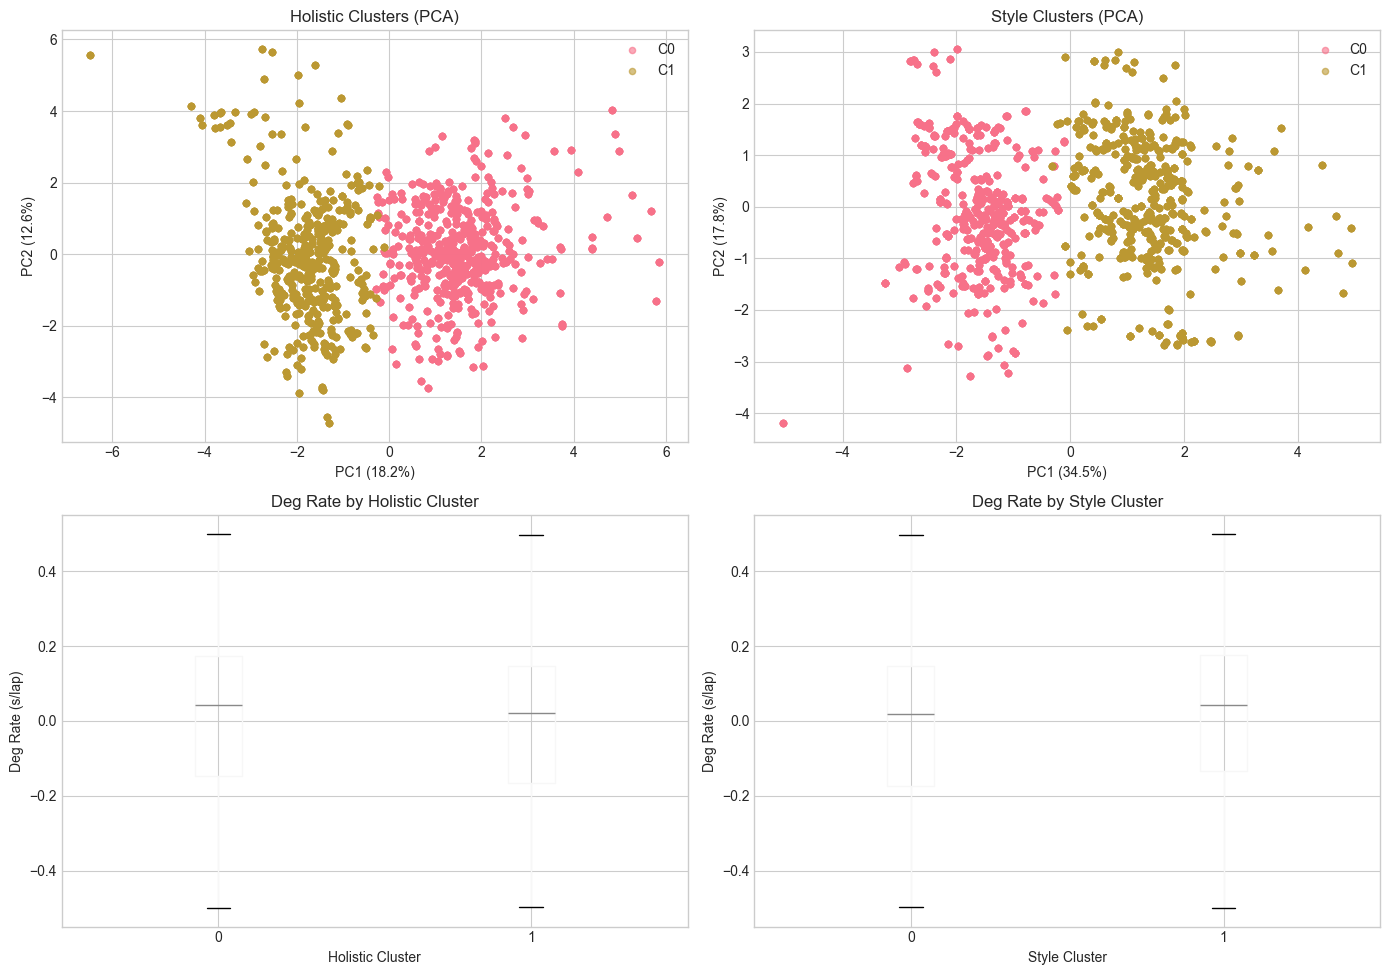

In [42]:
# Cell 11: PCA visualization + outcome boxplots
from sklearn.decomposition import PCA

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PCA for holistic
pca_h = PCA(n_components=2, random_state=42)
coords_h = pca_h.fit_transform(X_h_scaled)
ax = axes[0, 0]
for cl in sorted(df_h['cluster_holistic'].unique()):
    mask = df_h['cluster_holistic'] == cl
    ax.scatter(coords_h[mask, 0], coords_h[mask, 1], label=f'C{cl}', alpha=0.6, s=20)
ax.set_xlabel(f'PC1 ({pca_h.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_h.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Holistic Clusters (PCA)')
ax.legend()

# PCA for style
pca_s = PCA(n_components=2, random_state=42)
coords_s = pca_s.fit_transform(X_s_scaled)
ax = axes[0, 1]
for cl in sorted(df_s['cluster_style'].unique()):
    mask = df_s['cluster_style'] == cl
    ax.scatter(coords_s[mask, 0], coords_s[mask, 1], label=f'C{cl}', alpha=0.6, s=20)
ax.set_xlabel(f'PC1 ({pca_s.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_s.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Style Clusters (PCA)')
ax.legend()

# Outcome boxplots – deg_rate by cluster
ax = axes[1, 0]
df_h_outcome = df_h.merge(df[['stint_key', 'deg_rate_per_lap']], on='stint_key', how='left', suffixes=('', '_orig'))
deg_col = 'deg_rate_per_lap_orig' if 'deg_rate_per_lap_orig' in df_h_outcome.columns else 'deg_rate_per_lap'
df_h_outcome.boxplot(column=deg_col, by='cluster_holistic', ax=ax)
ax.set_xlabel('Holistic Cluster')
ax.set_ylabel('Deg Rate (s/lap)')
ax.set_title('Deg Rate by Holistic Cluster')
plt.suptitle('')

ax = axes[1, 1]
df_s_outcome = df_s.merge(df[['stint_key', 'deg_rate_per_lap']], on='stint_key', how='left', suffixes=('', '_orig'))
deg_col_s = 'deg_rate_per_lap_orig' if 'deg_rate_per_lap_orig' in df_s_outcome.columns else 'deg_rate_per_lap'
df_s_outcome.boxplot(column=deg_col_s, by='cluster_style', ax=ax)
ax.set_xlabel('Style Cluster')
ax.set_ylabel('Deg Rate (s/lap)')
ax.set_title('Deg Rate by Style Cluster')
plt.suptitle('')

plt.tight_layout()
plt.show()

HOLISTIC CLUSTER PROFILES (z-scored feature means)


cluster_holistic,0,1
deg_rate_per_lap,0.71,-0.71
circuit_baseline_deg,0.71,-0.71
team_baseline_deg,-0.71,0.71
driver_baseline_deg,0.71,-0.71
teammate_delta,0.71,-0.71
circuit_downforce_numeric,-0.71,0.71
speed_mean,-0.71,0.71
throttle_mean,0.71,-0.71
throttle_std,0.71,-0.71
throttle_p95,0.71,-0.71



STYLE CLUSTER PROFILES (z-scored feature means)


cluster_style,0,1
teammate_delta,-0.71,0.71
throttle_std,-0.71,0.71
throttle_p95,-0.71,0.71
brake_pct,-0.71,0.71
brake_std,-0.71,0.71
pos_x_std,0.71,-0.71
pos_y_std,0.71,-0.71
pos_z_std,-0.71,0.71


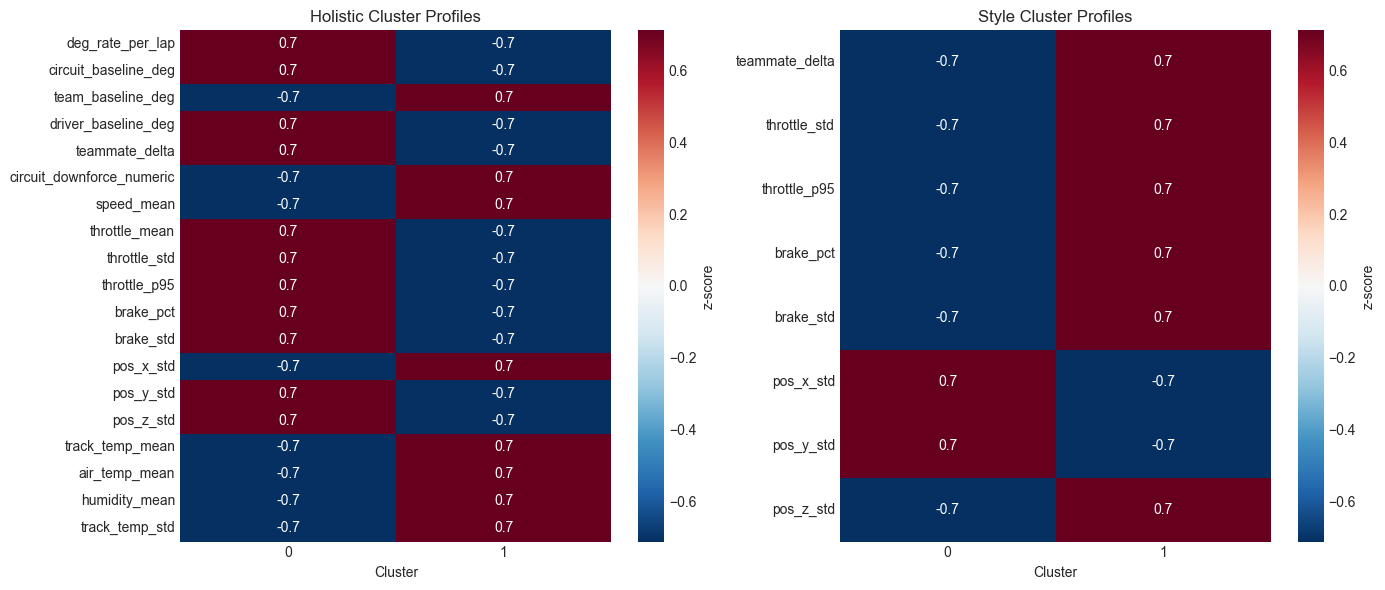


CLUSTER SUMMARY
Holistic: 2 clusters, sizes = [3784, 3304]
Style:    2 clusters, sizes = [3272, 3816]


In [43]:
# Cell 12: Cluster profiling (z-scored feature means)
def profile_clusters(df_features: pd.DataFrame, feature_cols: list, cluster_col: str) -> pd.DataFrame:
    """Return z-scored mean of each feature per cluster."""
    agg = df_features.groupby(cluster_col)[feature_cols].mean()
    # z-score across clusters (row-wise normalization)
    z = (agg - agg.mean()) / (agg.std() + 1e-9)
    return z.T.round(2)

print("=" * 60)
print("HOLISTIC CLUSTER PROFILES (z-scored feature means)")
print("=" * 60)
profile_h = profile_clusters(df_h, holistic_cols, 'cluster_holistic')
display(profile_h)

print("\n" + "=" * 60)
print("STYLE CLUSTER PROFILES (z-scored feature means)")
print("=" * 60)
profile_s = profile_clusters(df_s, style_cols, 'cluster_style')
display(profile_s)

# Heatmap visualization
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(holistic_cols)*0.3)))

ax = axes[0]
sns.heatmap(profile_h, cmap='RdBu_r', center=0, annot=True, fmt='.1f', ax=ax, cbar_kws={'label': 'z-score'})
ax.set_title('Holistic Cluster Profiles')
ax.set_xlabel('Cluster')

ax = axes[1]
sns.heatmap(profile_s, cmap='RdBu_r', center=0, annot=True, fmt='.1f', ax=ax, cbar_kws={'label': 'z-score'})
ax.set_title('Style Cluster Profiles')
ax.set_xlabel('Cluster')

plt.tight_layout()
plt.show()

# Summary stats
print("\n" + "=" * 60)
print("CLUSTER SUMMARY")
print("=" * 60)
print(f"Holistic: {best_k_h} clusters, sizes = {np.bincount(labels_h).tolist()}")
print(f"Style:    {best_k_s} clusters, sizes = {np.bincount(labels_s).tolist()}")

In [44]:
# Cell 13: DBSCAN and Gaussian Mixture Models (auto K-selection)
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# ============================================================
# DBSCAN - density-based, finds arbitrary-shaped clusters
# ============================================================
def find_best_dbscan(X_scaled, eps_range=np.arange(0.3, 2.0, 0.1), min_samples_range=[5, 10, 15, 20]):
    """Grid search for DBSCAN hyperparameters."""
    best_score, best_params, best_labels = -1, None, None
    results = []
    for eps in eps_range:
        for min_samples in min_samples_range:
            db = DBSCAN(eps=eps, min_samples=min_samples)
            labels = db.fit_predict(X_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = (labels == -1).sum()
            if n_clusters >= 2 and n_noise < len(X_scaled) * 0.5:  # at least 2 clusters, <50% noise
                try:
                    # Exclude noise points for silhouette
                    mask = labels != -1
                    if mask.sum() > n_clusters:
                        sil = silhouette_score(X_scaled[mask], labels[mask])
                        results.append({'eps': eps, 'min_samples': min_samples, 'n_clusters': n_clusters, 
                                       'n_noise': n_noise, 'noise_pct': n_noise/len(X_scaled)*100, 'silhouette': sil})
                        if sil > best_score:
                            best_score, best_params, best_labels = sil, (eps, min_samples), labels
                except:
                    pass
    return best_params, best_labels, pd.DataFrame(results)

print("=" * 60)
print("DBSCAN - Holistic Features")
print("=" * 60)
best_params_h, labels_dbscan_h, results_dbscan_h = find_best_dbscan(X_h_scaled)
if best_params_h:
    df_h['cluster_dbscan'] = labels_dbscan_h
    n_clusters_h = len(set(labels_dbscan_h)) - (1 if -1 in labels_dbscan_h else 0)
    n_noise_h = (labels_dbscan_h == -1).sum()
    print(f"Best params: eps={best_params_h[0]:.1f}, min_samples={best_params_h[1]}")
    print(f"Clusters: {n_clusters_h}, Noise points: {n_noise_h} ({n_noise_h/len(df_h)*100:.1f}%)")
    print(f"Cluster sizes: {np.bincount(labels_dbscan_h[labels_dbscan_h >= 0]).tolist()}")
    print("\nTop DBSCAN configs:")
    display(results_dbscan_h.sort_values('silhouette', ascending=False).head(10))
else:
    print("No valid DBSCAN configuration found")

print("\n" + "=" * 60)
print("DBSCAN - Style Features")
print("=" * 60)
best_params_s, labels_dbscan_s, results_dbscan_s = find_best_dbscan(X_s_scaled)
if best_params_s:
    df_s['cluster_dbscan'] = labels_dbscan_s
    n_clusters_s = len(set(labels_dbscan_s)) - (1 if -1 in labels_dbscan_s else 0)
    n_noise_s = (labels_dbscan_s == -1).sum()
    print(f"Best params: eps={best_params_s[0]:.1f}, min_samples={best_params_s[1]}")
    print(f"Clusters: {n_clusters_s}, Noise points: {n_noise_s} ({n_noise_s/len(df_s)*100:.1f}%)")
    print(f"Cluster sizes: {np.bincount(labels_dbscan_s[labels_dbscan_s >= 0]).tolist()}")
else:
    print("No valid DBSCAN configuration found")

DBSCAN - Holistic Features
Best params: eps=0.3, min_samples=5
Clusters: 849, Noise points: 0 (0.0%)
Cluster sizes: [8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 16, 8, 8, 8, 8, 24, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,

,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette
0,0.3,5,849,0,0.0,0.993433
1,0.4,5,834,0,0.0,0.988203
2,0.5,5,823,0,0.0,0.983787
3,0.6,5,802,0,0.0,0.970853
4,0.7,5,777,0,0.0,0.955683
5,0.8,5,761,0,0.0,0.944496
6,0.9,5,730,0,0.0,0.919558
7,1.0,5,697,0,0.0,0.894343
8,1.1,5,663,0,0.0,0.864146
9,1.2,5,632,0,0.0,0.835296



DBSCAN - Style Features
Best params: eps=0.3, min_samples=5
Clusters: 755, Noise points: 0 (0.0%)
Cluster sizes: [8, 8, 8, 8, 16, 8, 24, 8, 8, 8, 8, 8, 8, 8, 8, 16, 16, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 8, 32, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 24, 8, 8, 8, 8, 8, 16, 8, 8, 8, 8, 24, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 24, 8, 8, 8, 24, 16, 16, 8, 8, 8, 8, 8, 8, 16, 8, 8, 24, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 24, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 16, 8, 8, 32, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 16, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 8, 16, 8, 8, 8, 8, 8, 8, 16, 8, 8, 24, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 16, 8, 8, 16, 8, 8, 16, 8, 24, 8, 8, 8,

GMM - Holistic Features (BIC-based K selection)
Optimal K (by BIC): 9
Cluster sizes: [1568, 648, 1112, 360, 904, 392, 328, 800, 976]
Mean cluster confidence: 1.000

GMM K comparison:


,k,bic,aic,silhouette,sizes
0,2,231628.135172,228751.214763,0.146114,"[3800, 3288]"
1,3,199151.188840,194832.375148,0.159637,"[360, 3528, 3200]"
2,4,186523.316286,180762.609311,0.143902,"[584, 2144, 1056, 3304]"
3,5,159647.633368,152445.033110,0.111659,"[2224, 1224, 2008, 1272, 360]"
4,6,145341.473505,136696.979963,0.122236,"[1592, 1056, 2232, 384, 1264, 560]"
5,7,124781.774998,114695.388172,0.138574,"[1232, 368, 408, 1672, 552, 2288, 568]"
6,8,81500.120771,69971.840663,0.141674,"[2120, 648, 1136, 360, 864, 640, 528, 792]"
7,9,72200.421683,59230.248291,0.128593,"[1568, 648, 1112, 360, 904, 392, 328, 800, 976]"


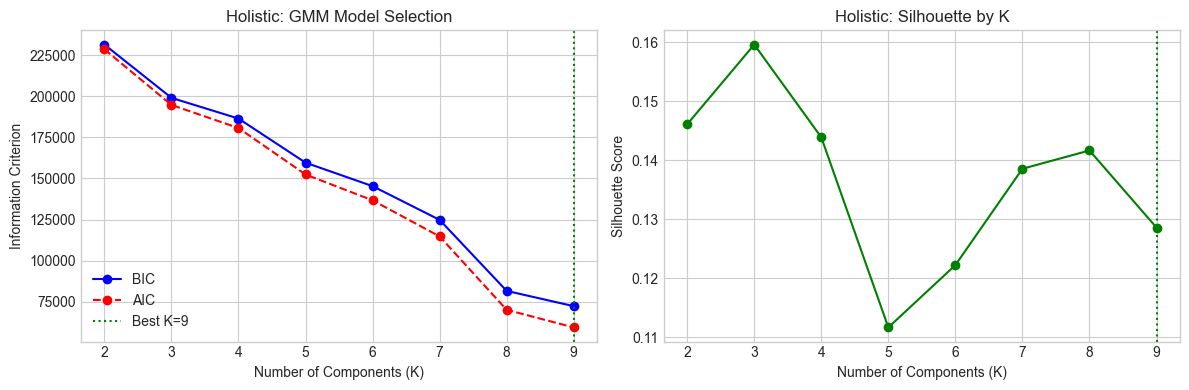


GMM - Style Features (BIC-based K selection)
Optimal K (by BIC): 9
Cluster sizes: [456, 760, 1656, 1360, 360, 672, 128, 1040, 656]
Mean cluster confidence: 0.975


In [45]:
# Cell 14: Gaussian Mixture Models (auto-select K via BIC)
# ============================================================
# GMM - soft clustering, uses BIC to select optimal K
# ============================================================
def find_best_gmm(X_scaled, k_range=range(2, 10), n_init=5):
    """Select best GMM using BIC (lower is better)."""
    results = []
    best_bic, best_k, best_gmm = np.inf, None, None
    for k in k_range:
        gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=n_init, random_state=42)
        gmm.fit(X_scaled)
        bic = gmm.bic(X_scaled)
        aic = gmm.aic(X_scaled)
        labels = gmm.predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        sizes = np.bincount(labels).tolist()
        results.append({'k': k, 'bic': bic, 'aic': aic, 'silhouette': sil, 'sizes': sizes})
        if bic < best_bic:
            best_bic, best_k, best_gmm = bic, k, gmm
    return best_k, best_gmm, pd.DataFrame(results)

print("=" * 60)
print("GMM - Holistic Features (BIC-based K selection)")
print("=" * 60)
best_k_gmm_h, gmm_h, results_gmm_h = find_best_gmm(X_h_scaled, k_range=range(2, 10))
labels_gmm_h = gmm_h.predict(X_h_scaled)
proba_gmm_h = gmm_h.predict_proba(X_h_scaled)
df_h['cluster_gmm'] = labels_gmm_h
df_h['cluster_gmm_confidence'] = proba_gmm_h.max(axis=1)

print(f"Optimal K (by BIC): {best_k_gmm_h}")
print(f"Cluster sizes: {np.bincount(labels_gmm_h).tolist()}")
print(f"Mean cluster confidence: {df_h['cluster_gmm_confidence'].mean():.3f}")
print("\nGMM K comparison:")
display(results_gmm_h)

# Plot BIC/AIC curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(results_gmm_h['k'], results_gmm_h['bic'], 'b-o', label='BIC')
ax.plot(results_gmm_h['k'], results_gmm_h['aic'], 'r--o', label='AIC')
ax.axvline(best_k_gmm_h, color='green', linestyle=':', label=f'Best K={best_k_gmm_h}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Holistic: GMM Model Selection')
ax.legend()

ax = axes[1]
ax.plot(results_gmm_h['k'], results_gmm_h['silhouette'], 'g-o')
ax.axvline(best_k_gmm_h, color='green', linestyle=':')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Holistic: Silhouette by K')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("GMM - Style Features (BIC-based K selection)")
print("=" * 60)
best_k_gmm_s, gmm_s, results_gmm_s = find_best_gmm(X_s_scaled, k_range=range(2, 10))
labels_gmm_s = gmm_s.predict(X_s_scaled)
proba_gmm_s = gmm_s.predict_proba(X_s_scaled)
df_s['cluster_gmm'] = labels_gmm_s
df_s['cluster_gmm_confidence'] = proba_gmm_s.max(axis=1)

print(f"Optimal K (by BIC): {best_k_gmm_s}")
print(f"Cluster sizes: {np.bincount(labels_gmm_s).tolist()}")
print(f"Mean cluster confidence: {df_s['cluster_gmm_confidence'].mean():.3f}")

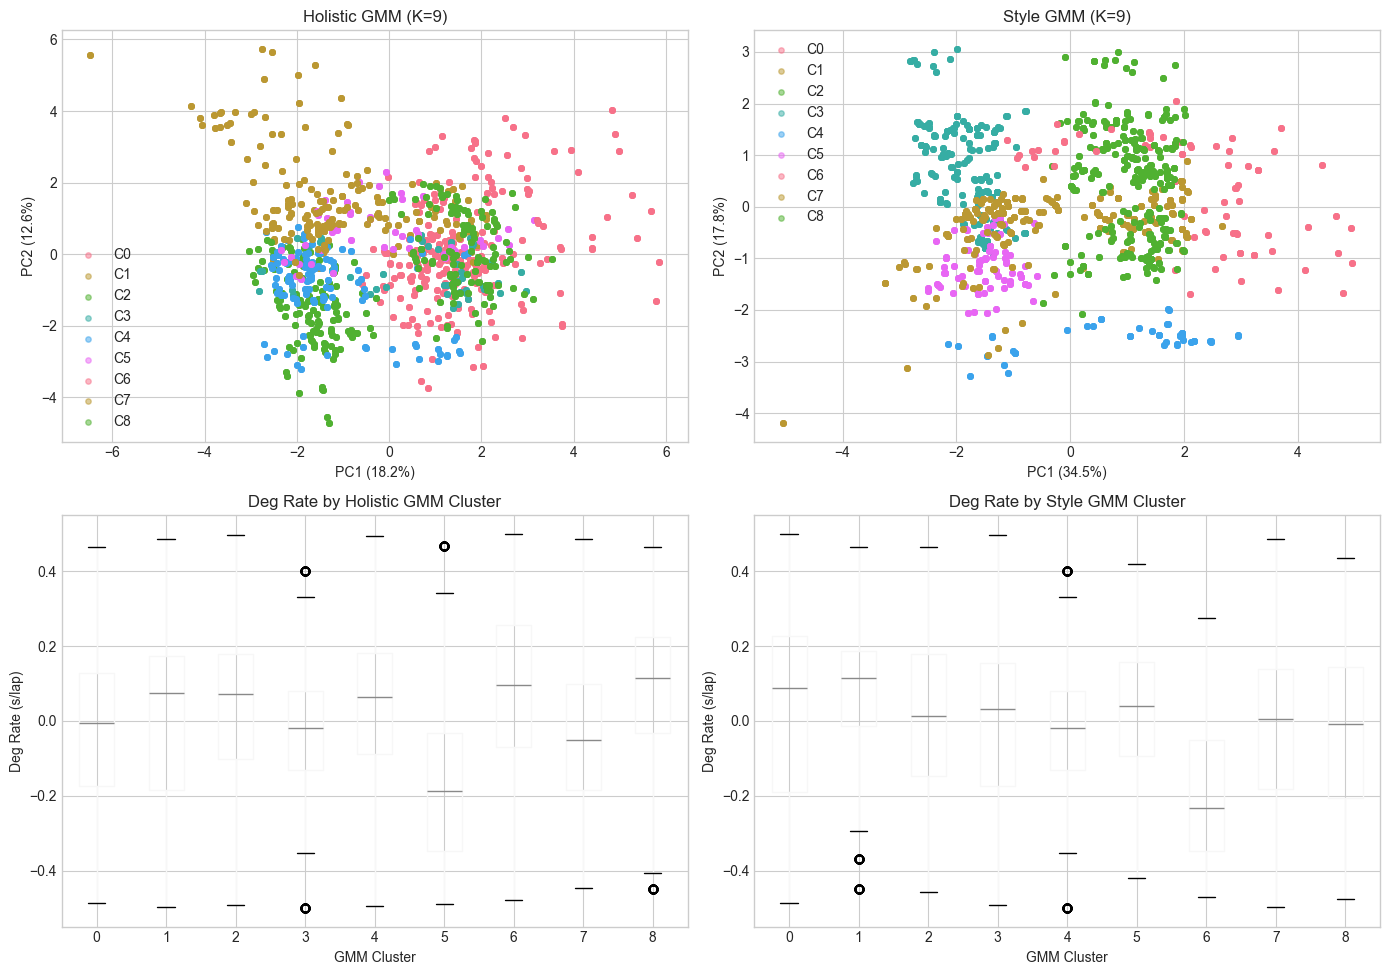

GMM HOLISTIC CLUSTER PROFILES (z-scored)


cluster_gmm,0,1,2,3,4,5,6,7,8
deg_rate_per_lap,-0.25,0.09,0.61,-0.22,0.61,-2.17,0.86,-0.64,1.12
circuit_baseline_deg,-0.03,0.07,0.60,-0.26,0.71,-2.40,0.17,0.00,1.13
team_baseline_deg,-0.57,-1.09,1.34,-0.65,-0.20,0.21,-1.27,1.29,0.94
driver_baseline_deg,-0.49,-0.10,0.40,-1.08,-0.15,-0.31,2.26,-1.00,0.46
teammate_delta,0.14,0.56,-0.44,0.11,0.02,0.11,-1.27,-1.27,2.05
circuit_downforce_numeric,0.03,0.71,-0.44,-1.60,1.68,-1.22,0.33,0.54,-0.04
speed_mean,0.30,-0.10,0.96,-0.43,0.18,1.44,-2.08,-0.52,0.26
throttle_mean,0.65,-0.36,-0.51,-0.57,-0.73,0.51,1.79,-1.52,0.75
throttle_std,0.89,-0.30,0.39,-0.82,-0.61,0.29,1.21,-1.91,0.85
throttle_p95,1.10,0.07,-1.31,0.53,-0.95,-0.61,1.10,-1.04,1.10



GMM STYLE CLUSTER PROFILES (z-scored)


cluster_gmm,0,1,2,3,4,5,6,7,8
teammate_delta,0.07,0.72,1.06,-0.20,0.32,0.35,-2.44,0.30,-0.17
throttle_std,0.93,0.41,1.11,0.67,-0.75,-0.36,-0.71,-1.92,0.62
throttle_p95,0.92,0.92,0.92,-1.17,0.42,-1.17,-0.64,-1.14,0.92
brake_pct,2.12,0.37,0.11,-1.30,0.22,-1.02,0.03,-0.75,0.21
brake_std,1.64,0.57,0.31,-1.62,0.36,-1.15,0.22,-0.76,0.42
pos_x_std,-0.17,-0.81,-0.85,-0.66,0.92,1.56,-0.45,-0.90,1.36
pos_y_std,-0.00,-0.67,0.44,0.64,-0.37,-0.79,2.24,-0.57,-0.93
pos_z_std,-0.27,0.12,-0.54,-0.22,2.61,-0.46,-0.44,-0.28,-0.52


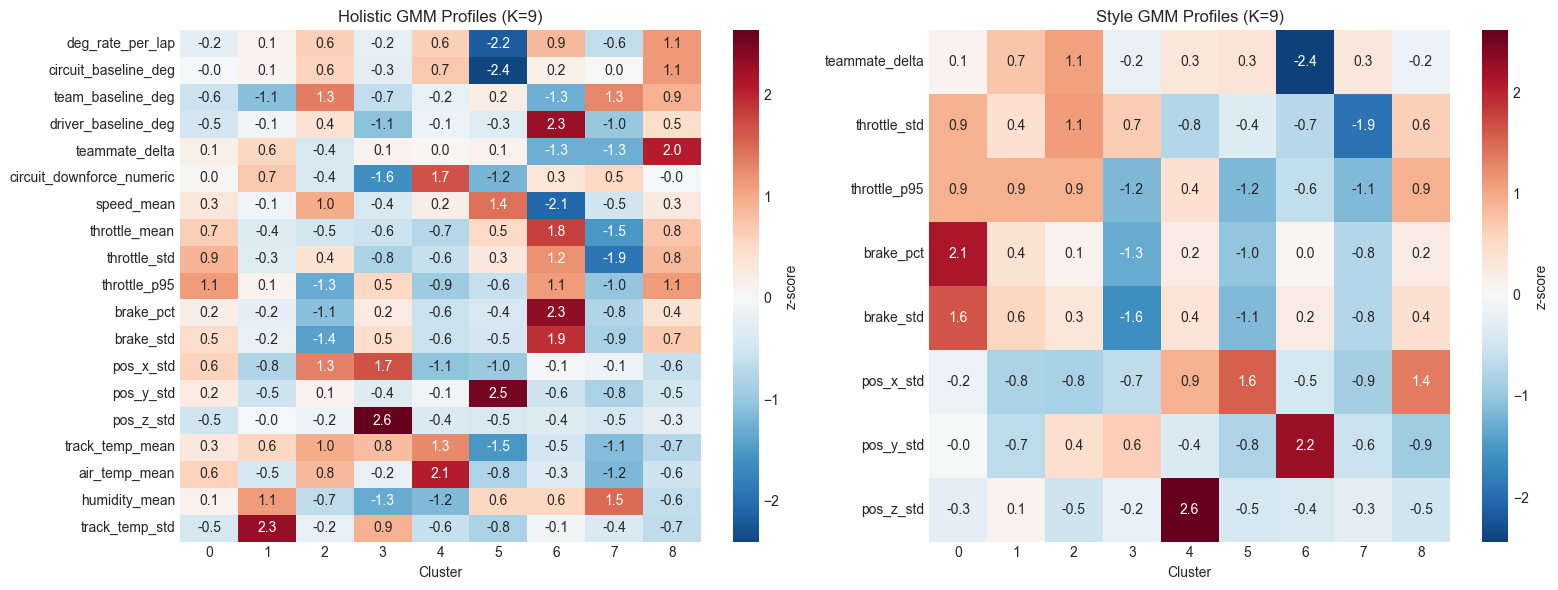

In [46]:
# Cell 15: GMM Cluster Visualization and Profiling
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PCA for GMM holistic
ax = axes[0, 0]
for cl in sorted(df_h['cluster_gmm'].unique()):
    mask = df_h['cluster_gmm'] == cl
    ax.scatter(coords_h[mask, 0], coords_h[mask, 1], label=f'C{cl}', alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca_h.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_h.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'Holistic GMM (K={best_k_gmm_h})')
ax.legend()

# PCA for GMM style
ax = axes[0, 1]
for cl in sorted(df_s['cluster_gmm'].unique()):
    mask = df_s['cluster_gmm'] == cl
    ax.scatter(coords_s[mask, 0], coords_s[mask, 1], label=f'C{cl}', alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca_s.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_s.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'Style GMM (K={best_k_gmm_s})')
ax.legend()

# Deg rate by GMM cluster - holistic
ax = axes[1, 0]
df_h_gmm_outcome = df_h.merge(df[['stint_key', 'deg_rate_per_lap']], on='stint_key', how='left', suffixes=('', '_orig'))
deg_col_gmm = 'deg_rate_per_lap_orig' if 'deg_rate_per_lap_orig' in df_h_gmm_outcome.columns else 'deg_rate_per_lap'
df_h_gmm_outcome.boxplot(column=deg_col_gmm, by='cluster_gmm', ax=ax)
ax.set_xlabel('GMM Cluster')
ax.set_ylabel('Deg Rate (s/lap)')
ax.set_title('Deg Rate by Holistic GMM Cluster')
plt.suptitle('')

# Deg rate by GMM cluster - style
ax = axes[1, 1]
df_s_gmm_outcome = df_s.merge(df[['stint_key', 'deg_rate_per_lap']], on='stint_key', how='left', suffixes=('', '_orig'))
deg_col_gmm_s = 'deg_rate_per_lap_orig' if 'deg_rate_per_lap_orig' in df_s_gmm_outcome.columns else 'deg_rate_per_lap'
df_s_gmm_outcome.boxplot(column=deg_col_gmm_s, by='cluster_gmm', ax=ax)
ax.set_xlabel('GMM Cluster')
ax.set_ylabel('Deg Rate (s/lap)')
ax.set_title('Deg Rate by Style GMM Cluster')
plt.suptitle('')

plt.tight_layout()
plt.show()

# GMM Cluster Profiles
print("=" * 60)
print("GMM HOLISTIC CLUSTER PROFILES (z-scored)")
print("=" * 60)
profile_gmm_h = profile_clusters(df_h, holistic_cols, 'cluster_gmm')
display(profile_gmm_h)

print("\n" + "=" * 60)
print("GMM STYLE CLUSTER PROFILES (z-scored)")
print("=" * 60)
profile_gmm_s = profile_clusters(df_s, style_cols, 'cluster_gmm')
display(profile_gmm_s)

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(holistic_cols)*0.3)))
ax = axes[0]
sns.heatmap(profile_gmm_h, cmap='RdBu_r', center=0, annot=True, fmt='.1f', ax=ax, cbar_kws={'label': 'z-score'})
ax.set_title(f'Holistic GMM Profiles (K={best_k_gmm_h})')
ax.set_xlabel('Cluster')

ax = axes[1]
sns.heatmap(profile_gmm_s, cmap='RdBu_r', center=0, annot=True, fmt='.1f', ax=ax, cbar_kws={'label': 'z-score'})
ax.set_title(f'Style GMM Profiles (K={best_k_gmm_s})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

## Part 2: Stint Shape Clustering (Degradation Curve Archetypes)

Cluster stints by the **shape** of their degradation curve, not just summary statistics.
This reveals patterns like:
- Linear degraders (steady slope)
- Cliff fallers (sudden drop-off)
- Progressive accelerators (increasing deg rate)
- Graining recovery (initial drop, then stabilization)

In [48]:
# Cell 16: Extract stint shape features from lap-level data
def extract_shape_features(group: pd.DataFrame) -> dict:
    """Extract degradation curve shape features from a stint's lap times."""
    g = group.sort_values('lap_number').dropna(subset=['lap_time_s'])
    
    # Return NaN-filled dict for short stints (instead of empty dict)
    empty_result = {
        'shape_slope_early': np.nan, 'shape_slope_mid': np.nan, 'shape_slope_late': np.nan,
        'shape_slope_overall': np.nan, 'shape_curvature': np.nan, 'shape_linearity_r2': np.nan,
        'shape_max_delta': np.nan, 'shape_min_delta': np.nan, 'shape_delta_std': np.nan,
        'shape_has_cliff': np.nan, 'shape_cliff_lap': np.nan, 'shape_has_recovery': np.nan,
        'shape_slope_change_mid': np.nan, 'shape_worst_lap_pos': np.nan,
        'shape_early_stability': np.nan, 'shape_late_volatility': np.nan, 'shape_n_laps': 0
    }
    
    if len(g) < 6:
        return empty_result
    
    # Get tyre life or use lap index
    x = g['tyre_life'].to_numpy() if 'tyre_life' in g.columns else np.arange(len(g), dtype=float)
    if np.isnan(x).all():
        x = np.arange(len(g), dtype=float)
    
    # Fuel-corrected lap times (in seconds)
    y = g['lap_time_s'].to_numpy(dtype=float)
    y_corr = y + (x * FUEL_EFFECT_PER_LAP)
    
    n = len(y_corr)
    
    # Split into thirds
    third = max(2, n // 3)
    x_early, y_early = x[:third], y_corr[:third]
    x_mid, y_mid = x[third:2*third], y_corr[third:2*third]
    x_late, y_late = x[2*third:], y_corr[2*third:]
    
    def safe_slope(xx, yy):
        if len(xx) < 2:
            return np.nan
        try:
            return float(np.polyfit(xx, yy, 1)[0])
        except:
            return np.nan
    
    def safe_r2(xx, yy):
        if len(xx) < 3:
            return np.nan
        try:
            slope, intercept = np.polyfit(xx, yy, 1)
            y_pred = slope * xx + intercept
            ss_res = np.sum((yy - y_pred) ** 2)
            ss_tot = np.sum((yy - np.mean(yy)) ** 2)
            return 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
        except:
            return np.nan
    
    # Segment slopes (seconds per lap)
    slope_early = safe_slope(x_early, y_early)
    slope_mid = safe_slope(x_mid, y_mid)
    slope_late = safe_slope(x_late, y_late)
    slope_overall = safe_slope(x, y_corr)
    
    # Curvature: acceleration of degradation
    curvature = (slope_late - slope_early) if np.isfinite(slope_late) and np.isfinite(slope_early) else np.nan
    
    # Linearity: how well does a linear fit explain the curve?
    linearity_r2 = safe_r2(x, y_corr)
    
    # Lap-to-lap deltas
    deltas = np.diff(y_corr)
    max_delta = float(np.max(deltas)) if len(deltas) > 0 else np.nan
    min_delta = float(np.min(deltas)) if len(deltas) > 0 else np.nan
    delta_std = float(np.std(deltas)) if len(deltas) > 0 else np.nan
    
    # Cliff detection: sudden large increase (>0.5s in one lap)
    cliff_threshold = 0.5
    has_cliff = int(np.any(deltas > cliff_threshold)) if len(deltas) > 0 else 0
    cliff_lap = int(np.argmax(deltas) + 1) if len(deltas) > 0 and np.max(deltas) > cliff_threshold else -1
    
    # Recovery detection: times improved mid-stint (graining burn-off)
    has_recovery = int(np.any(deltas < -0.2)) if len(deltas) > 0 else 0
    
    # Inflection point: where does slope change most?
    if n >= 6:
        half = n // 2
        slope_first_half = safe_slope(x[:half], y_corr[:half])
        slope_second_half = safe_slope(x[half:], y_corr[half:])
        slope_change_at_mid = abs(slope_second_half - slope_first_half) if np.isfinite(slope_first_half) and np.isfinite(slope_second_half) else np.nan
    else:
        slope_change_at_mid = np.nan
    
    # Normalized position of worst lap (0=early, 1=late)
    worst_lap_position = float(np.argmax(y_corr) / (n - 1)) if n > 1 else np.nan
    
    # Early stability: std of first 1/3
    early_stability = float(np.std(y_early)) if len(y_early) > 1 else np.nan
    
    # Late volatility: std of last 1/3
    late_volatility = float(np.std(y_late)) if len(y_late) > 1 else np.nan
    
    return {
        'shape_slope_early': slope_early,
        'shape_slope_mid': slope_mid,
        'shape_slope_late': slope_late,
        'shape_slope_overall': slope_overall,
        'shape_curvature': curvature,
        'shape_linearity_r2': linearity_r2,
        'shape_max_delta': max_delta,
        'shape_min_delta': min_delta,
        'shape_delta_std': delta_std,
        'shape_has_cliff': has_cliff,
        'shape_cliff_lap': cliff_lap,
        'shape_has_recovery': has_recovery,
        'shape_slope_change_mid': slope_change_at_mid,
        'shape_worst_lap_pos': worst_lap_position,
        'shape_early_stability': early_stability,
        'shape_late_volatility': late_volatility,
        'shape_n_laps': n
    }

# Extract shape features for all stints
print("Extracting stint shape features...")
shape_features = laps.groupby('stint_key', sort=False).apply(
    lambda g: pd.Series(extract_shape_features(g)), include_groups=False
).reset_index()

# Remove stints with no features (too short)
shape_features = shape_features[shape_features['shape_n_laps'] >= 6]
print(f"Shape features extracted: {len(shape_features)} stints")
print(f"Columns: {[c for c in shape_features.columns if c.startswith('shape_')]}")

Extracting stint shape features...
Shape features extracted: 1710 stints
Columns: ['shape_slope_early', 'shape_slope_mid', 'shape_slope_late', 'shape_slope_overall', 'shape_curvature', 'shape_linearity_r2', 'shape_max_delta', 'shape_min_delta', 'shape_delta_std', 'shape_has_cliff', 'shape_cliff_lap', 'shape_has_recovery', 'shape_slope_change_mid', 'shape_worst_lap_pos', 'shape_early_stability', 'shape_late_volatility', 'shape_n_laps']


Using 13 shape features: ['shape_slope_early', 'shape_slope_mid', 'shape_slope_late', 'shape_curvature', 'shape_linearity_r2', 'shape_max_delta', 'shape_delta_std', 'shape_has_cliff', 'shape_has_recovery', 'shape_slope_change_mid', 'shape_worst_lap_pos', 'shape_early_stability', 'shape_late_volatility']
Shape matrix: 1710 stints × 13 features

Running GMM for shape clustering...

Optimal K (by BIC): 10
Cluster sizes: [202, 485, 436, 15, 9, 76, 122, 84, 148, 133]
Mean cluster confidence: 0.974


,k,bic,aic,silhouette,sizes
0,2,2518.646235,1380.798267,0.269030,"[208, 1502]"
1,3,-10378.017968,-12087.512044,0.293720,"[1321, 198, 191]"
2,4,-30300.642066,-32581.782251,0.262228,"[198, 1054, 342, 116]"
3,5,-30947.984113,-33800.770405,0.280697,"[361, 992, 16, 187, 154]"
4,6,-34315.624376,-37740.056776,0.229654,"[206, 316, 598, 10, 94, 486]"
5,7,-34606.346009,-38602.424518,0.242033,"[206, 749, 8, 325, 56, 351, 15]"
6,8,-35968.158020,-40535.882637,0.185241,"[206, 436, 8, 522, 322, 15, 48, 153]"
7,9,-35709.816512,-40849.187237,0.168471,"[206, 405, 4, 468, 322, 15, 48, 229, 13]"
8,10,-39552.012086,-45263.028920,0.206673,"[202, 485, 436, 15, 9, 76, 122, 84, 148, 133]"
9,11,-39482.327557,-45764.990499,0.179855,"[124, 15, 271, 84, 268, 301, 9, 14, 377, 122, ..."


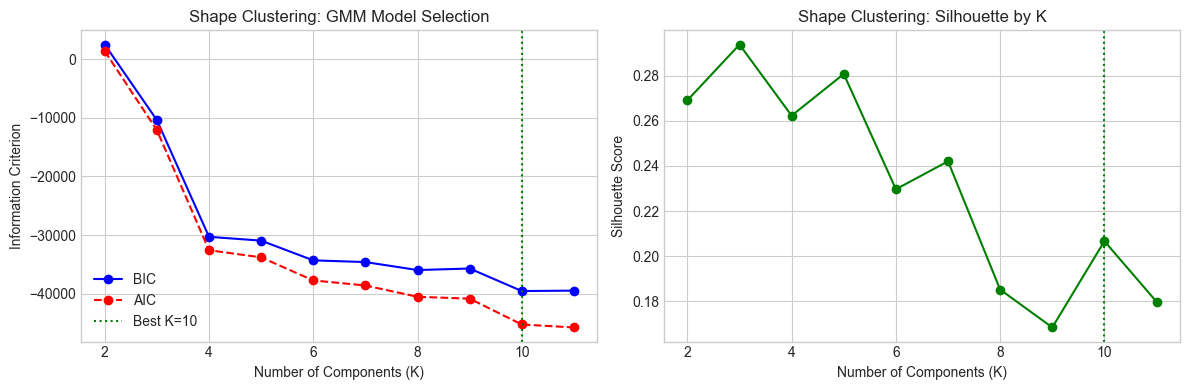

In [49]:
# Cell 17: Prepare shape feature matrix and run GMM clustering
shape_cols = [
    'shape_slope_early', 'shape_slope_mid', 'shape_slope_late',
    'shape_curvature', 'shape_linearity_r2',
    'shape_max_delta', 'shape_delta_std',
    'shape_has_cliff', 'shape_has_recovery',
    'shape_slope_change_mid', 'shape_worst_lap_pos',
    'shape_early_stability', 'shape_late_volatility'
]

# Keep only existing columns
shape_cols = [c for c in shape_cols if c in shape_features.columns]
print(f"Using {len(shape_cols)} shape features: {shape_cols}")

# Prepare feature matrix
df_shape = shape_features[['stint_key'] + shape_cols].copy()
df_shape = df_shape.dropna(thresh=int(len(shape_cols) * 0.7))
df_shape[shape_cols] = df_shape[shape_cols].apply(lambda c: c.fillna(c.median()))

print(f"Shape matrix: {len(df_shape)} stints × {len(shape_cols)} features")

# Scale features
X_shape = df_shape[shape_cols].values
scaler_shape = StandardScaler()
X_shape_scaled = scaler_shape.fit_transform(X_shape)

# GMM with BIC-based K selection
print("\nRunning GMM for shape clustering...")
best_k_shape, gmm_shape, results_gmm_shape = find_best_gmm(X_shape_scaled, k_range=range(2, 12))
labels_shape = gmm_shape.predict(X_shape_scaled)
proba_shape = gmm_shape.predict_proba(X_shape_scaled)
df_shape['cluster_shape'] = labels_shape
df_shape['cluster_shape_confidence'] = proba_shape.max(axis=1)

print(f"\nOptimal K (by BIC): {best_k_shape}")
print(f"Cluster sizes: {np.bincount(labels_shape).tolist()}")
print(f"Mean cluster confidence: {df_shape['cluster_shape_confidence'].mean():.3f}")

# Display GMM comparison
display(results_gmm_shape)

# Plot BIC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(results_gmm_shape['k'], results_gmm_shape['bic'], 'b-o', label='BIC')
ax.plot(results_gmm_shape['k'], results_gmm_shape['aic'], 'r--o', label='AIC')
ax.axvline(best_k_shape, color='green', linestyle=':', label=f'Best K={best_k_shape}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Shape Clustering: GMM Model Selection')
ax.legend()

ax = axes[1]
ax.plot(results_gmm_shape['k'], results_gmm_shape['silhouette'], 'g-o')
ax.axvline(best_k_shape, color='green', linestyle=':')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Shape Clustering: Silhouette by K')
plt.tight_layout()
plt.show()

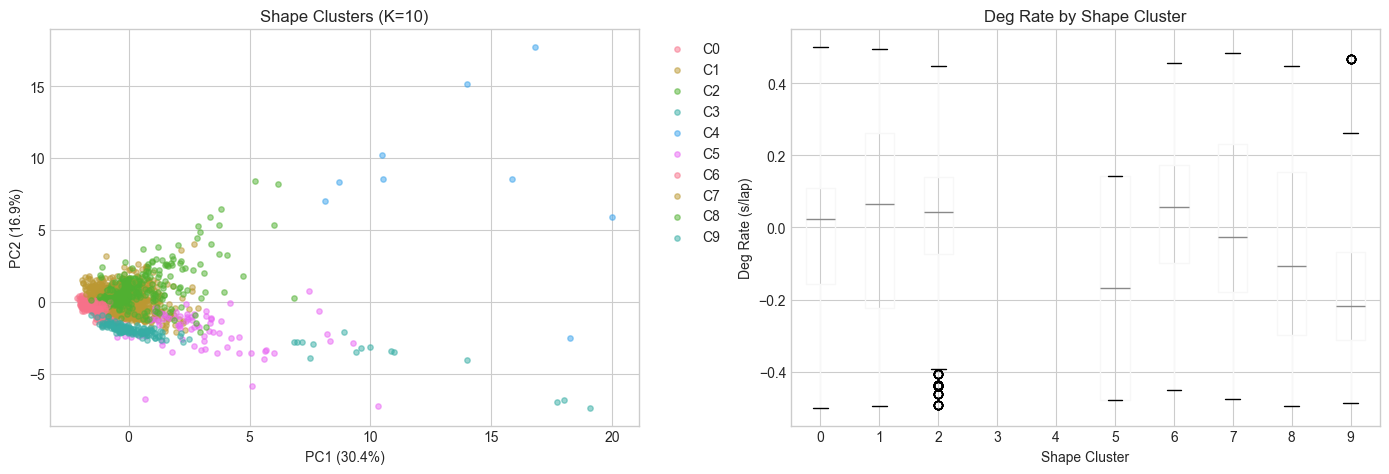

PCA variance explained: PC1=30.4%, PC2=16.9%


In [50]:
# Cell 18: PCA visualization of shape clusters
pca_shape = PCA(n_components=2, random_state=42)
coords_shape = pca_shape.fit_transform(X_shape_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
ax = axes[0]
for cl in sorted(df_shape['cluster_shape'].unique()):
    mask = df_shape['cluster_shape'] == cl
    ax.scatter(coords_shape[mask, 0], coords_shape[mask, 1], label=f'C{cl}', alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca_shape.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_shape.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'Shape Clusters (K={best_k_shape})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Deg rate outcome by shape cluster
ax = axes[1]
df_shape_outcome = df_shape.merge(df[['stint_key', 'deg_rate_per_lap']], on='stint_key', how='left')
df_shape_outcome.boxplot(column='deg_rate_per_lap', by='cluster_shape', ax=ax)
ax.set_xlabel('Shape Cluster')
ax.set_ylabel('Deg Rate (s/lap)')
ax.set_title('Deg Rate by Shape Cluster')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Show variance explained by PCA
print(f"PCA variance explained: PC1={pca_shape.explained_variance_ratio_[0]*100:.1f}%, PC2={pca_shape.explained_variance_ratio_[1]*100:.1f}%")

SHAPE CLUSTER PROFILES (z-scored feature means)


cluster_shape,0,1,2,3,4,5,6,7,8,9
shape_slope_early,0.55,0.53,0.60,-2.11,-1.07,-0.90,0.62,0.78,0.74,0.26
shape_slope_mid,-0.07,-0.07,-0.06,-0.26,2.55,-1.42,-0.05,0.21,-0.51,-0.31
shape_slope_late,-0.34,-0.32,-0.31,-0.33,2.84,-0.39,-0.30,-0.11,-0.35,-0.38
shape_curvature,-0.54,-0.52,-0.55,1.07,2.39,0.30,-0.56,-0.54,-0.66,-0.39
shape_linearity_r2,0.30,-0.60,0.74,-1.53,-0.18,0.34,1.27,1.49,-0.87,-0.96
shape_max_delta,-0.50,-0.22,-0.28,-0.29,2.77,-0.39,-0.52,-0.34,0.29,-0.52
shape_delta_std,-0.59,-0.43,-0.51,2.39,1.21,-0.21,-0.62,-0.56,-0.13,-0.54
shape_has_cliff,-1.39,0.79,0.79,0.21,0.79,0.02,-1.39,0.79,0.79,-1.39
shape_has_recovery,0.53,0.53,0.53,0.53,0.00,0.53,-1.87,-1.87,0.53,0.53
shape_slope_change_mid,-0.56,-0.49,-0.59,0.54,2.63,0.21,-0.58,-0.50,-0.21,-0.44


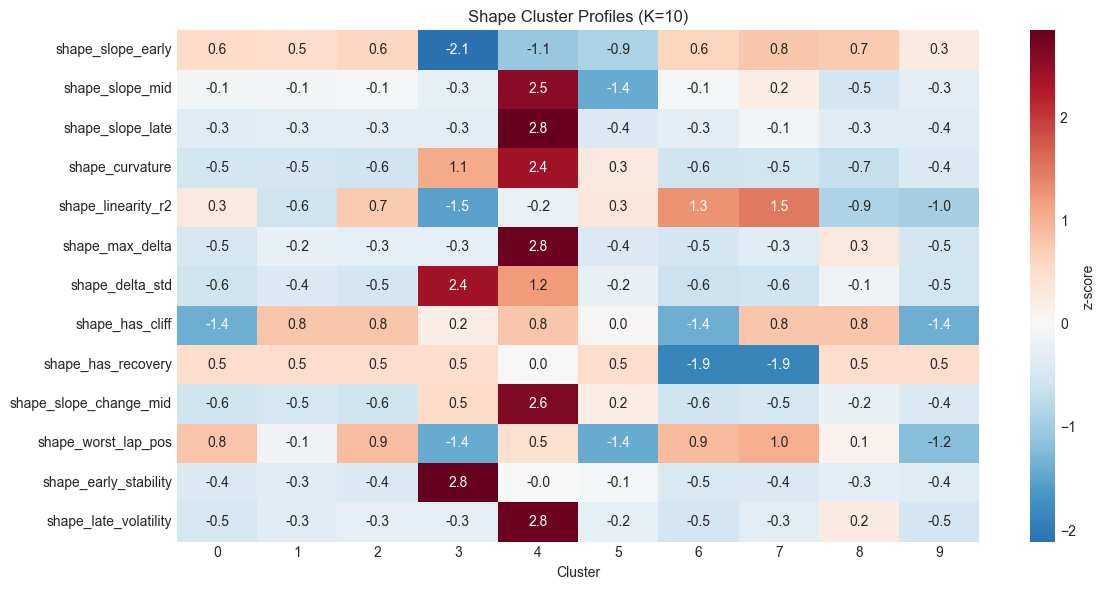


ARCHETYPE INTERPRETATION
Cluster 0 (n=202): Decelerating (improving) | Recovery/graining
Cluster 1 (n=485): Decelerating (improving) | Non-linear/erratic | Cliff risk | Recovery/graining
Cluster 2 (n=436): Decelerating (improving) | Linear pattern | Cliff risk | Recovery/graining
Cluster 3 (n=15): Progressive (accelerating deg) | Non-linear/erratic | Recovery/graining
Cluster 4 (n=9): Progressive (accelerating deg) | Cliff risk | High late-stint deg
Cluster 5 (n=76): Recovery/graining
Cluster 6 (n=122): Decelerating (improving) | Linear pattern | Stable throughout
Cluster 7 (n=84): Decelerating (improving) | Linear pattern | Cliff risk | High early-stint deg
Cluster 8 (n=148): Decelerating (improving) | Non-linear/erratic | Cliff risk | Recovery/graining | High early-stint deg
Cluster 9 (n=133): Non-linear/erratic | Recovery/graining | Stable throughout


In [51]:
# Cell 19: Shape cluster profiling and archetype labeling
print("=" * 70)
print("SHAPE CLUSTER PROFILES (z-scored feature means)")
print("=" * 70)

profile_shape = profile_clusters(df_shape, shape_cols, 'cluster_shape')
display(profile_shape)

# Heatmap
fig, ax = plt.subplots(figsize=(max(10, best_k_shape * 1.2), max(6, len(shape_cols) * 0.4)))
sns.heatmap(profile_shape, cmap='RdBu_r', center=0, annot=True, fmt='.1f', ax=ax, cbar_kws={'label': 'z-score'})
ax.set_title(f'Shape Cluster Profiles (K={best_k_shape})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Interpret clusters based on profile
print("\n" + "=" * 70)
print("ARCHETYPE INTERPRETATION")
print("=" * 70)

def interpret_shape_cluster(profile_row: pd.Series) -> str:
    """Interpret a cluster's shape based on its feature profile."""
    interpretations = []
    
    # Curvature interpretation
    if profile_row.get('shape_curvature', 0) > 0.5:
        interpretations.append("Progressive (accelerating deg)")
    elif profile_row.get('shape_curvature', 0) < -0.5:
        interpretations.append("Decelerating (improving)")
    
    # Linearity interpretation
    if profile_row.get('shape_linearity_r2', 0) > 0.5:
        interpretations.append("Linear pattern")
    elif profile_row.get('shape_linearity_r2', 0) < -0.5:
        interpretations.append("Non-linear/erratic")
    
    # Cliff interpretation
    if profile_row.get('shape_has_cliff', 0) > 0.5:
        interpretations.append("Cliff risk")
    
    # Recovery interpretation
    if profile_row.get('shape_has_recovery', 0) > 0.5:
        interpretations.append("Recovery/graining")
    
    # Slope patterns
    if profile_row.get('shape_slope_late', 0) > 0.7:
        interpretations.append("High late-stint deg")
    elif profile_row.get('shape_slope_early', 0) > 0.7:
        interpretations.append("High early-stint deg")
    
    # Stability
    if profile_row.get('shape_early_stability', 0) < -0.5 and profile_row.get('shape_late_volatility', 0) > 0.5:
        interpretations.append("Stable start → volatile end")
    elif profile_row.get('shape_late_volatility', 0) < -0.5:
        interpretations.append("Stable throughout")
    
    return " | ".join(interpretations) if interpretations else "Baseline/mixed"

for cluster_id in sorted(df_shape['cluster_shape'].unique()):
    profile_row = profile_shape[cluster_id]
    interpretation = interpret_shape_cluster(profile_row)
    size = (df_shape['cluster_shape'] == cluster_id).sum()
    print(f"Cluster {cluster_id} (n={size}): {interpretation}")

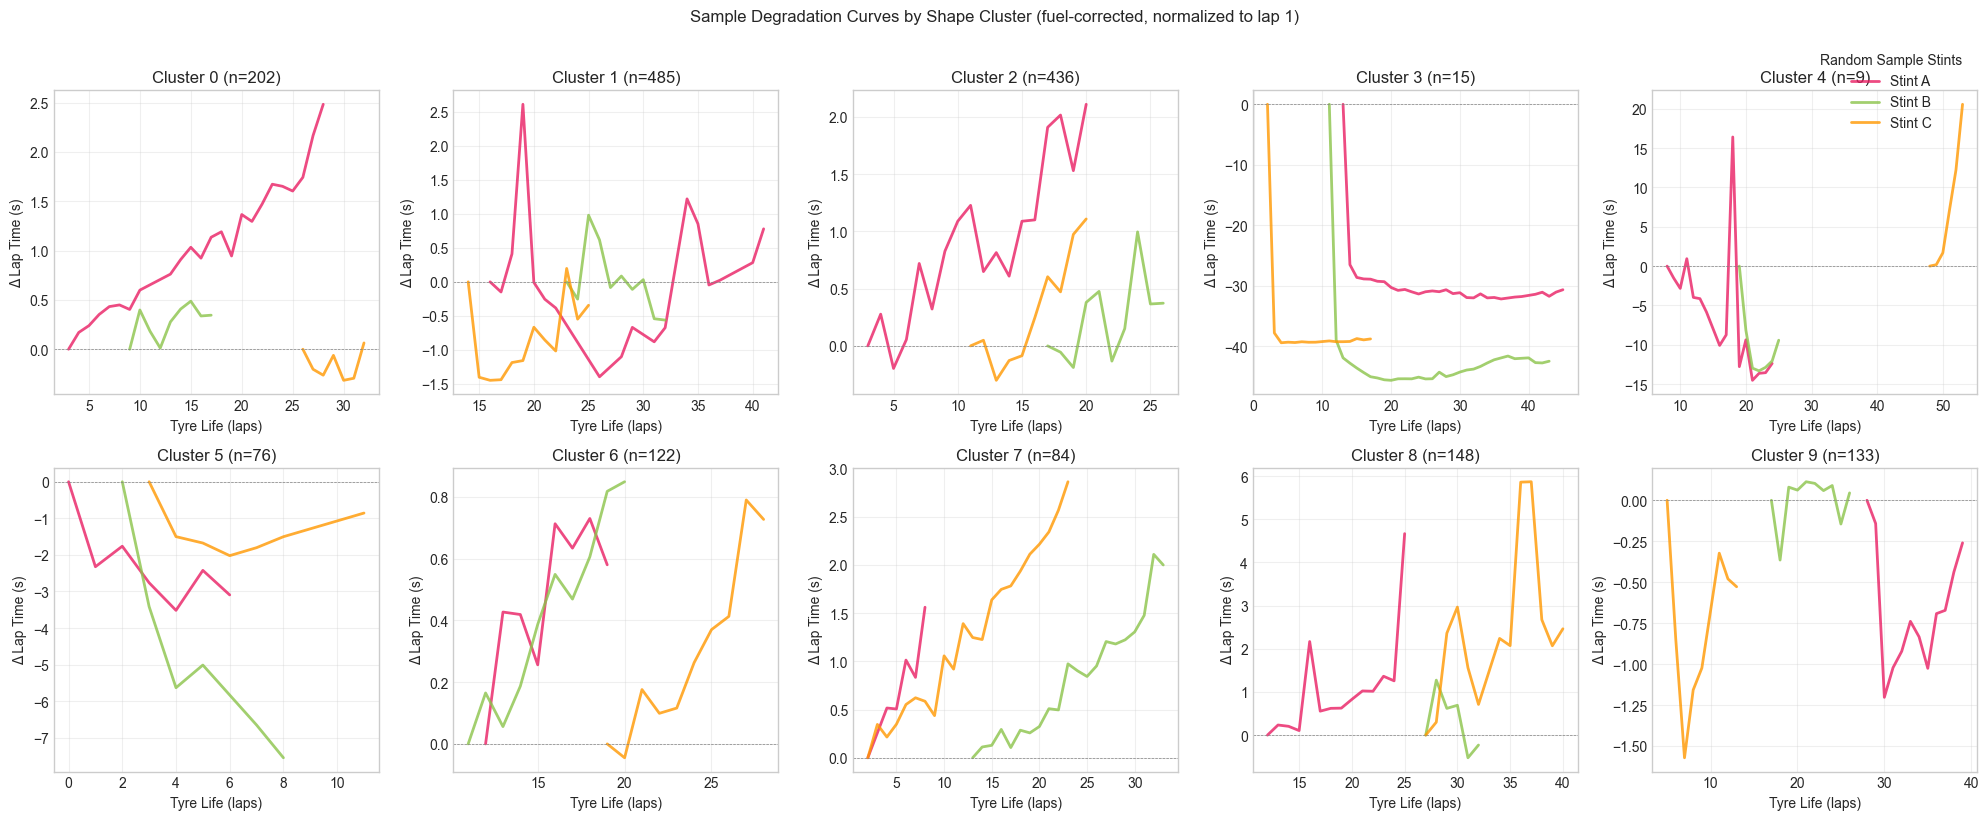

Each colored line represents ONE randomly sampled stint from that cluster:
  • Pink (Stint A), Green (Stint B), Orange (Stint C)
  • Y-axis: Time delta vs first lap (positive = slower, negative = faster)
  • X-axis: Tyre life in laps


In [54]:
# Cell 20: Visualize example degradation curves per cluster
# Sample 3 stints from each cluster and plot their actual lap time curves
# Each colored line = 1 randomly sampled stint from that cluster

fig, axes = plt.subplots(2, min(5, best_k_shape), figsize=(4 * min(5, best_k_shape), 8))
if best_k_shape <= 5:
    axes = axes.reshape(2, -1)

n_samples = 3
clusters_to_show = sorted(df_shape['cluster_shape'].unique())[:10]
colors = ['#E91E63', '#8BC34A', '#FF9800']  # Pink, Green, Orange
stint_labels = ['Stint A', 'Stint B', 'Stint C']

for idx, cluster_id in enumerate(clusters_to_show[:5]):
    ax_row = idx // 5
    ax_col = idx % 5
    ax = axes[0, ax_col] if best_k_shape > 5 else axes[0, idx]
    
    # Get stint keys for this cluster
    cluster_stints = df_shape[df_shape['cluster_shape'] == cluster_id]['stint_key'].values
    np.random.seed(42)  # For reproducibility
    sample_stints = np.random.choice(cluster_stints, size=min(n_samples, len(cluster_stints)), replace=False)
    
    for i, stint in enumerate(sample_stints):
        stint_laps = laps[laps['stint_key'] == stint].sort_values('lap_number')
        if len(stint_laps) < 4:
            continue
        x = stint_laps['tyre_life'].values if 'tyre_life' in stint_laps.columns else np.arange(len(stint_laps))
        if np.isnan(x).all():
            x = np.arange(len(stint_laps))
        y = stint_laps['lap_time_s'].values + (x * FUEL_EFFECT_PER_LAP)
        # Normalize to first lap for comparison
        y_norm = y - y[0]
        ax.plot(x, y_norm, alpha=0.8, linewidth=2, color=colors[i % len(colors)], 
                label=stint_labels[i] if idx == 0 else None)
    
    ax.set_title(f'Cluster {cluster_id} (n={len(cluster_stints)})')
    ax.set_xlabel('Tyre Life (laps)')
    ax.set_ylabel('Δ Lap Time (s)')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.grid(True, alpha=0.3)

# Show remaining clusters in second row
for idx, cluster_id in enumerate(clusters_to_show[5:10]):
    ax = axes[1, idx]
    
    cluster_stints = df_shape[df_shape['cluster_shape'] == cluster_id]['stint_key'].values
    np.random.seed(42)
    sample_stints = np.random.choice(cluster_stints, size=min(n_samples, len(cluster_stints)), replace=False)
    
    for i, stint in enumerate(sample_stints):
        stint_laps = laps[laps['stint_key'] == stint].sort_values('lap_number')
        if len(stint_laps) < 4:
            continue
        x = stint_laps['tyre_life'].values if 'tyre_life' in stint_laps.columns else np.arange(len(stint_laps))
        if np.isnan(x).all():
            x = np.arange(len(stint_laps))
        y = stint_laps['lap_time_s'].values + (x * FUEL_EFFECT_PER_LAP)
        y_norm = y - y[0]
        ax.plot(x, y_norm, alpha=0.8, linewidth=2, color=colors[i % len(colors)])
    
    ax.set_title(f'Cluster {cluster_id} (n={len(cluster_stints)})')
    ax.set_xlabel('Tyre Life (laps)')
    ax.set_ylabel('Δ Lap Time (s)')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for idx in range(len(clusters_to_show[5:10]), 5):
    axes[1, idx].set_visible(False)

# Add legend to explain what the lines represent
fig.legend(stint_labels, loc='upper right', bbox_to_anchor=(0.99, 0.98), 
           title='Random Sample Stints', framealpha=0.9)

plt.suptitle('Sample Degradation Curves by Shape Cluster (fuel-corrected, normalized to lap 1)', y=1.02)
plt.tight_layout()
plt.show()

print("Each colored line represents ONE randomly sampled stint from that cluster:")
print("  • Pink (Stint A), Green (Stint B), Orange (Stint C)")
print("  • Y-axis: Time delta vs first lap (positive = slower, negative = faster)")
print("  • X-axis: Tyre life in laps")

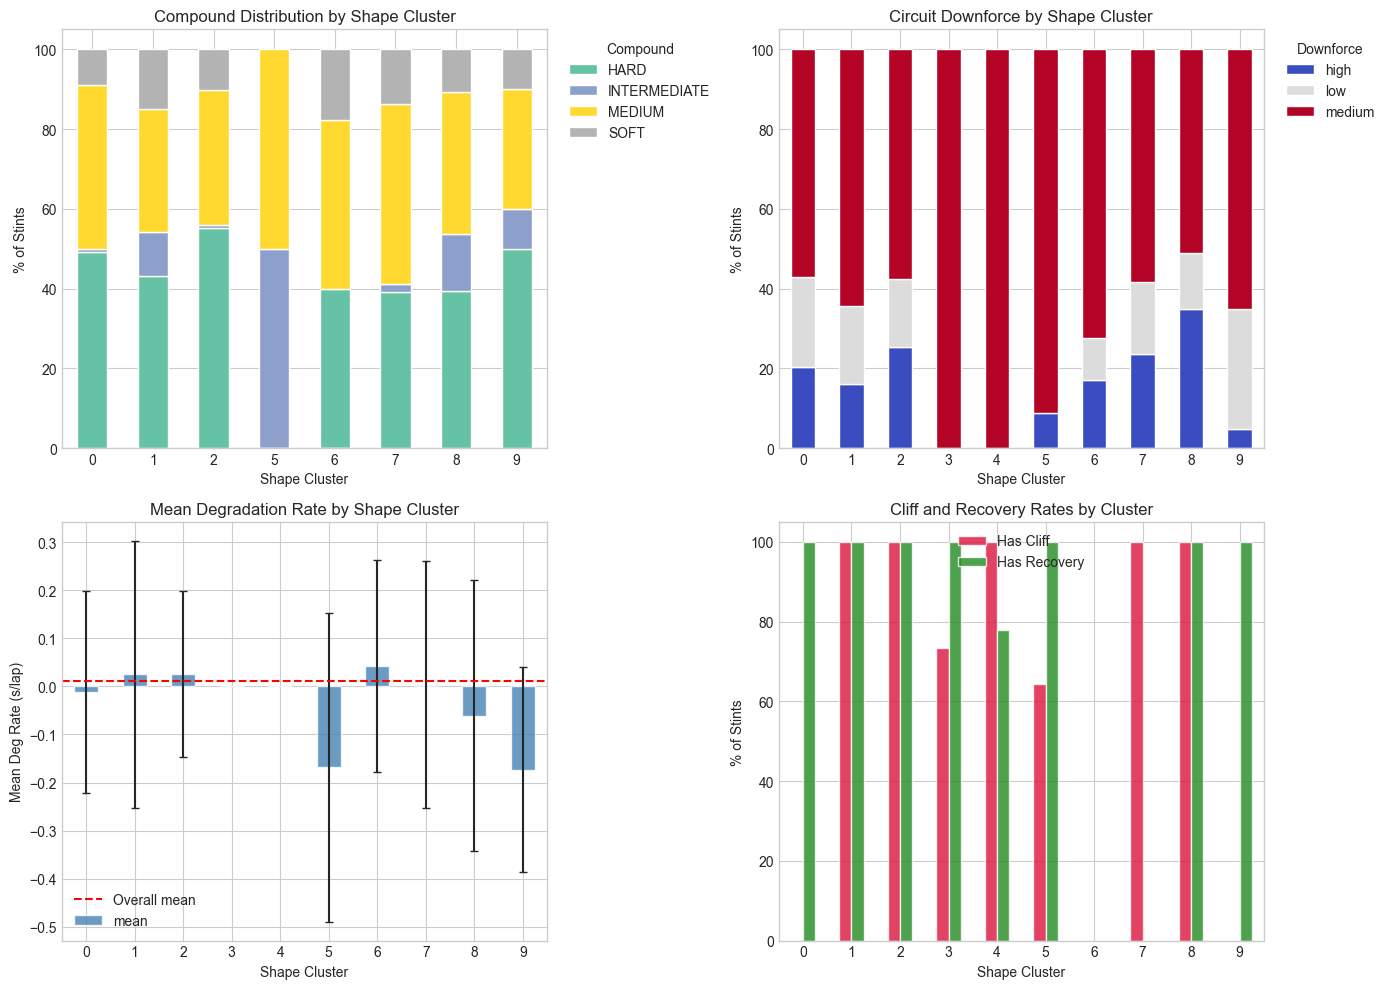


SHAPE CLUSTER VALIDATION SUMMARY

Cluster sizes and deg rates:


,mean,std,count
cluster_shape,,,
0,-0.012,0.210,1072
1,0.025,0.278,1448
2,0.026,0.172,2960
3,NaN,NaN,0
4,NaN,NaN,0
5,-0.168,0.321,16
6,0.042,0.220,720
7,0.004,0.257,408
8,-0.061,0.281,224


In [53]:
# Cell 21: Validate shape clusters against compound and circuit
# Merge shape clusters with stint metadata
df_shape_full = df_shape.merge(
    df[['stint_key', 'compound', 'gp_name', 'driver', 'team', 'year', 'deg_rate_per_lap']],
    on='stint_key', how='left'
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Shape cluster by compound
ax = axes[0, 0]
if 'compound' in df_shape_full.columns:
    compound_cluster = pd.crosstab(df_shape_full['cluster_shape'], df_shape_full['compound'], normalize='index') * 100
    compound_cluster.plot(kind='bar', ax=ax, stacked=True, colormap='Set2')
    ax.set_xlabel('Shape Cluster')
    ax.set_ylabel('% of Stints')
    ax.set_title('Compound Distribution by Shape Cluster')
    ax.legend(title='Compound', bbox_to_anchor=(1.02, 1))
    ax.tick_params(axis='x', rotation=0)
else:
    ax.text(0.5, 0.5, 'No compound data', ha='center', va='center')
    ax.set_title('Compound Distribution')

# 2. Shape cluster by downforce level
ax = axes[0, 1]
if 'gp_name' in df_shape_full.columns:
    df_shape_full['downforce'] = df_shape_full['gp_name'].apply(get_downforce_level)
    downforce_cluster = pd.crosstab(df_shape_full['cluster_shape'], df_shape_full['downforce'], normalize='index') * 100
    downforce_cluster.plot(kind='bar', ax=ax, stacked=True, colormap='coolwarm')
    ax.set_xlabel('Shape Cluster')
    ax.set_ylabel('% of Stints')
    ax.set_title('Circuit Downforce by Shape Cluster')
    ax.legend(title='Downforce', bbox_to_anchor=(1.02, 1))
    ax.tick_params(axis='x', rotation=0)
else:
    ax.text(0.5, 0.5, 'No GP data', ha='center', va='center')

# 3. Mean deg rate by cluster (bar chart)
ax = axes[1, 0]
cluster_deg = df_shape_full.groupby('cluster_shape')['deg_rate_per_lap'].agg(['mean', 'std', 'count'])
cluster_deg['mean'].plot(kind='bar', ax=ax, yerr=cluster_deg['std'], capsize=3, color='steelblue', alpha=0.8)
ax.axhline(df_shape_full['deg_rate_per_lap'].mean(), color='red', linestyle='--', label='Overall mean')
ax.set_xlabel('Shape Cluster')
ax.set_ylabel('Mean Deg Rate (s/lap)')
ax.set_title('Mean Degradation Rate by Shape Cluster')
ax.tick_params(axis='x', rotation=0)
ax.legend()

# 4. Cliff and recovery rates by cluster
ax = axes[1, 1]
cliff_recovery = df_shape.groupby('cluster_shape')[['shape_has_cliff', 'shape_has_recovery']].mean() * 100
cliff_recovery.plot(kind='bar', ax=ax, color=['crimson', 'forestgreen'], alpha=0.8)
ax.set_xlabel('Shape Cluster')
ax.set_ylabel('% of Stints')
ax.set_title('Cliff and Recovery Rates by Cluster')
ax.legend(['Has Cliff', 'Has Recovery'])
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Print summary stats
print("\n" + "=" * 70)
print("SHAPE CLUSTER VALIDATION SUMMARY")
print("=" * 70)
print("\nCluster sizes and deg rates:")
display(cluster_deg.round(3))

## Part 3: Circuit Archetype Clustering

Cluster **circuits** (not stints) by their typical degradation characteristics.
This creates a pre-race lookup table for strategy expectations:
- High-deg vs low-deg circuits
- Circuits prone to cliff events
- Temperature-sensitive circuits
- Circuits where recovery (graining burn-off) is common

In [55]:
# Cell 22: Aggregate stint-level data to circuit-level features
# Group by gp_name to create circuit profiles

circuit_agg_cols = {
    # Degradation metrics
    'deg_rate_per_lap': ['mean', 'std', 'median', lambda x: x.quantile(0.9)],
    # Shape features (from df_shape_full)
    'shape_curvature': ['mean'],
    'shape_linearity_r2': ['mean'],
    'shape_has_cliff': ['mean'],  # % of stints with cliff
    'shape_has_recovery': ['mean'],  # % of stints with recovery
    'shape_slope_early': ['mean'],
    'shape_slope_late': ['mean'],
    'shape_delta_std': ['mean'],
}

# Merge shape features with main df
df_circuit_base = df.merge(
    df_shape[['stint_key', 'shape_curvature', 'shape_linearity_r2', 'shape_has_cliff', 
              'shape_has_recovery', 'shape_slope_early', 'shape_slope_late', 'shape_delta_std']],
    on='stint_key', how='left'
)

# Aggregate by circuit
circuit_profiles = df_circuit_base.groupby('gp_name').agg(circuit_agg_cols)
circuit_profiles.columns = ['_'.join(col).strip() for col in circuit_profiles.columns]
circuit_profiles = circuit_profiles.rename(columns={
    'deg_rate_per_lap_<lambda_0>': 'deg_rate_p90',
    'shape_curvature_mean': 'curvature_mean',
    'shape_linearity_r2_mean': 'linearity_mean',
    'shape_has_cliff_mean': 'cliff_rate',
    'shape_has_recovery_mean': 'recovery_rate',
    'shape_slope_early_mean': 'slope_early_mean',
    'shape_slope_late_mean': 'slope_late_mean',
    'shape_delta_std_mean': 'volatility_mean'
})

# Add weather features per circuit
weather_by_circuit = df_circuit_base.groupby('gp_name').agg({
    'track_temp_mean': 'mean',
    'air_temp_mean': 'mean',
    'humidity_mean': 'mean'
}).rename(columns={
    'track_temp_mean': 'circuit_track_temp',
    'air_temp_mean': 'circuit_air_temp',
    'humidity_mean': 'circuit_humidity'
})

circuit_profiles = circuit_profiles.join(weather_by_circuit)

# Add stint count
circuit_profiles['n_stints'] = df_circuit_base.groupby('gp_name').size()

# Add known downforce level
circuit_profiles['downforce_level'] = circuit_profiles.index.map(
    lambda x: get_downforce_level(x)
)
circuit_profiles['downforce_numeric'] = circuit_profiles['downforce_level'].map({'low': 0, 'medium': 1, 'high': 2})

print(f"Circuit profiles: {len(circuit_profiles)} circuits")
print(f"Features: {list(circuit_profiles.columns)}")
display(circuit_profiles.head(10))

Circuit profiles: 25 circuits
Features: ['deg_rate_per_lap_mean', 'deg_rate_per_lap_std', 'deg_rate_per_lap_median', 'deg_rate_p90', 'curvature_mean', 'linearity_mean', 'cliff_rate', 'recovery_rate', 'slope_early_mean', 'slope_late_mean', 'volatility_mean', 'circuit_track_temp', 'circuit_air_temp', 'circuit_humidity', 'n_stints', 'downforce_level', 'downforce_numeric']


,deg_rate_per_lap_mean,deg_rate_per_lap_std,deg_rate_per_lap_median,deg_rate_p90,curvature_mean,linearity_mean,cliff_rate,recovery_rate,slope_early_mean,slope_late_mean,volatility_mean,circuit_track_temp,circuit_air_temp,circuit_humidity,n_stints,downforce_level,downforce_numeric
gp_name,,,,,,,,,,,,,,,,,
Abu Dhabi Grand Prix,0.042442,0.178679,0.046305,0.218184,0.017828,0.693046,0.652174,0.869565,0.066710,0.084538,0.355003,33.253447,27.530414,55.326062,368,high,2
Australian Grand Prix,-0.059658,0.182785,-0.065800,0.206854,0.094633,0.535835,0.566667,0.900000,0.019614,0.114247,0.366854,36.176055,21.704496,46.476922,240,medium,1
Austrian Grand Prix,0.046713,0.195180,0.089744,0.281281,0.034782,0.747672,0.666667,0.757576,0.060977,0.095760,0.395259,37.377079,24.614823,40.978527,528,medium,1
Azerbaijan Grand Prix,-0.018562,0.229594,0.003986,0.305525,0.076390,0.475116,0.833333,0.875000,0.061025,0.137414,0.434522,45.212167,25.633287,51.984263,192,low,0
Bahrain Grand Prix,0.097114,0.200451,0.126451,0.312342,-0.020157,0.807982,0.578125,0.593750,0.159579,0.139422,0.311665,27.309327,22.560188,34.970769,512,medium,1
Belgian Grand Prix,0.141950,0.253521,0.207466,0.439637,-0.055403,0.631229,0.735294,0.823529,0.209072,0.153669,0.437997,35.365016,20.386020,50.111257,272,low,0
British Grand Prix,-0.003788,0.220021,-0.037183,0.362559,0.146355,0.509416,0.642857,0.821429,-0.039727,0.106628,0.360645,29.660932,18.835402,60.659519,224,medium,1
Canadian Grand Prix,-0.059716,0.192625,-0.035822,0.185700,0.008883,0.616749,0.704545,0.954545,0.043119,0.052002,0.441479,33.756647,19.276289,51.896117,352,medium,1
Chinese Grand Prix,0.023672,0.205138,0.116526,0.194278,0.052652,0.789481,0.866667,0.733333,0.082728,0.135380,0.344960,29.792727,18.639394,66.060606,120,medium,1


Using 12 circuit features
Circuits with sufficient data: 25

Optimal K (by BIC): 4
Cluster sizes: [5, 9, 7, 4]


,k,bic,aic,silhouette,sizes
0,2,334.002862,113.386338,0.066855,"[19, 6]"
1,3,-108.959135,-440.493360,0.139245,"[7, 9, 9]"
2,4,-319.592459,-762.044383,0.137678,"[5, 9, 7, 4]"
3,5,84.103223,-469.266402,0.144284,"[2, 9, 9, 1, 4]"
4,6,-303.086584,-967.373908,0.156659,"[6, 6, 1, 5, 2, 5]"
5,7,-132.590816,-907.795840,0.077616,"[2, 3, 3, 1, 7, 3, 6]"


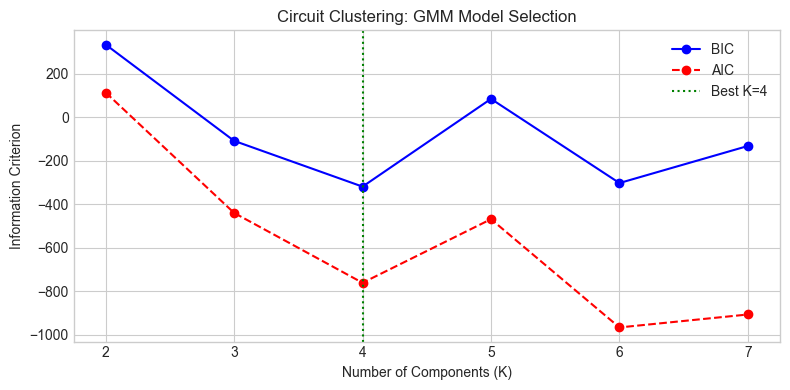

In [56]:
# Cell 23: Circuit clustering with GMM
circuit_feature_cols = [
    'deg_rate_per_lap_mean', 'deg_rate_per_lap_std', 'deg_rate_p90',
    'curvature_mean', 'linearity_mean', 'cliff_rate', 'recovery_rate',
    'slope_early_mean', 'slope_late_mean', 'volatility_mean',
    'circuit_track_temp', 'downforce_numeric'
]

# Keep only available columns
circuit_feature_cols = [c for c in circuit_feature_cols if c in circuit_profiles.columns]
print(f"Using {len(circuit_feature_cols)} circuit features")

# Prepare feature matrix
df_circuit = circuit_profiles[circuit_feature_cols].copy()
df_circuit = df_circuit.dropna(thresh=int(len(circuit_feature_cols) * 0.6))
df_circuit = df_circuit.apply(lambda c: c.fillna(c.median()))

print(f"Circuits with sufficient data: {len(df_circuit)}")

# Scale features
X_circuit = df_circuit.values
scaler_circuit = StandardScaler()
X_circuit_scaled = scaler_circuit.fit_transform(X_circuit)

# GMM clustering - use smaller K range since we have fewer circuits
best_k_circuit, gmm_circuit, results_gmm_circuit = find_best_gmm(X_circuit_scaled, k_range=range(2, min(8, len(df_circuit)-1)))
labels_circuit = gmm_circuit.predict(X_circuit_scaled)
df_circuit['cluster_circuit'] = labels_circuit

print(f"\nOptimal K (by BIC): {best_k_circuit}")
print(f"Cluster sizes: {np.bincount(labels_circuit).tolist()}")

# Show results
display(results_gmm_circuit)

# Plot BIC curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_gmm_circuit['k'], results_gmm_circuit['bic'], 'b-o', label='BIC')
ax.plot(results_gmm_circuit['k'], results_gmm_circuit['aic'], 'r--o', label='AIC')
ax.axvline(best_k_circuit, color='green', linestyle=':', label=f'Best K={best_k_circuit}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Circuit Clustering: GMM Model Selection')
ax.legend()
plt.tight_layout()
plt.show()

CIRCUIT CLUSTER PROFILES (z-scored)


cluster_circuit,0,1,2,3
deg_rate_per_lap_mean,0.41,-0.21,-1.28,1.07
deg_rate_per_lap_std,-1.05,-0.62,0.59,1.08
deg_rate_p90,-0.56,-0.20,-0.70,1.47
curvature_mean,-0.45,-0.03,1.40,-0.92
linearity_mean,1.10,-0.46,-1.15,0.51
cliff_rate,-0.49,0.16,-0.99,1.32
recovery_rate,-1.27,1.09,0.39,-0.21
slope_early_mean,0.39,0.04,-1.39,0.96
slope_late_mean,0.32,0.05,-1.37,1.01
volatility_mean,-0.85,-0.70,1.32,0.23


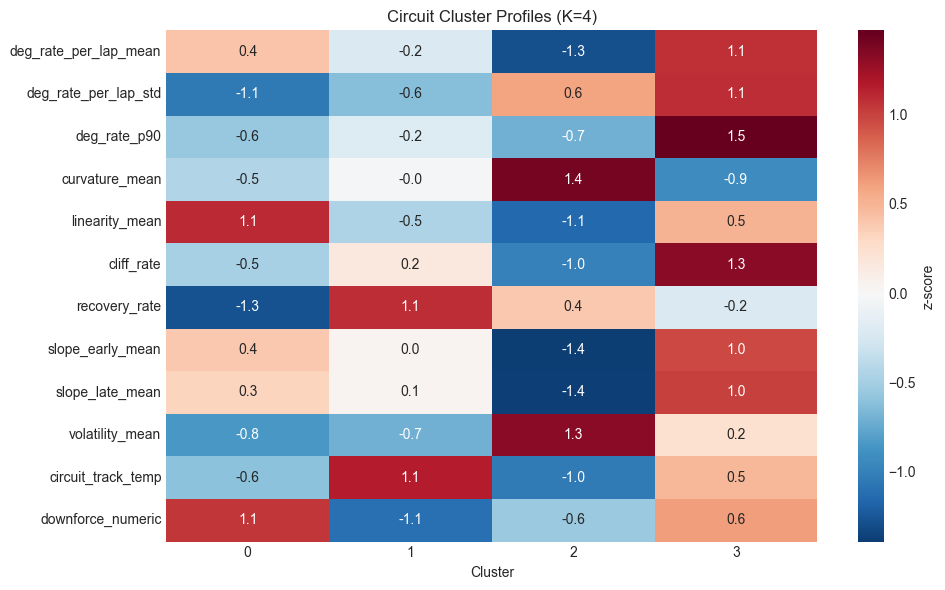


CIRCUIT ARCHETYPE INTERPRETATION

Cluster 0: Cool track | Predictable
  Circuits: Abu Dhabi Grand Prix, Austrian Grand Prix, Bahrain Grand Prix, Chinese Grand Prix, Singapore Grand Prix

Cluster 1: Recovery-friendly | Hot track | Predictable
  Circuits: Australian Grand Prix, Azerbaijan Grand Prix, Canadian Grand Prix, French Grand Prix, Italian Grand Prix, Mexico City Grand Prix, Miami Grand Prix, São Paulo Grand Prix, United States Grand Prix

Cluster 2: Low-deg | Cool track | High variability | Progressive deg
  Circuits: British Grand Prix, Dutch Grand Prix, Emilia Romagna Grand Prix, Las Vegas Grand Prix, Monaco Grand Prix, Qatar Grand Prix, Saudi Arabian Grand Prix

Cluster 3: High-deg | Cliff-prone | Front-loaded deg
  Circuits: Belgian Grand Prix, Hungarian Grand Prix, Japanese Grand Prix, Spanish Grand Prix


In [57]:
# Cell 24: Circuit cluster profiling and visualization
# Create circuit lookup table with cluster assignment
circuit_lookup = circuit_profiles.copy()
circuit_lookup['cluster'] = df_circuit['cluster_circuit'].reindex(circuit_lookup.index)

# Profile each cluster
print("=" * 70)
print("CIRCUIT CLUSTER PROFILES (z-scored)")
print("=" * 70)

profile_circuit = profile_clusters(df_circuit, circuit_feature_cols, 'cluster_circuit')
display(profile_circuit)

# Heatmap
fig, ax = plt.subplots(figsize=(10, max(6, len(circuit_feature_cols) * 0.4)))
sns.heatmap(profile_circuit, cmap='RdBu_r', center=0, annot=True, fmt='.1f', ax=ax, cbar_kws={'label': 'z-score'})
ax.set_title(f'Circuit Cluster Profiles (K={best_k_circuit})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Interpret clusters
print("\n" + "=" * 70)
print("CIRCUIT ARCHETYPE INTERPRETATION")
print("=" * 70)

def interpret_circuit_cluster(profile_row: pd.Series) -> str:
    """Interpret a circuit cluster based on its feature profile."""
    interpretations = []
    
    if profile_row.get('deg_rate_per_lap_mean', 0) > 0.5:
        interpretations.append("High-deg")
    elif profile_row.get('deg_rate_per_lap_mean', 0) < -0.5:
        interpretations.append("Low-deg")
    
    if profile_row.get('cliff_rate', 0) > 0.5:
        interpretations.append("Cliff-prone")
    
    if profile_row.get('recovery_rate', 0) > 0.5:
        interpretations.append("Recovery-friendly")
    
    if profile_row.get('circuit_track_temp', 0) > 0.5:
        interpretations.append("Hot track")
    elif profile_row.get('circuit_track_temp', 0) < -0.5:
        interpretations.append("Cool track")
    
    if profile_row.get('volatility_mean', 0) > 0.5:
        interpretations.append("High variability")
    elif profile_row.get('volatility_mean', 0) < -0.5:
        interpretations.append("Predictable")
    
    if profile_row.get('curvature_mean', 0) > 0.5:
        interpretations.append("Progressive deg")
    elif profile_row.get('curvature_mean', 0) < -0.5:
        interpretations.append("Front-loaded deg")
    
    return " | ".join(interpretations) if interpretations else "Baseline"

for cluster_id in sorted(df_circuit['cluster_circuit'].unique()):
    profile_row = profile_circuit[cluster_id]
    interpretation = interpret_circuit_cluster(profile_row)
    circuits_in_cluster = df_circuit[df_circuit['cluster_circuit'] == cluster_id].index.tolist()
    print(f"\nCluster {cluster_id}: {interpretation}")
    print(f"  Circuits: {', '.join(circuits_in_cluster)}")

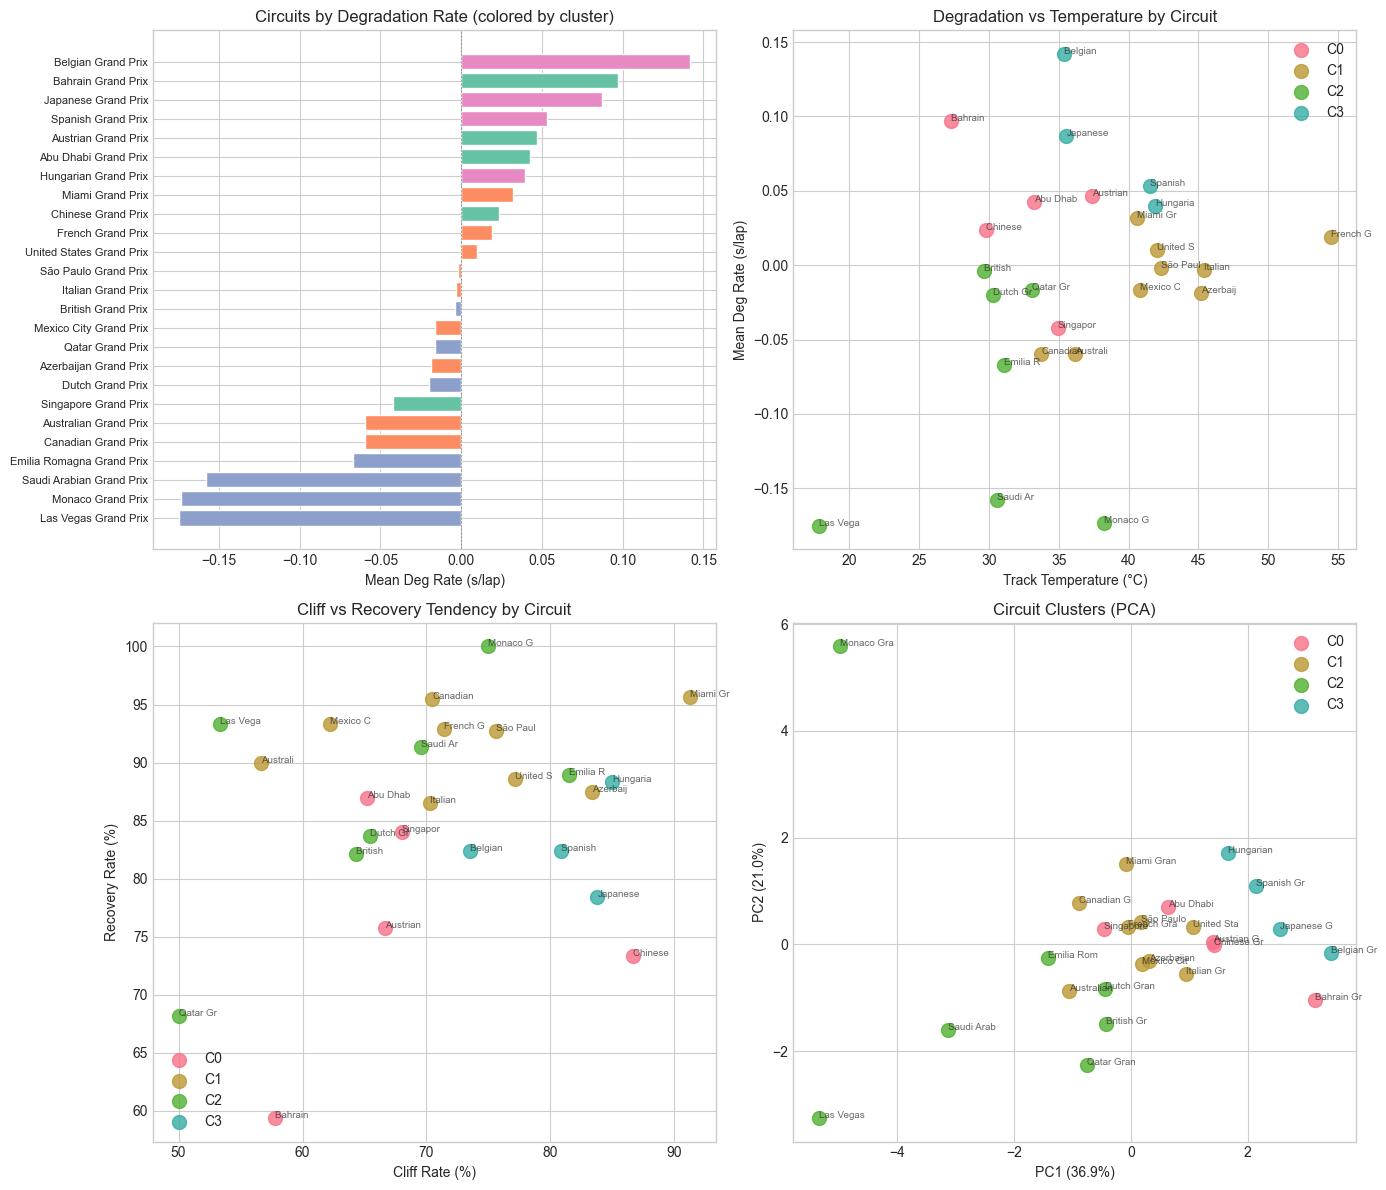

In [58]:
# Cell 25: Circuit archetype visualization - radar chart and bar comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Bar chart: Mean deg rate by circuit (colored by cluster)
ax = axes[0, 0]
sorted_circuits = circuit_lookup.sort_values('deg_rate_per_lap_mean')
colors_circuit = plt.cm.Set2(sorted_circuits['cluster'].fillna(-1).astype(int) % 8)
ax.barh(range(len(sorted_circuits)), sorted_circuits['deg_rate_per_lap_mean'], color=colors_circuit)
ax.set_yticks(range(len(sorted_circuits)))
ax.set_yticklabels(sorted_circuits.index, fontsize=8)
ax.set_xlabel('Mean Deg Rate (s/lap)')
ax.set_title('Circuits by Degradation Rate (colored by cluster)')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)

# 2. Scatter: Deg rate vs Track temp (colored by cluster)
ax = axes[0, 1]
for cl in sorted(df_circuit['cluster_circuit'].unique()):
    mask = df_circuit['cluster_circuit'] == cl
    ax.scatter(df_circuit.loc[mask, 'circuit_track_temp'], 
               df_circuit.loc[mask, 'deg_rate_per_lap_mean'],
               label=f'C{cl}', s=100, alpha=0.8)
    # Add circuit labels
    for circuit in df_circuit[mask].index:
        ax.annotate(circuit[:8], 
                   (df_circuit.loc[circuit, 'circuit_track_temp'], 
                    df_circuit.loc[circuit, 'deg_rate_per_lap_mean']),
                   fontsize=7, alpha=0.7)
ax.set_xlabel('Track Temperature (°C)')
ax.set_ylabel('Mean Deg Rate (s/lap)')
ax.set_title('Degradation vs Temperature by Circuit')
ax.legend()

# 3. Cliff rate vs Recovery rate by circuit
ax = axes[1, 0]
for cl in sorted(df_circuit['cluster_circuit'].unique()):
    mask = df_circuit['cluster_circuit'] == cl
    ax.scatter(df_circuit.loc[mask, 'cliff_rate'] * 100, 
               df_circuit.loc[mask, 'recovery_rate'] * 100,
               label=f'C{cl}', s=100, alpha=0.8)
    for circuit in df_circuit[mask].index:
        ax.annotate(circuit[:8], 
                   (df_circuit.loc[circuit, 'cliff_rate'] * 100, 
                    df_circuit.loc[circuit, 'recovery_rate'] * 100),
                   fontsize=7, alpha=0.7)
ax.set_xlabel('Cliff Rate (%)')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title('Cliff vs Recovery Tendency by Circuit')
ax.legend()

# 4. PCA visualization of circuits
pca_circuit = PCA(n_components=2, random_state=42)
coords_circuit = pca_circuit.fit_transform(X_circuit_scaled)
ax = axes[1, 1]
for cl in sorted(df_circuit['cluster_circuit'].unique()):
    mask = df_circuit['cluster_circuit'] == cl
    ax.scatter(coords_circuit[mask.values, 0], coords_circuit[mask.values, 1],
               label=f'C{cl}', s=100, alpha=0.8)
for i, circuit in enumerate(df_circuit.index):
    ax.annotate(circuit[:10], (coords_circuit[i, 0], coords_circuit[i, 1]), fontsize=7, alpha=0.7)
ax.set_xlabel(f'PC1 ({pca_circuit.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_circuit.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Circuit Clusters (PCA)')
ax.legend()

plt.tight_layout()
plt.show()

In [59]:
# Cell 26: Final circuit lookup table for strategy
print("=" * 70)
print("CIRCUIT STRATEGY LOOKUP TABLE")
print("=" * 70)

# Create a clean lookup table
lookup_cols = ['cluster', 'deg_rate_per_lap_mean', 'cliff_rate', 'recovery_rate', 
               'circuit_track_temp', 'downforce_level', 'n_stints']
circuit_strategy_table = circuit_lookup[lookup_cols].copy()
circuit_strategy_table = circuit_strategy_table.rename(columns={
    'deg_rate_per_lap_mean': 'avg_deg_rate',
    'cliff_rate': 'cliff_pct',
    'recovery_rate': 'recovery_pct',
    'circuit_track_temp': 'track_temp'
})
circuit_strategy_table['cliff_pct'] = (circuit_strategy_table['cliff_pct'] * 100).round(1)
circuit_strategy_table['recovery_pct'] = (circuit_strategy_table['recovery_pct'] * 100).round(1)
circuit_strategy_table['avg_deg_rate'] = circuit_strategy_table['avg_deg_rate'].round(3)
circuit_strategy_table['track_temp'] = circuit_strategy_table['track_temp'].round(1)

# Add strategy recommendation
def strategy_recommendation(row):
    recs = []
    if row['avg_deg_rate'] > 0.05:
        recs.append("Early stops")
    elif row['avg_deg_rate'] < -0.02:
        recs.append("Extend stints")
    if row['cliff_pct'] > 70:
        recs.append("Monitor closely")
    if row['recovery_pct'] > 80:
        recs.append("Wait for graining")
    return " | ".join(recs) if recs else "Standard strategy"

circuit_strategy_table['recommendation'] = circuit_strategy_table.apply(strategy_recommendation, axis=1)

# Sort by deg rate
circuit_strategy_table = circuit_strategy_table.sort_values('avg_deg_rate', ascending=False)

display(circuit_strategy_table)

print("\n" + "=" * 70)
print("CLUSTER SUMMARY")
print("=" * 70)
for cl in sorted(df_circuit['cluster_circuit'].dropna().unique()):
    circuits = df_circuit[df_circuit['cluster_circuit'] == cl].index.tolist()
    avg_deg = df_circuit.loc[df_circuit['cluster_circuit'] == cl, 'deg_rate_per_lap_mean'].mean()
    print(f"Cluster {int(cl)}: {len(circuits)} circuits, avg deg={avg_deg:.3f} s/lap")
    print(f"  → {', '.join(circuits)}")

CIRCUIT STRATEGY LOOKUP TABLE


,cluster,avg_deg_rate,cliff_pct,recovery_pct,track_temp,downforce_level,n_stints,recommendation
gp_name,,,,,,,,
Belgian Grand Prix,3,0.142,73.5,82.4,35.4,low,272,Early stops | Monitor closely | Wait for graining
Bahrain Grand Prix,0,0.097,57.8,59.4,27.3,medium,512,Early stops
Japanese Grand Prix,3,0.087,83.8,78.4,35.6,medium,296,Early stops | Monitor closely
Spanish Grand Prix,3,0.053,80.9,82.4,41.5,high,544,Early stops | Monitor closely | Wait for graining
Austrian Grand Prix,0,0.047,66.7,75.8,37.4,medium,528,Standard strategy
Abu Dhabi Grand Prix,0,0.042,65.2,87.0,33.3,high,368,Wait for graining
Hungarian Grand Prix,3,0.040,85.0,88.3,41.9,high,480,Monitor closely | Wait for graining
Miami Grand Prix,1,0.032,91.3,95.7,40.6,medium,184,Monitor closely | Wait for graining
Chinese Grand Prix,0,0.024,86.7,73.3,29.8,medium,120,Monitor closely



CLUSTER SUMMARY
Cluster 0: 5 circuits, avg deg=0.034 s/lap
  → Abu Dhabi Grand Prix, Austrian Grand Prix, Bahrain Grand Prix, Chinese Grand Prix, Singapore Grand Prix
Cluster 1: 9 circuits, avg deg=-0.011 s/lap
  → Australian Grand Prix, Azerbaijan Grand Prix, Canadian Grand Prix, French Grand Prix, Italian Grand Prix, Mexico City Grand Prix, Miami Grand Prix, São Paulo Grand Prix, United States Grand Prix
Cluster 2: 7 circuits, avg deg=-0.088 s/lap
  → British Grand Prix, Dutch Grand Prix, Emilia Romagna Grand Prix, Las Vegas Grand Prix, Monaco Grand Prix, Qatar Grand Prix, Saudi Arabian Grand Prix
Cluster 3: 4 circuits, avg deg=0.080 s/lap
  → Belgian Grand Prix, Hungarian Grand Prix, Japanese Grand Prix, Spanish Grand Prix


# Part 4: Driver Behavior Clustering (Telemetry-Based)

**Goal:** Cluster drivers by their driving style using telemetry data and correlate with tyre degradation outcomes.

**Features extracted from telemetry:**
- Throttle patterns: smoothness, aggression, on-throttle %
- Brake patterns: intensity, modulation, coasting behavior
- Speed patterns: consistency, variance

**Combined with degradation outcomes:**
- Average degradation rate achieved
- Consistency across stints
- Cliff/recovery tendencies

In [62]:
# Cell 27: Extract telemetry-based driving style features per stint
print("=" * 70)
print("DRIVER BEHAVIOR CLUSTERING - TELEMETRY FEATURE EXTRACTION")
print("=" * 70)

# We need to go back to raw telemetry and compute per-stint driving style metrics
# Telemetry is partitioned by year, so use recursive glob
telemetry_path = str(BRONZE_PATH.resolve() / 'telemetry_raw' / '**' / '*.parquet').replace('\\', '/')
telemetry_sample_sql = f"""
SELECT * FROM read_parquet('{telemetry_path}') LIMIT 5
"""
telem_sample = conn.execute(telemetry_sample_sql).df()
print("Telemetry columns:", list(telem_sample.columns))

# Identify column names dynamically
telem_cols_lower = {c.lower(): c for c in telem_sample.columns}
throttle_col = next((telem_cols_lower[k] for k in ['throttle', 'throttle_pct'] if k in telem_cols_lower), None)
brake_col = next((telem_cols_lower[k] for k in ['brake', 'brake_pct', 'brakepressure'] if k in telem_cols_lower), None)
speed_col = next((telem_cols_lower[k] for k in ['speed', 'speedkph', 'speed_kph'] if k in telem_cols_lower), None)
rpm_col = next((telem_cols_lower[k] for k in ['rpm', 'enginerpm'] if k in telem_cols_lower), None)
gear_col = next((telem_cols_lower[k] for k in ['ngear', 'gear'] if k in telem_cols_lower), None)
drs_col = next((telem_cols_lower[k] for k in ['drs'] if k in telem_cols_lower), None)

print(f"\nIdentified columns:")
print(f"  Throttle: {throttle_col}")
print(f"  Brake: {brake_col}")
print(f"  Speed: {speed_col}")
print(f"  RPM: {rpm_col}")
print(f"  Gear: {gear_col}")
print(f"  DRS: {drs_col}")

DRIVER BEHAVIOR CLUSTERING - TELEMETRY FEATURE EXTRACTION
Telemetry columns: ['session_id', 'year', 'gp_name', 'session_type', 'driver_number', 'time_s', 'session_time_s', 'speed_kph', 'rpm', 'gear', 'throttle', 'brake', 'drs', 'gp', 'session']

Identified columns:
  Throttle: throttle
  Brake: brake
  Speed: speed_kph
  RPM: rpm
  Gear: gear
  DRS: drs


In [65]:
# Cell 28: Compute telemetry driving style features per driver
# Note: brake is BOOLEAN (on/off), not pressure value

print("Loading full telemetry dataset and aggregating by driver...")
telemetry_glob = str(BRONZE_PATH.resolve() / 'telemetry_raw' / '**' / '*.parquet').replace('\\', '/')

# Aggregate telemetry at driver level
# brake is boolean, so we calculate percentage of time on brake
driver_telem_sql = f"""
SELECT 
    driver_number,
    -- Throttle patterns
    AVG(throttle) as throttle_mean,
    STDDEV(throttle) as throttle_std,
    SUM(CASE WHEN throttle > 95 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as on_throttle_pct,
    SUM(CASE WHEN throttle < 5 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as off_throttle_pct,
    -- Brake patterns (brake is boolean)
    SUM(CASE WHEN brake THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as on_brake_pct,
    -- Coasting (low throttle AND not braking)
    SUM(CASE WHEN throttle < 10 AND NOT brake THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as coasting_pct,
    -- Speed patterns
    AVG(speed_kph) as speed_mean,
    STDDEV(speed_kph) as speed_std,
    STDDEV(speed_kph) / NULLIF(AVG(speed_kph), 0) as speed_cv,
    -- RPM patterns (indicative of engine management)
    AVG(rpm) as rpm_mean,
    STDDEV(rpm) as rpm_std,
    -- DRS usage
    SUM(CASE WHEN drs > 10 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as drs_usage_pct,
    -- Stats
    COUNT(*) as n_samples,
    COUNT(DISTINCT year || '-' || gp_name || '-' || session_type) as n_sessions
FROM read_parquet('{telemetry_glob}')
WHERE throttle IS NOT NULL AND speed_kph IS NOT NULL
GROUP BY driver_number
HAVING COUNT(*) > 10000  -- Need sufficient data per driver
"""

print("Executing query...")
driver_telemetry = conn.execute(driver_telem_sql).df()
print(f"Driver telemetry profiles: {len(driver_telemetry)} car numbers")

# Show sample
display(driver_telemetry.head(10))

# Note: driver_number is car number (string), need to map to driver codes
print("\nCar numbers in telemetry:", sorted(driver_telemetry['driver_number'].unique()))

Loading full telemetry dataset and aggregating by driver...
Executing query...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Driver telemetry profiles: 48 car numbers


,driver_number,throttle_mean,throttle_std,on_throttle_pct,off_throttle_pct,on_brake_pct,coasting_pct,speed_mean,speed_std,speed_cv,rpm_mean,rpm_std,drs_usage_pct,n_samples,n_sessions
0,16,58.070802,46.400944,47.517467,32.214213,40.237904,23.092883,90.566171,104.177570,1.150292,5304.326643,4673.366492,2.253280,7403164,334
1,44,56.349854,46.725575,45.495397,33.217070,38.700867,25.410170,90.948680,103.976659,1.143245,4964.033788,4665.028700,2.264668,7403028,334
2,55,56.082352,46.242384,45.052451,33.568351,38.408747,24.309166,90.622747,104.123449,1.148977,5273.338594,4661.478228,2.116226,7332913,331
3,77,51.071013,47.811056,42.488662,41.651675,35.554985,31.942754,85.135076,103.166970,1.211803,4631.939664,4808.884047,2.477059,7365226,332
4,21,50.537624,47.808971,41.111602,42.687323,32.526312,34.393944,85.125157,104.258049,1.224762,4689.126955,4952.685492,2.745965,1076015,48
5,43,56.272724,47.570657,47.334138,35.240780,42.704737,26.385848,80.043897,103.727746,1.295886,4423.689875,4669.639919,2.297925,965654,45
6,46,50.444527,46.529861,40.986317,35.729761,34.002281,29.104903,89.163056,100.777079,1.130256,4828.851596,4688.664580,2.702395,17540,1
7,24,52.595205,47.863426,44.114940,39.859842,37.555092,30.181088,82.604741,101.983998,1.234602,4479.320265,4742.208922,2.451481,7366527,332
8,31,54.894872,47.378239,45.030484,36.647864,38.321074,28.222066,84.306578,103.140180,1.223394,4737.523646,4706.769872,2.637918,7302311,329
9,27,57.317477,47.520156,48.868434,34.753785,40.421465,26.310201,86.687568,104.850954,1.209527,4945.571517,4666.801884,2.115748,5080615,231



Car numbers in telemetry: ['1', '10', '11', '12', '14', '16', '18', '19', '2', '20', '21', '22', '23', '24', '27', '28', '29', '3', '30', '31', '34', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '5', '50', '51', '55', '6', '61', '63', '77', '81', '82', '88', '97', '98', '99']


In [68]:
# Cell 29: Create driver number to code mapping and merge with degradation outcomes

# F1 driver number to code mapping (2022-2024 grid)
driver_number_map = {
    '1': 'VER', '11': 'PER',  # Red Bull
    '44': 'HAM', '63': 'RUS',  # Mercedes
    '16': 'LEC', '55': 'SAI',  # Ferrari
    '4': 'NOR', '81': 'PIA', '3': 'RIC',  # McLaren (RIC was there earlier)
    '14': 'ALO', '18': 'STR',  # Aston Martin
    '10': 'GAS', '31': 'OCO',  # Alpine
    '22': 'TSU', '21': 'DEV',  # AlphaTauri/RB
    '23': 'ALB', '6': 'LAT', '2': 'SAR', '43': 'COL',  # Williams
    '77': 'BOT', '24': 'ZHO',  # Alfa Romeo/Sauber
    '20': 'MAG', '27': 'HUL',  # Haas
    '47': 'SCH', '5': 'VET',  # Others
    '30': 'DEV', '33': 'VER',  # Alternative numbers
    '38': 'BEA', '39': 'SHW', '50': 'DOO',  # Reserve drivers
    '82': 'DOO', '61': 'DOO', '34': 'SAR',
    '99': 'GIO', '88': 'KUB', '45': 'DEV',
    '19': 'STR', '12': 'TSU', '28': 'HUL',
    '46': 'ANT', '36': 'BEA', '37': 'LAW', '40': 'LAW', '41': 'LAW',
    '42': 'POU', '51': 'FIT', '97': 'DOO', '98': 'DOO', '29': 'LAW',
}

# Map car numbers to driver codes
driver_telemetry['driver'] = driver_telemetry['driver_number'].map(driver_number_map)

# Handle unmapped drivers
unmapped = driver_telemetry[driver_telemetry['driver'].isna()]['driver_number'].unique()
if len(unmapped) > 0:
    print(f"Unmapped car numbers: {unmapped}")

# Drop rows without mapping
driver_telemetry = driver_telemetry.dropna(subset=['driver'])
print(f"Drivers with telemetry: {len(driver_telemetry)}")

# Check what columns we have in stints
print(f"\nStints columns: {list(stints.columns)}")

# Use analysis_df which has r_squared
print(f"Analysis_df columns: {list(analysis_df.columns)[:15]}...")

# Aggregate degradation outcomes by driver
driver_deg = analysis_df.groupby('driver').agg({
    'deg_rate_per_lap': ['mean', 'std', 'min', 'max', 'count'],
    'num_laps': 'sum'
}).reset_index()
driver_deg.columns = ['driver', 'avg_deg_rate', 'deg_consistency', 'best_deg', 'worst_deg', 'n_stints', 'total_laps']

print(f"Drivers with degradation data: {len(driver_deg)}")

# Merge telemetry with degradation
driver_profiles = driver_telemetry.merge(driver_deg, on='driver', how='inner')
print(f"Merged driver profiles: {len(driver_profiles)}")

# Filter for drivers with enough data
min_stints = 5
driver_profiles = driver_profiles[driver_profiles['n_stints'] >= min_stints]
print(f"Drivers with >= {min_stints} stints: {len(driver_profiles)}")

display(driver_profiles)

Drivers with telemetry: 48

Stints columns: ['session_id', 'year', 'gp_name', 'session_type', 'driver', 'driver_number', 'team', 'compound', 'stint', 'segment_id', 'first_lap', 'last_lap', 'num_laps', 'avg_lap_time_s', 'std_lap_time_s', 'best_lap_time_s', 'worst_lap_time_s', 'tyre_life_start', 'tyre_life_end', 'avg_position', 'best_position', 'worst_position', 'avg_gap_ahead_s', 'min_gap_ahead_s', 'stint_length', 'lap_time_range_s', 'tyre_age_span', 'deg_model', 'deg_r_squared', 'deg_rate_per_lap', 'deg_intercept', 'deg_rate_raw', 'deg_r_squared_raw', 'stint_key', 'deg_ms']
Analysis_df columns: ['session_id', 'year', 'gp_name', 'session_type', 'driver', 'driver_number', 'team', 'compound', 'stint', 'segment_id', 'first_lap', 'last_lap', 'num_laps', 'avg_lap_time_s', 'std_lap_time_s']...
Drivers with degradation data: 28
Merged driver profiles: 41
Drivers with >= 5 stints: 33


,driver_number,throttle_mean,throttle_std,on_throttle_pct,off_throttle_pct,on_brake_pct,coasting_pct,speed_mean,speed_std,speed_cv,rpm_mean,rpm_std,drs_usage_pct,n_samples,n_sessions,driver,avg_deg_rate,deg_consistency,best_deg,worst_deg,n_stints,total_laps
0,16,58.070802,46.400944,47.517467,32.214213,40.237904,23.092883,90.566171,104.177570,1.150292,5304.326643,4673.366492,2.253280,7403164,334,LEC,-0.022398,0.252093,-0.499207,0.455131,58,889
1,44,56.349854,46.725575,45.495397,33.217070,38.700867,25.410170,90.948680,103.976659,1.143245,4964.033788,4665.028700,2.264668,7403028,334,HAM,-0.012073,0.197373,-0.423293,0.425539,45,751
2,55,56.082352,46.242384,45.052451,33.568351,38.408747,24.309166,90.622747,104.123449,1.148977,5273.338594,4661.478228,2.116226,7332913,331,SAI,0.006588,0.220067,-0.425260,0.467607,59,901
3,77,51.071013,47.811056,42.488662,41.651675,35.554985,31.942754,85.135076,103.166970,1.211803,4631.939664,4808.884047,2.477059,7365226,332,BOT,0.015671,0.227668,-0.391226,0.476700,31,484
4,21,50.537624,47.808971,41.111602,42.687323,32.526312,34.393944,85.125157,104.258049,1.224762,4689.126955,4952.685492,2.745965,1076015,48,DEV,0.161595,0.129720,-0.006230,0.324197,5,86
6,24,52.595205,47.863426,44.114940,39.859842,37.555092,30.181088,82.604741,101.983998,1.234602,4479.320265,4742.208922,2.451481,7366527,332,ZHO,-0.003818,0.263728,-0.487543,0.376977,28,405
7,31,54.894872,47.378239,45.030484,36.647864,38.321074,28.222066,84.306578,103.140180,1.223394,4737.523646,4706.769872,2.637918,7302311,329,OCO,0.050230,0.222131,-0.458590,0.455548,40,623
8,27,57.317477,47.520156,48.868434,34.753785,40.421465,26.310201,86.687568,104.850954,1.209527,4945.571517,4666.801884,2.115748,5080615,231,HUL,-0.011065,0.258953,-0.487546,0.425190,27,416
9,2,56.561908,47.691140,48.264604,35.354328,42.390595,26.509294,80.741327,102.936941,1.274898,4517.888975,4703.364811,2.039248,3847594,175,SAR,-0.011642,0.245540,-0.422036,0.363352,22,329
10,37,51.256592,47.297283,42.024528,37.105727,37.400143,31.022391,77.606871,95.986496,1.236830,4512.551945,4618.460154,2.100289,53326,3,LAW,-0.131511,0.220308,-0.296779,0.299586,6,91


Using 11 features for driver clustering:
  - throttle_mean
  - throttle_std
  - on_throttle_pct
  - off_throttle_pct
  - on_brake_pct
  - coasting_pct
  - speed_cv
  - rpm_mean
  - rpm_std
  - avg_deg_rate
  - deg_consistency

Drivers for clustering: 33

Finding optimal number of driver clusters...

Optimal K (by BIC): 7
Cluster sizes: [4, 8, 1, 7, 6, 5, 2]


,k,bic,aic,silhouette,sizes
0,2,533.208779,301.250107,0.276673,"[20, 13]"
1,3,554.364940,205.678678,0.232464,"[2, 13, 18]"
2,4,295.109706,-170.304146,0.222317,"[10, 17, 5, 1]"
3,5,206.504852,-375.636590,0.214980,"[11, 1, 8, 11, 2]"
4,6,154.503704,-544.365328,0.224022,"[10, 11, 1, 6, 2, 3]"
5,7,-248.467937,-1064.064558,0.222656,"[4, 8, 1, 7, 6, 5, 2]"


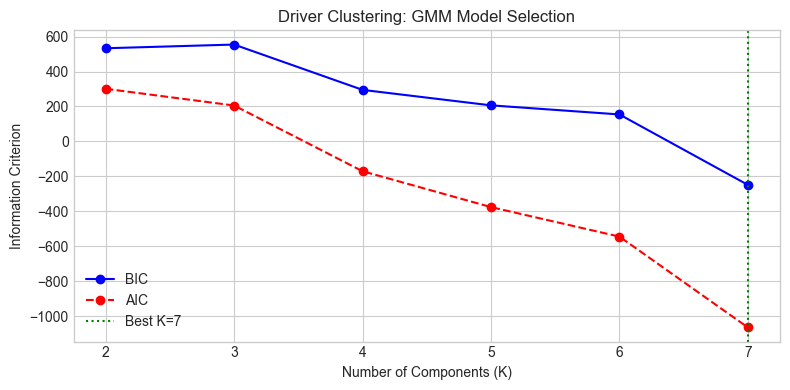

In [69]:
# Cell 30: GMM clustering on driver behavior profiles

# Select features for clustering - telemetry + degradation outcomes
driver_feature_cols = [
    # Throttle behavior
    'throttle_mean', 'throttle_std', 'on_throttle_pct', 'off_throttle_pct',
    # Brake behavior  
    'on_brake_pct',
    # Driving style
    'coasting_pct', 'speed_cv',
    # Engine usage
    'rpm_mean', 'rpm_std',
    # Tyre outcomes
    'avg_deg_rate', 'deg_consistency'
]

# Check which columns exist
available_cols = [c for c in driver_feature_cols if c in driver_profiles.columns]
print(f"Using {len(available_cols)} features for driver clustering:")
for c in available_cols:
    print(f"  - {c}")

# Prepare data
df_drivers = driver_profiles.dropna(subset=available_cols).copy()
X_drivers = df_drivers[available_cols].values

print(f"\nDrivers for clustering: {len(df_drivers)}")

# Scale features
from sklearn.preprocessing import StandardScaler
scaler_drivers = StandardScaler()
X_drivers_scaled = scaler_drivers.fit_transform(X_drivers)

# Find optimal K using GMM
print("\nFinding optimal number of driver clusters...")
k_max = min(7, len(df_drivers) // 3)  # Need at least 3 drivers per cluster
best_k_drivers, gmm_drivers, results_gmm_drivers = find_best_gmm(
    X_drivers_scaled, 
    k_range=range(2, k_max + 1)
)

print(f"\nOptimal K (by BIC): {best_k_drivers}")

# Assign clusters
labels_drivers = gmm_drivers.predict(X_drivers_scaled)
proba_drivers = gmm_drivers.predict_proba(X_drivers_scaled)
df_drivers['cluster_driver'] = labels_drivers
df_drivers['cluster_confidence'] = proba_drivers.max(axis=1)

print(f"Cluster sizes: {np.bincount(labels_drivers).tolist()}")

# Display results
display(results_gmm_drivers)

# Plot model selection
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_gmm_drivers['k'], results_gmm_drivers['bic'], 'o-', label='BIC', color='blue')
ax.plot(results_gmm_drivers['k'], results_gmm_drivers['aic'], 'o--', label='AIC', color='red')
ax.axvline(best_k_drivers, color='green', linestyle=':', label=f'Best K={best_k_drivers}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Driver Clustering: GMM Model Selection')
ax.legend()
plt.tight_layout()
plt.show()

DRIVER CLUSTER PROFILES (z-scored)


cluster_driver,0,1,2,3,4,5,6
throttle_mean,-0.81,-0.64,1.73,-1.16,0.02,0.09,0.77
throttle_std,0.30,1.03,-1.40,0.53,0.09,0.83,-1.38
on_throttle_pct,-0.80,-0.52,1.84,-1.15,-0.10,0.18,0.56
off_throttle_pct,0.59,0.78,-1.38,1.30,-0.10,0.01,-1.20
on_brake_pct,-0.42,-0.63,1.95,-1.15,-0.26,0.05,0.46
coasting_pct,0.57,0.82,-1.11,1.39,-0.23,-0.10,-1.34
speed_cv,-0.29,-0.32,2.25,-0.48,-0.57,-0.14,-0.44
rpm_mean,0.17,0.27,-2.22,0.51,0.70,0.12,0.45
rpm_std,-0.03,0.63,-2.14,0.94,0.25,0.18,0.17
avg_deg_rate,-2.04,0.46,-0.47,0.59,0.62,0.83,0.01


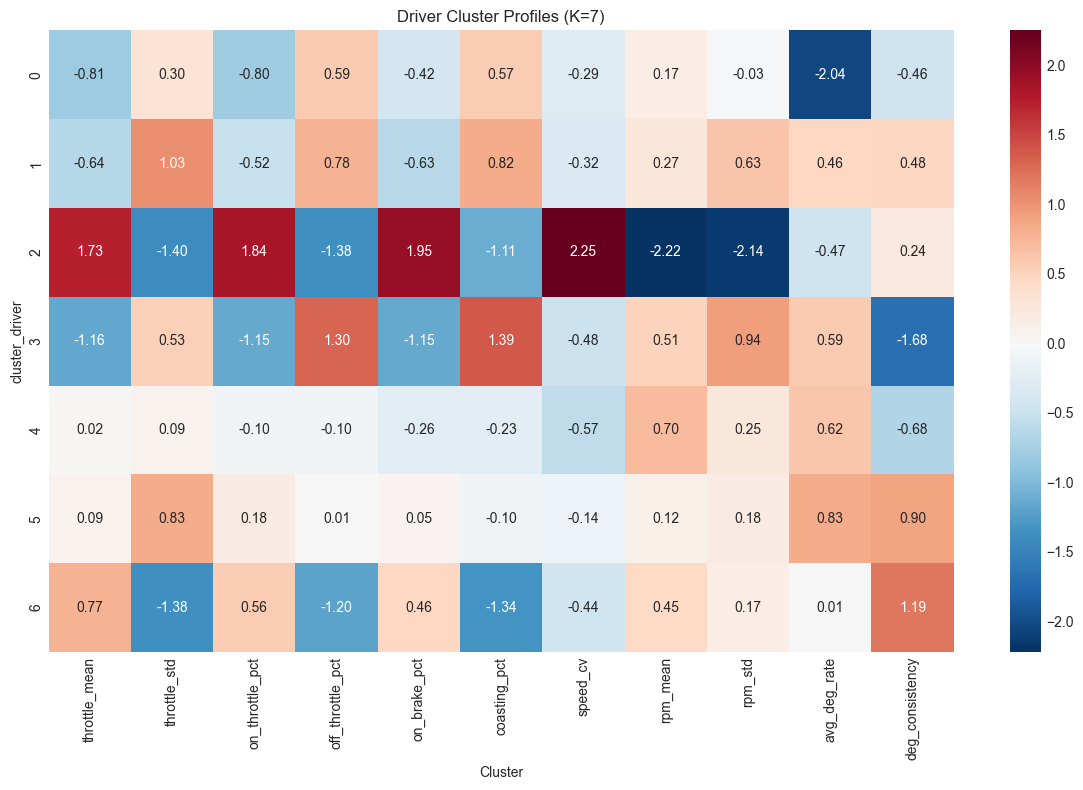


DRIVER ARCHETYPE INTERPRETATION

Cluster 0: Low on-throttle | High lift-coast | Tyre saver
  Drivers (4): LAW, LAW, LAW, VET

Cluster 1: Variable throttle | Low on-throttle | Light braker | High lift-coast
  Drivers (8): ALO, BOT, NOR, OCO, PER, RIC, STR, ZHO

Cluster 2: Smooth throttle | High on-throttle | Heavy braker | Minimal coasting | Variable pace
  Drivers (1): TSU

Cluster 3: Variable throttle | Low on-throttle | Light braker | High lift-coast | High deg | Predictable
  Drivers (7): DEV, DEV, GAS, LAW, PIA, TSU, VER

Cluster 4: Consistent pace | High deg | Predictable
  Drivers (6): DEV, HAM, LEC, RUS, SAI, STR

Cluster 5: Variable throttle | High deg | Unpredictable
  Drivers (5): ALB, HUL, LAT, MAG, SAR

Cluster 6: Smooth throttle | High on-throttle | Minimal coasting | Unpredictable
  Drivers (2): HUL, SAR


In [72]:
# Cell 31: Profile and interpret driver clusters

# Profile clusters using the column name (not labels array)
profile_drivers = profile_clusters(df_drivers, available_cols, 'cluster_driver')

print("=" * 70)
print("DRIVER CLUSTER PROFILES (z-scored)")
print("=" * 70)
display(profile_drivers.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(profile_drivers.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title(f'Driver Cluster Profiles (K={best_k_drivers})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Interpret each cluster
def interpret_driver_cluster(profile_row):
    """Auto-generate driver archetype label based on feature z-scores."""
    labels = []
    
    # Throttle behavior
    if profile_row.get('throttle_std', 0) < -0.5:
        labels.append("Smooth throttle")
    elif profile_row.get('throttle_std', 0) > 0.5:
        labels.append("Variable throttle")
    
    if profile_row.get('on_throttle_pct', 0) > 0.5:
        labels.append("High on-throttle")
    elif profile_row.get('on_throttle_pct', 0) < -0.5:
        labels.append("Low on-throttle")
    
    # Brake behavior
    if profile_row.get('on_brake_pct', 0) > 0.5:
        labels.append("Heavy braker")
    elif profile_row.get('on_brake_pct', 0) < -0.5:
        labels.append("Light braker")
    
    # Coasting
    if profile_row.get('coasting_pct', 0) > 0.5:
        labels.append("High lift-coast")
    elif profile_row.get('coasting_pct', 0) < -0.5:
        labels.append("Minimal coasting")
    
    # Speed consistency
    if profile_row.get('speed_cv', 0) < -0.5:
        labels.append("Consistent pace")
    elif profile_row.get('speed_cv', 0) > 0.5:
        labels.append("Variable pace")
    
    # Tyre outcomes
    if profile_row.get('avg_deg_rate', 0) < -0.5:
        labels.append("Tyre saver")
    elif profile_row.get('avg_deg_rate', 0) > 0.5:
        labels.append("High deg")
    
    if profile_row.get('deg_consistency', 0) < -0.5:
        labels.append("Predictable")
    elif profile_row.get('deg_consistency', 0) > 0.5:
        labels.append("Unpredictable")
    
    return " | ".join(labels) if labels else "Balanced"

print("\n" + "=" * 70)
print("DRIVER ARCHETYPE INTERPRETATION")
print("=" * 70)

for cluster_id in sorted(df_drivers['cluster_driver'].unique()):
    drivers_in_cluster = df_drivers[df_drivers['cluster_driver'] == cluster_id]['driver'].tolist()
    profile_row = profile_drivers[cluster_id]
    interpretation = interpret_driver_cluster(profile_row)
    
    print(f"\nCluster {cluster_id}: {interpretation}")
    print(f"  Drivers ({len(drivers_in_cluster)}): {', '.join(sorted(drivers_in_cluster))}")

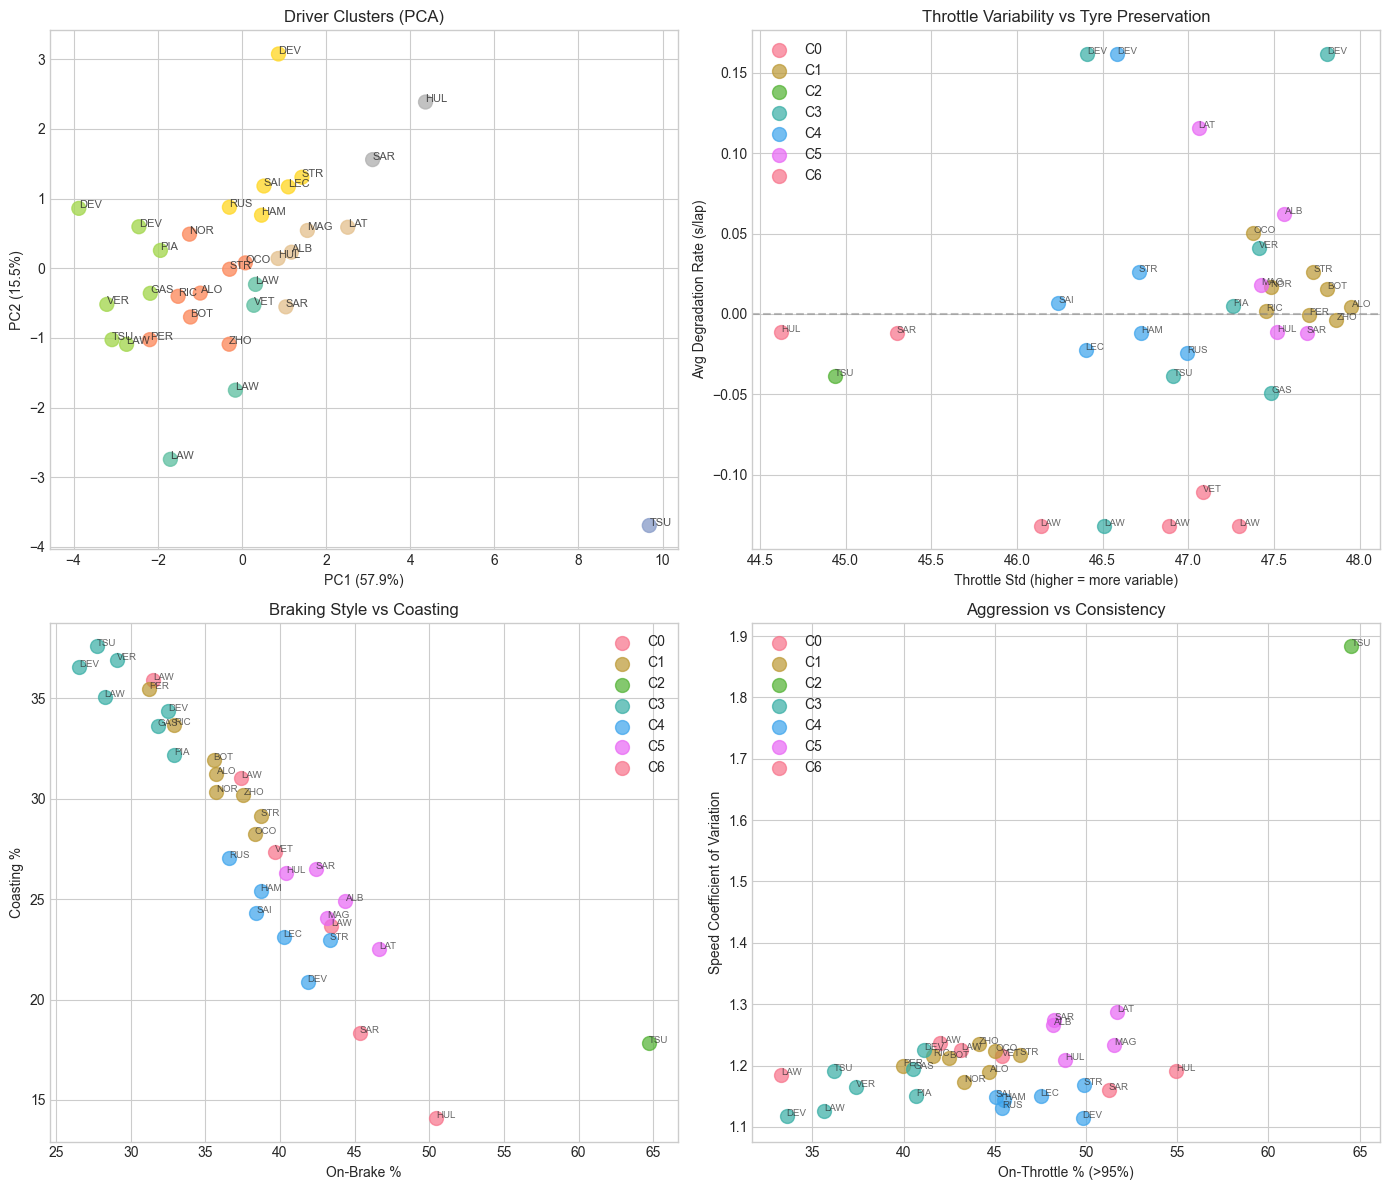

In [74]:
# Cell 32: Visualize driver clusters

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. PCA visualization
pca_drivers = PCA(n_components=2)
coords_drivers = pca_drivers.fit_transform(X_drivers_scaled)
df_drivers['pca1'] = coords_drivers[:, 0]
df_drivers['pca2'] = coords_drivers[:, 1]

ax = axes[0, 0]
colors_drivers = plt.cm.Set2(labels_drivers / max(labels_drivers.max(), 1))
ax.scatter(coords_drivers[:, 0], coords_drivers[:, 1], c=colors_drivers, s=100, alpha=0.8)
for i, row in df_drivers.iterrows():
    ax.annotate(row['driver'], (row['pca1'], row['pca2']), fontsize=8, alpha=0.8)
ax.set_xlabel(f'PC1 ({pca_drivers.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_drivers.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Driver Clusters (PCA)')

# 2. Throttle std vs Deg rate (smoothness vs tyre preservation)
ax = axes[0, 1]
for cl in range(best_k_drivers):
    mask = df_drivers['cluster_driver'] == cl
    ax.scatter(
        df_drivers.loc[mask, 'throttle_std'],
        df_drivers.loc[mask, 'avg_deg_rate'],
        label=f'C{cl}', s=100, alpha=0.7
    )
    for _, row in df_drivers[mask].iterrows():
        ax.annotate(row['driver'], (row['throttle_std'], row['avg_deg_rate']), 
                   fontsize=7, alpha=0.7)
ax.set_xlabel('Throttle Std (higher = more variable)')
ax.set_ylabel('Avg Degradation Rate (s/lap)')
ax.set_title('Throttle Variability vs Tyre Preservation')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.legend()

# 3. On-brake % vs Coasting %
ax = axes[1, 0]
for cl in range(best_k_drivers):
    mask = df_drivers['cluster_driver'] == cl
    ax.scatter(
        df_drivers.loc[mask, 'on_brake_pct'],
        df_drivers.loc[mask, 'coasting_pct'],
        label=f'C{cl}', s=100, alpha=0.7
    )
    for _, row in df_drivers[mask].iterrows():
        ax.annotate(row['driver'], (row['on_brake_pct'], row['coasting_pct']), 
                   fontsize=7, alpha=0.7)
ax.set_xlabel('On-Brake %')
ax.set_ylabel('Coasting %')
ax.set_title('Braking Style vs Coasting')
ax.legend()

# 4. On-throttle % vs Speed CV (aggression vs consistency)
ax = axes[1, 1]
for cl in range(best_k_drivers):
    mask = df_drivers['cluster_driver'] == cl
    ax.scatter(
        df_drivers.loc[mask, 'on_throttle_pct'],
        df_drivers.loc[mask, 'speed_cv'],
        label=f'C{cl}', s=100, alpha=0.7
    )
    for _, row in df_drivers[mask].iterrows():
        ax.annotate(row['driver'], (row['on_throttle_pct'], row['speed_cv']), 
                   fontsize=7, alpha=0.7)
ax.set_xlabel('On-Throttle % (>95%)')
ax.set_ylabel('Speed Coefficient of Variation')
ax.set_title('Aggression vs Consistency')
ax.legend()

plt.tight_layout()
plt.show()

In [75]:
# Cell 33: Driver ranking table with cluster labels

# Create driver summary table
driver_summary = df_drivers[['driver', 'cluster_driver', 'cluster_confidence', 
                              'n_stints', 'total_laps', 'avg_deg_rate', 'deg_consistency',
                              'on_throttle_pct', 'coasting_pct', 'on_brake_pct']].copy()

# Add archetype labels
archetype_map = {}
for cluster_id in sorted(df_drivers['cluster_driver'].unique()):
    profile_row = profile_drivers[cluster_id]
    archetype_map[cluster_id] = interpret_driver_cluster(profile_row)

driver_summary['archetype'] = driver_summary['cluster_driver'].map(archetype_map)

# Sort by avg_deg_rate (best tyre savers first)
driver_summary = driver_summary.sort_values('avg_deg_rate')

# Remove duplicate driver entries (keep first)
driver_summary = driver_summary.drop_duplicates(subset=['driver'], keep='first')

print("=" * 70)
print("DRIVER TYRE MANAGEMENT RANKING (by Telemetry Behavior)")
print("=" * 70)
print("(Lower deg_rate = better tyre preservation)\n")

display(driver_summary.round(3))

# Top tyre savers
print("\n🏆 TOP 5 TYRE SAVERS:")
for i, (_, row) in enumerate(driver_summary.head(5).iterrows(), 1):
    print(f"  {i}. {row['driver']}: {row['avg_deg_rate']:.3f} s/lap")
    print(f"     On-throttle: {row['on_throttle_pct']:.1f}% | Coasting: {row['coasting_pct']:.1f}% | Braking: {row['on_brake_pct']:.1f}%")

# Highest degradation  
print("\n💀 HIGHEST DEGRADATION:")
for i, (_, row) in enumerate(driver_summary.tail(5).iloc[::-1].iterrows(), 1):
    print(f"  {i}. {row['driver']}: {row['avg_deg_rate']:.3f} s/lap")
    print(f"     On-throttle: {row['on_throttle_pct']:.1f}% | Coasting: {row['coasting_pct']:.1f}% | Braking: {row['on_brake_pct']:.1f}%")

DRIVER TYRE MANAGEMENT RANKING (by Telemetry Behavior)
(Lower deg_rate = better tyre preservation)



,driver,cluster_driver,cluster_confidence,n_stints,total_laps,avg_deg_rate,deg_consistency,on_throttle_pct,coasting_pct,on_brake_pct,archetype
18,LAW,3,1.0,6,91,-0.132,0.220,35.656,35.087,28.251,Variable throttle | Low on-throttle | Light br...
37,VET,0,1.0,10,159,-0.111,0.180,45.369,27.345,39.677,Low on-throttle | High lift-coast | Tyre saver
32,GAS,3,1.0,24,409,-0.049,0.164,40.519,33.648,31.797,Variable throttle | Low on-throttle | Light br...
25,TSU,3,1.0,36,546,-0.039,0.228,36.178,37.584,27.727,Variable throttle | Low on-throttle | Light br...
26,RUS,4,1.0,65,1035,-0.024,0.216,45.416,27.055,36.606,Consistent pace | High deg | Predictable
0,LEC,4,1.0,58,889,-0.022,0.252,47.517,23.093,40.238,Consistent pace | High deg | Predictable
1,HAM,4,1.0,45,751,-0.012,0.197,45.495,25.410,38.701,Consistent pace | High deg | Predictable
9,SAR,5,1.0,22,329,-0.012,0.246,48.265,26.509,42.391,Variable throttle | High deg | Unpredictable
36,HUL,6,1.0,27,416,-0.011,0.259,54.926,14.102,50.469,Smooth throttle | High on-throttle | Minimal c...
6,ZHO,1,1.0,28,405,-0.004,0.264,44.115,30.181,37.555,Variable throttle | Low on-throttle | Light br...



🏆 TOP 5 TYRE SAVERS:
  1. LAW: -0.132 s/lap
     On-throttle: 35.7% | Coasting: 35.1% | Braking: 28.3%
  2. VET: -0.111 s/lap
     On-throttle: 45.4% | Coasting: 27.3% | Braking: 39.7%
  3. GAS: -0.049 s/lap
     On-throttle: 40.5% | Coasting: 33.6% | Braking: 31.8%
  4. TSU: -0.039 s/lap
     On-throttle: 36.2% | Coasting: 37.6% | Braking: 27.7%
  5. RUS: -0.024 s/lap
     On-throttle: 45.4% | Coasting: 27.1% | Braking: 36.6%

💀 HIGHEST DEGRADATION:
  1. DEV: 0.162 s/lap
     On-throttle: 33.6% | Coasting: 36.5% | Braking: 26.5%
  2. LAT: 0.116 s/lap
     On-throttle: 51.7% | Coasting: 22.5% | Braking: 46.6%
  3. ALB: 0.062 s/lap
     On-throttle: 48.2% | Coasting: 24.9% | Braking: 44.4%
  4. OCO: 0.050 s/lap
     On-throttle: 45.0% | Coasting: 28.2% | Braking: 38.3%
  5. VER: 0.041 s/lap
     On-throttle: 37.4% | Coasting: 36.9% | Braking: 29.1%


# Part 5: Session Type Clustering

**Goal:** Understand how degradation patterns differ across session types (FP1, FP2, FP3, Quali, Race) and whether practice data predicts race behavior.

**Features:**
- Degradation rate statistics (mean, std, range)
- Stint length patterns
- Compound usage diversity
- Push level indicators

In [78]:
# Cell 34: Aggregate features by session type
print("=" * 70)
print("SESSION TYPE CLUSTERING")
print("=" * 70)

# Check what session types exist in the raw data
session_check_sql = f"""
SELECT DISTINCT session_type, COUNT(*) as cnt
FROM read_parquet('{SILVER_PATH.resolve() / "stints_degradation.parquet"}'.replace('\\\\', '/'))
GROUP BY session_type
"""

try:
    session_check = conn.execute(session_check_sql.replace('\\', '/')).df()
    print("Session types in stints_degradation:")
    display(session_check)
except Exception as e:
    print(f"Error: {e}")

# The stints data likely only has race sessions - let's check clean_air_laps
lap_session_sql = f"""
SELECT DISTINCT session_type, COUNT(*) as cnt
FROM read_parquet('{str(SILVER_PATH.resolve() / "clean_air_laps.parquet").replace(chr(92), "/")}')
GROUP BY session_type
"""
try:
    lap_sessions = conn.execute(lap_session_sql).df()
    print("\nSession types in clean_air_laps:")
    display(lap_sessions)
except Exception as e:
    print(f"Error: {e}")

# If only race data, cluster by race event characteristics instead
print("\n" + "=" * 70)
print("Pivoting to RACE EVENT clustering (per GP characteristics)")
print("=" * 70)

# Aggregate by race event (year + gp)
race_event_features = stints.groupby(['year', 'gp_name']).agg({
    'deg_rate_per_lap': ['mean', 'std', 'min', 'max', 'count'],
    'num_laps': ['mean', 'sum', 'max'],
    'compound': lambda x: x.nunique(),
    'team': lambda x: x.nunique(),
}).reset_index()

race_event_features.columns = ['year', 'gp_name',
                               'deg_rate_mean', 'deg_rate_std', 'deg_rate_min', 'deg_rate_max', 'n_stints',
                               'stint_length_mean', 'total_laps', 'max_stint_length',
                               'compound_diversity', 'team_diversity']

# Calculate deg range
race_event_features['deg_rate_range'] = race_event_features['deg_rate_max'] - race_event_features['deg_rate_min']
race_event_features['deg_rate_std'] = race_event_features['deg_rate_std'].fillna(0)

print(f"Race event profiles: {len(race_event_features)} races")
display(race_event_features.head(10))

SESSION TYPE CLUSTERING
Error: Parser Error: syntax error at or near "("

LINE 3: .../data/lake/silver/domain1/stints_degradation.parquet'.replace('//', '/'))
                                                                        ^

Session types in clean_air_laps:


,session_type,cnt
0,R,28819



Pivoting to RACE EVENT clustering (per GP characteristics)
Race event profiles: 68 races


,year,gp_name,deg_rate_mean,deg_rate_std,deg_rate_min,deg_rate_max,n_stints,stint_length_mean,total_laps,max_stint_length,compound_diversity,team_diversity,deg_rate_range
0,2022,Abu Dhabi Grand Prix,-0.148948,0.918375,-3.195886,1.280856,33,13.393939,442,36,2,10,4.476742
1,2022,Australian Grand Prix,-1.112789,3.201743,-14.496486,2.297268,24,13.125000,315,30,2,10,16.793754
2,2022,Austrian Grand Prix,-0.183232,0.707757,-3.375929,1.383445,37,11.324324,419,21,3,9,4.759374
3,2022,Azerbaijan Grand Prix,-1.121576,3.907839,-17.904600,0.435646,21,14.238095,299,28,2,8,18.340246
4,2022,Bahrain Grand Prix,-0.083108,2.406968,-3.716657,13.429614,44,8.863636,390,19,3,10,17.146271
5,2022,Belgian Grand Prix,-0.112641,1.258910,-5.602571,0.903891,25,9.160000,229,16,3,9,6.506462
6,2022,British Grand Prix,-0.700409,2.249117,-7.319714,1.640700,27,9.592593,259,22,3,9,8.960414
7,2022,Canadian Grand Prix,-0.234100,0.842901,-2.353154,1.274382,30,14.466667,434,31,2,10,3.627536
8,2022,Dutch Grand Prix,-0.555568,1.426212,-7.204814,1.390607,40,11.500000,460,31,3,10,8.595421
9,2022,Emilia Romagna Grand Prix,-0.115044,1.517908,-3.492368,3.098968,24,18.000000,432,42,3,10,6.591336


Race events for clustering: 68

Finding optimal number of race event clusters...

Optimal K (by BIC): 6
Cluster sizes: [6, 27, 2, 5, 6, 22]


,k,bic,aic,silhouette,sizes
0,2,758.514617,600.929570,0.613772,"[64, 4]"
1,3,835.792864,598.305539,0.162722,"[25, 40, 3]"
2,4,880.145015,562.755413,0.124325,"[34, 30, 3, 1]"
3,5,581.950546,184.658667,0.206270,"[2, 23, 12, 2, 29]"
4,6,204.096358,-273.097799,0.128592,"[6, 27, 2, 5, 6, 22]"
5,7,724.713495,167.617061,0.133625,"[23, 9, 1, 7, 25, 1, 2]"


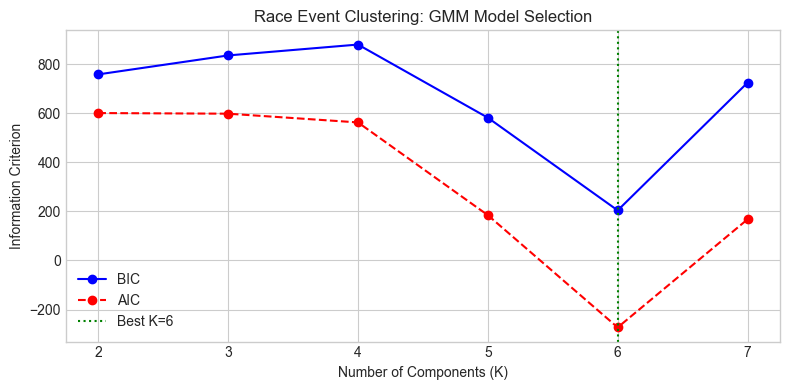

In [79]:
# Cell 35: GMM clustering on race event profiles
# (Session type clustering pivoted to race event clustering since only Race data available)

# Features for race event clustering
race_event_feature_cols = [
    'deg_rate_mean', 'deg_rate_std', 'deg_rate_range',
    'stint_length_mean', 'max_stint_length',
    'compound_diversity', 'n_stints'
]

# Filter events with enough data
df_events = race_event_features[race_event_features['n_stints'] >= 5].copy()
df_events = df_events.dropna(subset=race_event_feature_cols)

print(f"Race events for clustering: {len(df_events)}")

# Prepare data
X_events = df_events[race_event_feature_cols].values

# Scale
scaler_events = StandardScaler()
X_events_scaled = scaler_events.fit_transform(X_events)

# Find optimal K
print("\nFinding optimal number of race event clusters...")
best_k_events, gmm_events, results_gmm_events = find_best_gmm(
    X_events_scaled, 
    k_range=range(2, 8)
)

print(f"\nOptimal K (by BIC): {best_k_events}")

# Assign clusters
labels_events = gmm_events.predict(X_events_scaled)
df_events['cluster_event'] = labels_events

print(f"Cluster sizes: {np.bincount(labels_events).tolist()}")

# Display results
display(results_gmm_events)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_gmm_events['k'], results_gmm_events['bic'], 'o-', label='BIC', color='blue')
ax.plot(results_gmm_events['k'], results_gmm_events['aic'], 'o--', label='AIC', color='red')
ax.axvline(best_k_events, color='green', linestyle=':', label=f'Best K={best_k_events}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Race Event Clustering: GMM Model Selection')
ax.legend()
plt.tight_layout()
plt.show()

RACE EVENT CLUSTER PROFILES (z-scored)


cluster_event,0,1,2,3,4,5
deg_rate_mean,0.24,0.43,-1.98,0.74,0.04,0.53
deg_rate_std,-0.28,-0.39,2.03,-0.56,-0.32,-0.49
deg_rate_range,-0.16,-0.41,2.02,-0.60,-0.39,-0.47
stint_length_mean,-0.43,-0.04,-0.22,-0.67,1.98,-0.62
max_stint_length,0.47,-0.10,0.17,-1.33,1.55,-0.76
compound_diversity,0.42,-1.20,1.58,-0.93,-0.05,0.19
n_stints,1.66,-0.14,0.27,-0.98,-1.06,0.26


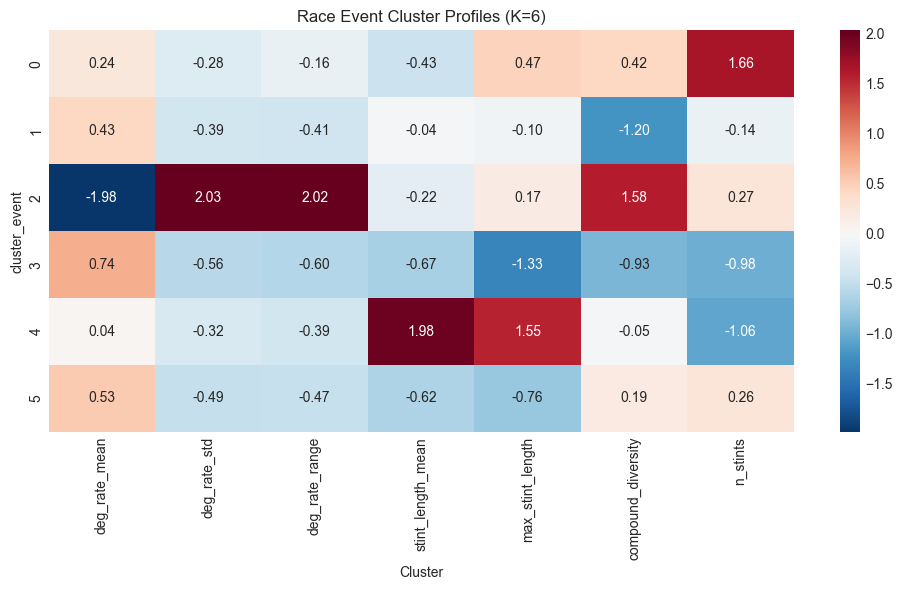


RACE EVENT ARCHETYPES

Cluster 0: Many stops
  Races (6): 2022 Dutch Grand Prix, 2022 Mexico City Grand Prix, 2022 Spanish Grand Prix, 2023 Dutch Grand Prix, 2024 Dutch Grand Prix, ...+1 more

Cluster 1: 1-compound dominant
  Races (27): 2022 Abu Dhabi Grand Prix, 2022 Australian Grand Prix, 2022 Azerbaijan Grand Prix, 2022 Canadian Grand Prix, 2022 French Grand Prix, ...+22 more

Cluster 2: Low-deg race | Variable deg | Mixed strategy
  Races (2): 2023 Monaco Grand Prix, 2024 British Grand Prix

Cluster 3: High-deg race | Consistent deg | Short stints | 1-compound dominant | Few stops
  Races (5): 2022 Japanese Grand Prix, 2022 Singapore Grand Prix, 2023 Belgian Grand Prix, 2024 Belgian Grand Prix, 2024 Las Vegas Grand Prix

Cluster 4: Long stints | Few stops
  Races (6): 2022 Emilia Romagna Grand Prix, 2022 Monaco Grand Prix, 2023 Australian Grand Prix, 2024 Monaco Grand Prix, 2024 Saudi Arabian Grand Prix, ...+1 more

Cluster 5: High-deg race | Short stints
  Races (22): 2022 Austr

In [80]:
# Cell 36: Profile and visualize race event clusters

# Profile clusters
profile_events = profile_clusters(df_events, race_event_feature_cols, 'cluster_event')

print("=" * 70)
print("RACE EVENT CLUSTER PROFILES (z-scored)")
print("=" * 70)
display(profile_events.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(profile_events.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title(f'Race Event Cluster Profiles (K={best_k_events})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Interpret event clusters
def interpret_event_cluster(profile_row):
    """Auto-generate race event archetype."""
    labels = []
    
    if profile_row.get('deg_rate_mean', 0) > 0.5:
        labels.append("High-deg race")
    elif profile_row.get('deg_rate_mean', 0) < -0.5:
        labels.append("Low-deg race")
    
    if profile_row.get('deg_rate_std', 0) > 0.5:
        labels.append("Variable deg")
    elif profile_row.get('deg_rate_std', 0) < -0.5:
        labels.append("Consistent deg")
    
    if profile_row.get('stint_length_mean', 0) > 0.5:
        labels.append("Long stints")
    elif profile_row.get('stint_length_mean', 0) < -0.5:
        labels.append("Short stints")
    
    if profile_row.get('compound_diversity', 0) > 0.5:
        labels.append("Mixed strategy")
    elif profile_row.get('compound_diversity', 0) < -0.5:
        labels.append("1-compound dominant")
    
    if profile_row.get('n_stints', 0) > 0.5:
        labels.append("Many stops")
    elif profile_row.get('n_stints', 0) < -0.5:
        labels.append("Few stops")
    
    return " | ".join(labels) if labels else "Standard race"

print("\n" + "=" * 70)
print("RACE EVENT ARCHETYPES")
print("=" * 70)

for cluster_id in sorted(df_events['cluster_event'].unique()):
    events_in_cluster = df_events[df_events['cluster_event'] == cluster_id][['year', 'gp_name']].values.tolist()
    profile_row = profile_events[cluster_id]
    interpretation = interpret_event_cluster(profile_row)
    
    print(f"\nCluster {cluster_id}: {interpretation}")
    gp_names = [f"{y} {gp}" for y, gp in events_in_cluster[:5]]
    if len(events_in_cluster) > 5:
        gp_names.append(f"...+{len(events_in_cluster) - 5} more")
    print(f"  Races ({len(events_in_cluster)}): {', '.join(gp_names)}")

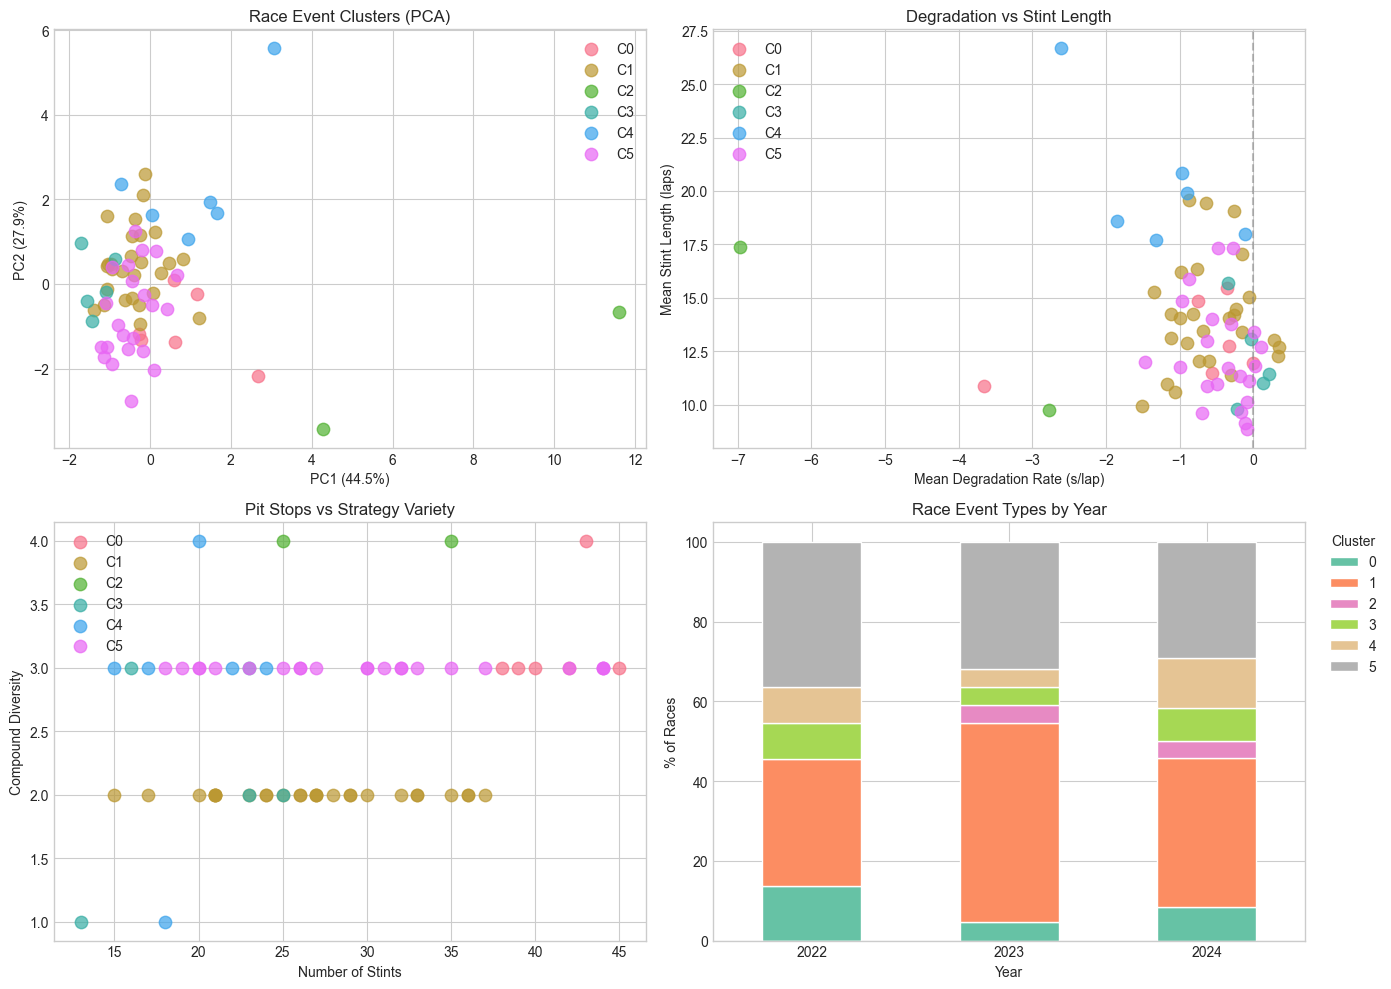


RACE EVENT CLUSTERING SUMMARY
Cluster 0 (6 races): Many stops
Cluster 1 (27 races): 1-compound dominant
Cluster 2 (2 races): Low-deg race | Variable deg | Mixed strategy
Cluster 3 (5 races): High-deg race | Consistent deg | Short stints | 1-compound dominant | Few stops
Cluster 4 (6 races): Long stints | Few stops
Cluster 5 (22 races): High-deg race | Short stints


In [81]:
# Cell 37: Visualize race event clusters

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. PCA visualization
pca_events = PCA(n_components=2)
coords_events = pca_events.fit_transform(X_events_scaled)
df_events['pca1'] = coords_events[:, 0]
df_events['pca2'] = coords_events[:, 1]

ax = axes[0, 0]
for cl in range(best_k_events):
    mask = df_events['cluster_event'] == cl
    ax.scatter(df_events.loc[mask, 'pca1'], df_events.loc[mask, 'pca2'],
              label=f'C{cl}', s=80, alpha=0.7)
ax.set_xlabel(f'PC1 ({pca_events.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_events.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Race Event Clusters (PCA)')
ax.legend()

# 2. Deg rate vs Stint length by cluster
ax = axes[0, 1]
for cl in range(best_k_events):
    mask = df_events['cluster_event'] == cl
    ax.scatter(df_events.loc[mask, 'deg_rate_mean'],
              df_events.loc[mask, 'stint_length_mean'],
              label=f'C{cl}', s=80, alpha=0.7)
ax.set_xlabel('Mean Degradation Rate (s/lap)')
ax.set_ylabel('Mean Stint Length (laps)')
ax.set_title('Degradation vs Stint Length')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.legend()

# 3. N_stints vs Compound diversity
ax = axes[1, 0]
for cl in range(best_k_events):
    mask = df_events['cluster_event'] == cl
    ax.scatter(df_events.loc[mask, 'n_stints'],
              df_events.loc[mask, 'compound_diversity'],
              label=f'C{cl}', s=80, alpha=0.7)
ax.set_xlabel('Number of Stints')
ax.set_ylabel('Compound Diversity')
ax.set_title('Pit Stops vs Strategy Variety')
ax.legend()

# 4. Event cluster distribution by year
ax = axes[1, 1]
year_cluster = pd.crosstab(df_events['year'], df_events['cluster_event'], normalize='index') * 100
year_cluster.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_xlabel('Year')
ax.set_ylabel('% of Races')
ax.set_title('Race Event Types by Year')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1))
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 70)
print("RACE EVENT CLUSTERING SUMMARY")
print("=" * 70)
for cl in range(best_k_events):
    mask = df_events['cluster_event'] == cl
    profile_row = profile_events[cl]
    interpretation = interpret_event_cluster(profile_row)
    count = mask.sum()
    print(f"Cluster {cl} ({count} races): {interpretation}")

# Part 6: Team Strategy Clustering

**Goal:** Identify team-level strategic philosophies across races.

**Features:**
- Average stint length (conservative vs aggressive timing)
- First stop timing
- Number of stops per race
- Compound diversity
- Degradation tolerance
- Position changes around pit stops

In [83]:
# Cell 38: Extract team strategy features from race data
print("=" * 70)
print("TEAM STRATEGY CLUSTERING")
print("=" * 70)

# Check session type value
print(f"Session types in analysis_df: {analysis_df['session_type'].unique()}")

# Use all data (it's all race data since session_type = 'R')
race_stints = analysis_df.copy()
print(f"Race stints: {len(race_stints)}")
print(f"Unique teams: {race_stints['team'].nunique()}")

# Aggregate features by team
team_strategy = race_stints.groupby('team').agg({
    # Stint characteristics
    'num_laps': ['mean', 'std', 'max'],
    'deg_rate_per_lap': ['mean', 'std'],
    # Stint count per race (proxy)
    'stint': ['mean', 'max'],
    # Compound usage
    'compound': lambda x: x.nunique(),
}).reset_index()

team_strategy.columns = ['team', 
                          'avg_stint_length', 'stint_length_std', 'max_stint_length',
                          'avg_deg_rate', 'deg_rate_std',
                          'avg_stint_number', 'max_stint_number',
                          'compound_diversity']

# Calculate additional metrics from race-level aggregation
race_team_agg = race_stints.groupby(['year', 'gp_name', 'team']).agg({
    'stint': 'max',  # Number of stints in race
    'first_lap': 'min',  # First lap of first stint
    'num_laps': 'sum',  # Total laps
    'deg_rate_per_lap': 'mean',
    'compound': lambda x: x.nunique()
}).reset_index()
race_team_agg.columns = ['year', 'gp_name', 'team', 'n_stints_race', 'first_stint_start', 
                         'total_laps_race', 'race_avg_deg', 'compounds_used']

# Aggregate to team level
team_race_stats = race_team_agg.groupby('team').agg({
    'n_stints_race': ['mean', 'std'],
    'first_stint_start': 'mean',
    'compounds_used': 'mean',
    'race_avg_deg': ['mean', 'std'],
    'year': 'count'  # Number of races
}).reset_index()
team_race_stats.columns = ['team', 'avg_stops_per_race', 'stops_variability',
                            'avg_first_stint_start', 'avg_compounds_per_race',
                            'team_avg_deg', 'team_deg_variability', 'n_races']

# Merge with team_strategy
team_profiles = team_strategy.merge(team_race_stats, on='team', how='inner')

# Filter teams with enough data
min_races = 5
team_profiles = team_profiles[team_profiles['n_races'] >= min_races]

print(f"Teams with >= {min_races} races: {len(team_profiles)}")
print(f"\nTeams: {team_profiles['team'].tolist()}")

display(team_profiles)

TEAM STRATEGY CLUSTERING
Session types in analysis_df: ['R']
Race stints: 926
Unique teams: 12
Teams with >= 5 races: 12

Teams: ['Alfa Romeo', 'AlphaTauri', 'Alpine', 'Aston Martin', 'Ferrari', 'Haas F1 Team', 'Kick Sauber', 'McLaren', 'Mercedes', 'RB', 'Red Bull Racing', 'Williams']


,team,avg_stint_length,stint_length_std,max_stint_length,avg_deg_rate,deg_rate_std,avg_stint_number,max_stint_number,compound_diversity,avg_stops_per_race,stops_variability,avg_first_stint_start,avg_compounds_per_race,team_avg_deg,team_deg_variability,n_races
0,Alfa Romeo,15.090909,6.911782,29,-0.042706,0.261190,2.333333,4.0,4,2.450000,0.887041,25.300000,1.300000,-0.035801,0.216541,20
1,AlphaTauri,14.523810,7.877842,39,-0.036042,0.223507,2.476190,5.0,4,2.680000,0.988264,22.480000,1.280000,-0.044904,0.189855,25
2,Alpine,15.944444,7.479340,35,0.016732,0.207500,2.152778,4.0,4,2.372093,0.817174,21.302326,1.302326,0.032795,0.164504,43
3,Aston Martin,15.511364,8.319751,42,0.007502,0.236330,2.306818,5.0,4,2.510204,0.892619,20.530612,1.367347,0.009550,0.217705,49
4,Ferrari,15.299145,7.332339,38,-0.007781,0.235911,2.102564,4.0,4,2.560000,0.674915,18.340000,1.460000,-0.007201,0.186218,50
5,Haas F1 Team,16.552941,8.394309,35,0.008291,0.233666,2.352941,5.0,4,2.590909,0.995763,22.477273,1.340909,0.003470,0.231422,44
6,Kick Sauber,15.038462,7.576177,31,0.068778,0.207335,2.192308,4.0,4,2.642857,0.633324,25.000000,1.571429,0.049212,0.166535,14
7,McLaren,17.471154,7.901034,44,0.016803,0.215676,2.336538,6.0,4,2.673469,0.898790,21.061224,1.530612,-0.015023,0.183563,49
8,Mercedes,16.236364,7.533323,39,-0.019143,0.207517,2.254545,5.0,4,2.454545,0.812362,20.563636,1.381818,-0.028620,0.178792,55
9,RB,18.437500,8.755712,34,-0.048822,0.218274,2.125000,4.0,4,2.363636,0.809040,22.090909,1.090909,-0.063950,0.224946,11


Using 8 features: ['avg_stint_length', 'stint_length_std', 'max_stint_length', 'avg_deg_rate', 'deg_rate_std', 'avg_stops_per_race', 'stops_variability', 'compound_diversity']
Teams for clustering: 12

Finding optimal K (max=6)...

Optimal K (by BIC): 3
Cluster sizes: [3, 5, 4]


,k,bic,aic,silhouette,sizes
0,2,49.331161,6.174469,0.136658,"[9, 3]"
1,3,-241.338752,-306.316243,0.171489,"[3, 5, 4]"
2,4,-214.938222,-301.736513,0.191291,"[3, 5, 1, 3]"
3,5,-230.257880,-338.876970,0.213605,"[2, 3, 4, 1, 2]"
4,6,-203.857350,-334.297239,0.246485,"[3, 2, 1, 2, 1, 3]"


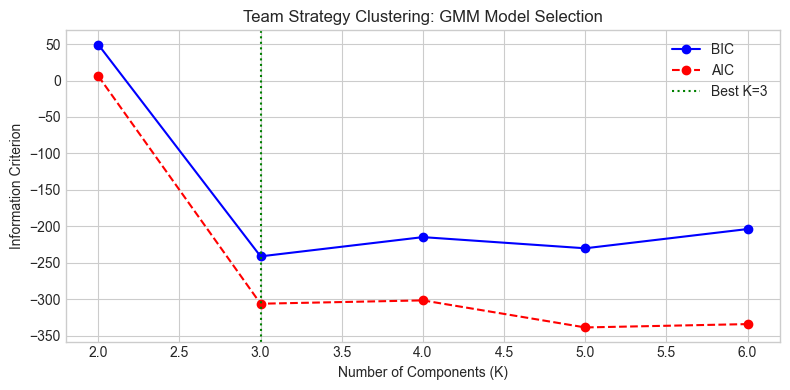

In [84]:
# Cell 39: GMM clustering on team strategy profiles

# Features for team clustering
team_feature_cols = [
    'avg_stint_length', 'stint_length_std', 'max_stint_length',
    'avg_deg_rate', 'deg_rate_std',
    'avg_stops_per_race', 'stops_variability',
    'compound_diversity'
]

# Check available columns
available_team_cols = [c for c in team_feature_cols if c in team_profiles.columns]
print(f"Using {len(available_team_cols)} features: {available_team_cols}")

# Prepare data
df_teams = team_profiles.dropna(subset=available_team_cols).copy()
X_teams = df_teams[available_team_cols].values

print(f"Teams for clustering: {len(df_teams)}")

# Scale
scaler_teams = StandardScaler()
X_teams_scaled = scaler_teams.fit_transform(X_teams)

# Find optimal K
k_max_teams = min(6, len(df_teams) // 2)
print(f"\nFinding optimal K (max={k_max_teams})...")
best_k_teams, gmm_teams, results_gmm_teams = find_best_gmm(
    X_teams_scaled, 
    k_range=range(2, k_max_teams + 1)
)

print(f"\nOptimal K (by BIC): {best_k_teams}")

# Assign clusters
labels_teams = gmm_teams.predict(X_teams_scaled)
df_teams['cluster_team'] = labels_teams

print(f"Cluster sizes: {np.bincount(labels_teams).tolist()}")

display(results_gmm_teams)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_gmm_teams['k'], results_gmm_teams['bic'], 'o-', label='BIC', color='blue')
ax.plot(results_gmm_teams['k'], results_gmm_teams['aic'], 'o--', label='AIC', color='red')
ax.axvline(best_k_teams, color='green', linestyle=':', label=f'Best K={best_k_teams}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Team Strategy Clustering: GMM Model Selection')
ax.legend()
plt.tight_layout()
plt.show()

TEAM STRATEGY CLUSTER PROFILES (z-scored)


cluster_team,0,1,2
avg_stint_length,0.87,0.23,-1.09
stint_length_std,0.34,0.78,-1.13
max_stint_length,-0.40,1.14,-0.74
avg_deg_rate,-1.07,0.15,0.92
deg_rate_std,-0.96,-0.07,1.03
avg_stops_per_race,-1.14,0.73,0.41
stops_variability,-0.24,1.10,-0.86
compound_diversity,0.00,0.00,0.00


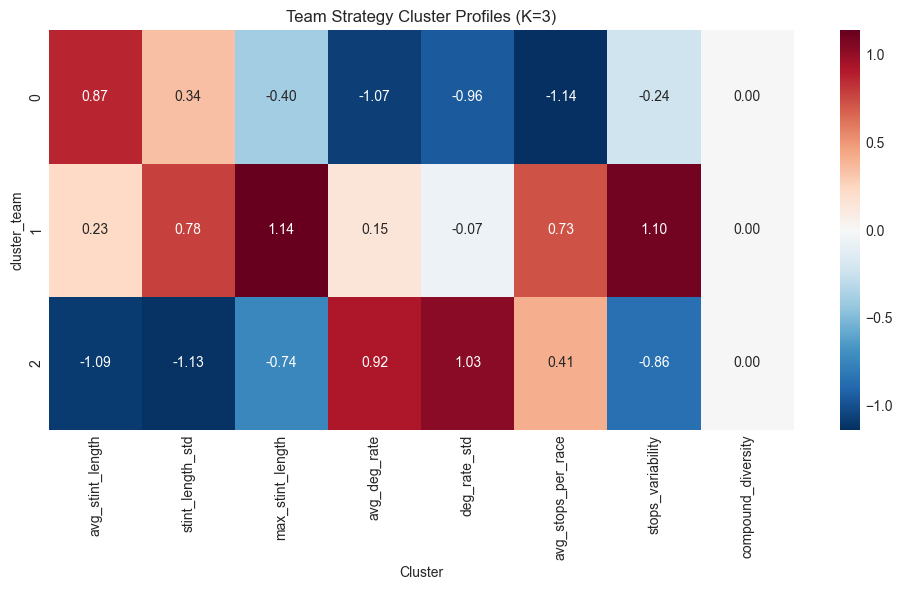


TEAM STRATEGY ARCHETYPES

Cluster 0: Long stints | Low deg | 1-stop preference
  Teams: Alpine, Mercedes, RB

Cluster 1: Adaptive | Multi-stop
  Teams: AlphaTauri, Aston Martin, Haas F1 Team, McLaren, Red Bull Racing

Cluster 2: Short stints | Consistent | High deg tolerance
  Teams: Alfa Romeo, Ferrari, Kick Sauber, Williams


In [85]:
# Cell 40: Profile and interpret team strategy clusters

# Profile clusters
profile_teams = profile_clusters(df_teams, available_team_cols, 'cluster_team')

print("=" * 70)
print("TEAM STRATEGY CLUSTER PROFILES (z-scored)")
print("=" * 70)
display(profile_teams.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(profile_teams.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title(f'Team Strategy Cluster Profiles (K={best_k_teams})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Interpret clusters
def interpret_team_cluster(profile_row):
    """Auto-generate team strategy archetype."""
    labels = []
    
    # Stint length
    if profile_row.get('avg_stint_length', 0) > 0.5:
        labels.append("Long stints")
    elif profile_row.get('avg_stint_length', 0) < -0.5:
        labels.append("Short stints")
    
    # Stops variability
    if profile_row.get('stops_variability', 0) > 0.5:
        labels.append("Adaptive")
    elif profile_row.get('stops_variability', 0) < -0.5:
        labels.append("Consistent")
    
    # Deg rate
    if profile_row.get('avg_deg_rate', 0) > 0.5:
        labels.append("High deg tolerance")
    elif profile_row.get('avg_deg_rate', 0) < -0.5:
        labels.append("Low deg")
    
    # Compound usage
    if profile_row.get('compound_diversity', 0) > 0.5:
        labels.append("Diverse compounds")
    elif profile_row.get('compound_diversity', 0) < -0.5:
        labels.append("Conservative compounds")
    
    # Stops per race
    if profile_row.get('avg_stops_per_race', 0) > 0.5:
        labels.append("Multi-stop")
    elif profile_row.get('avg_stops_per_race', 0) < -0.5:
        labels.append("1-stop preference")
    
    return " | ".join(labels) if labels else "Balanced"

print("\n" + "=" * 70)
print("TEAM STRATEGY ARCHETYPES")
print("=" * 70)

for cluster_id in sorted(df_teams['cluster_team'].unique()):
    teams_in_cluster = df_teams[df_teams['cluster_team'] == cluster_id]['team'].tolist()
    profile_row = profile_teams[cluster_id]
    interpretation = interpret_team_cluster(profile_row)
    
    print(f"\nCluster {cluster_id}: {interpretation}")
    print(f"  Teams: {', '.join(sorted(teams_in_cluster))}")

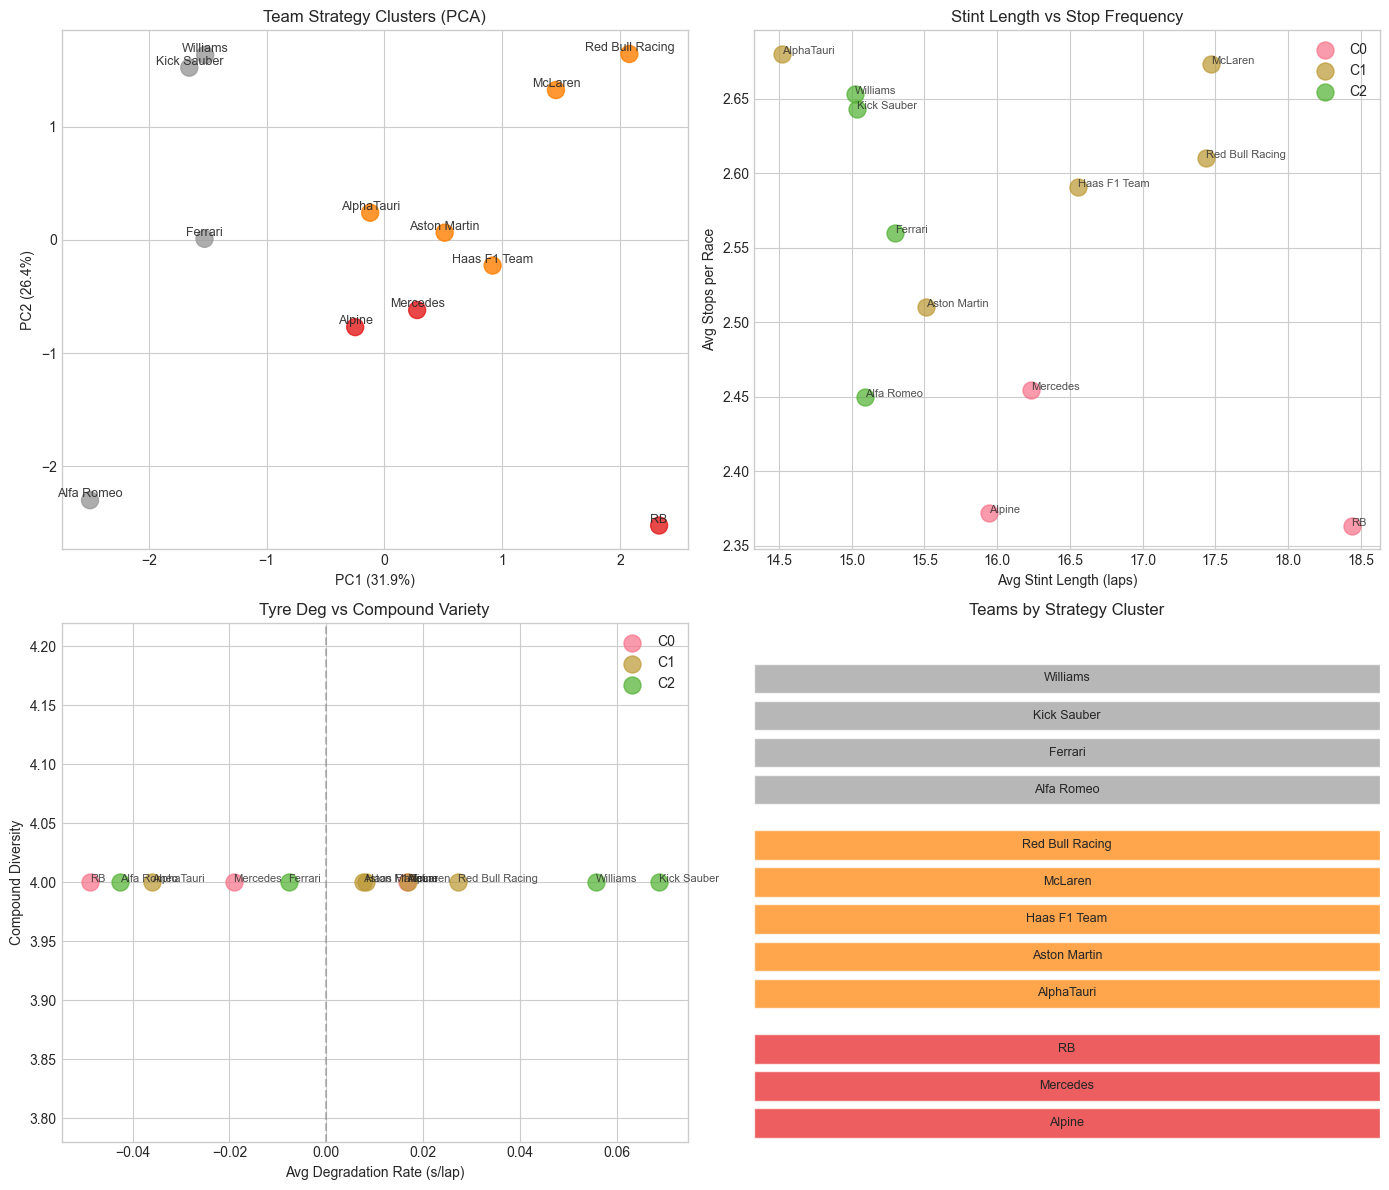


TEAM STRATEGY SUMMARY


,team,cluster_team,avg_stint_length,avg_stops_per_race,avg_deg_rate,compound_diversity,n_races
2,Alpine,0,15.94,2.37,0.02,4,43
8,Mercedes,0,16.24,2.45,-0.02,4,55
9,RB,0,18.44,2.36,-0.05,4,11
1,AlphaTauri,1,14.52,2.68,-0.04,4,25
7,McLaren,1,17.47,2.67,0.02,4,49
10,Red Bull Racing,1,17.44,2.61,0.03,4,59
3,Aston Martin,1,15.51,2.51,0.01,4,49
5,Haas F1 Team,1,16.55,2.59,0.01,4,44
6,Kick Sauber,2,15.04,2.64,0.07,4,14
4,Ferrari,2,15.30,2.56,-0.01,4,50


In [86]:
# Cell 41: Visualize team strategy clusters

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. PCA visualization
pca_teams = PCA(n_components=2)
coords_teams = pca_teams.fit_transform(X_teams_scaled)
df_teams['pca1'] = coords_teams[:, 0]
df_teams['pca2'] = coords_teams[:, 1]

ax = axes[0, 0]
colors_teams = plt.cm.Set1(labels_teams / max(labels_teams.max(), 1))
ax.scatter(coords_teams[:, 0], coords_teams[:, 1], c=colors_teams, s=150, alpha=0.8)
for i, row in df_teams.iterrows():
    ax.annotate(row['team'], (row['pca1'], row['pca2']), fontsize=9, alpha=0.9,
               ha='center', va='bottom')
ax.set_xlabel(f'PC1 ({pca_teams.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_teams.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Team Strategy Clusters (PCA)')

# 2. Stint length vs Stops per race
ax = axes[0, 1]
for cl in range(best_k_teams):
    mask = df_teams['cluster_team'] == cl
    ax.scatter(
        df_teams.loc[mask, 'avg_stint_length'],
        df_teams.loc[mask, 'avg_stops_per_race'],
        label=f'C{cl}', s=150, alpha=0.7
    )
    for _, row in df_teams[mask].iterrows():
        ax.annotate(row['team'], (row['avg_stint_length'], row['avg_stops_per_race']),
                   fontsize=8, alpha=0.8)
ax.set_xlabel('Avg Stint Length (laps)')
ax.set_ylabel('Avg Stops per Race')
ax.set_title('Stint Length vs Stop Frequency')
ax.legend()

# 3. Deg rate vs Compound diversity
ax = axes[1, 0]
for cl in range(best_k_teams):
    mask = df_teams['cluster_team'] == cl
    ax.scatter(
        df_teams.loc[mask, 'avg_deg_rate'],
        df_teams.loc[mask, 'compound_diversity'],
        label=f'C{cl}', s=150, alpha=0.7
    )
    for _, row in df_teams[mask].iterrows():
        ax.annotate(row['team'], (row['avg_deg_rate'], row['compound_diversity']),
                   fontsize=8, alpha=0.8)
ax.set_xlabel('Avg Degradation Rate (s/lap)')
ax.set_ylabel('Compound Diversity')
ax.set_title('Tyre Deg vs Compound Variety')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.legend()

# 4. Bar chart: Teams by cluster
ax = axes[1, 1]
team_cluster_counts = df_teams.groupby('cluster_team')['team'].apply(list).to_dict()
cluster_names = []
for cl in range(best_k_teams):
    teams = team_cluster_counts.get(cl, [])
    profile_row = profile_teams[cl]
    interpretation = interpret_team_cluster(profile_row)
    cluster_names.append(f"C{cl}: {interpretation[:30]}...")

y_pos = 0
for cl in range(best_k_teams):
    teams = team_cluster_counts.get(cl, [])
    for team in teams:
        ax.barh(y_pos, 1, color=plt.cm.Set1(cl / max(best_k_teams - 1, 1)), alpha=0.7)
        ax.text(0.5, y_pos, team, ha='center', va='center', fontsize=9)
        y_pos += 1
    y_pos += 0.5  # Gap between clusters

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, y_pos)
ax.axis('off')
ax.set_title('Teams by Strategy Cluster')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 70)
print("TEAM STRATEGY SUMMARY")
print("=" * 70)
summary_cols = ['team', 'cluster_team', 'avg_stint_length', 'avg_stops_per_race', 
                'avg_deg_rate', 'compound_diversity', 'n_races']
display(df_teams[summary_cols].sort_values('cluster_team').round(2))

## Part 7: Compound-Specific Clustering

**Objective**: Understand how different tyre compounds (Soft/Medium/Hard) behave across various conditions

**Features**:
- `deg_rate_per_lap`: Degradation rate for each compound
- `avg_stint_length`: Typical stint length per compound
- `circuit_count`: How often compound is used
- `deg_variability`: How consistent the compound behaves

In [87]:
# Cell 42: Extract compound-specific features
print("=" * 70)
print("PART 7: COMPOUND-SPECIFIC CLUSTERING")
print("=" * 70)

# Aggregate features by compound and circuit
compound_circuit = analysis_df.groupby(['compound', 'gp_name']).agg({
    'deg_rate_per_lap': ['mean', 'std', 'count'],
    'num_laps': ['mean', 'std', 'max'],
}).reset_index()
compound_circuit.columns = ['compound', 'gp_name', 
                             'deg_mean', 'deg_std', 'stint_count',
                             'stint_len_mean', 'stint_len_std', 'stint_len_max']

# Aggregate to compound level across all circuits
compound_features = analysis_df.groupby('compound').agg({
    'deg_rate_per_lap': ['mean', 'std', 'min', 'max'],
    'num_laps': ['mean', 'std', 'min', 'max'],
    'stint': 'count',
}).reset_index()
compound_features.columns = ['compound',
                              'deg_mean', 'deg_std', 'deg_min', 'deg_max',
                              'stint_len_mean', 'stint_len_std', 'stint_len_min', 'stint_len_max',
                              'total_stints']

print(f"Compounds in data: {compound_features['compound'].tolist()}")
print(f"Total compound-circuit combinations: {len(compound_circuit)}")

# For clustering, we'll use compound-circuit combinations
# This gives us more data points and captures circuit-specific behavior
df_compound = compound_circuit.copy()
df_compound = df_compound[df_compound['stint_count'] >= 3]  # Min 3 stints per combo
df_compound['deg_std'] = df_compound['deg_std'].fillna(0)
df_compound['stint_len_std'] = df_compound['stint_len_std'].fillna(0)

print(f"Compound-circuit combos with >= 3 stints: {len(df_compound)}")
display(compound_features)

PART 7: COMPOUND-SPECIFIC CLUSTERING
Compounds in data: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT']
Total compound-circuit combinations: 69
Compound-circuit combos with >= 3 stints: 62


,compound,deg_mean,deg_std,deg_min,deg_max,stint_len_mean,stint_len_std,stint_len_min,stint_len_max,total_stints
0,HARD,0.009631,0.218848,-0.496133,0.486428,17.779018,8.346136,5,44,448
1,INTERMEDIATE,-0.070888,0.245957,-0.471431,0.484829,16.030303,5.199068,6,25,33
2,MEDIUM,0.016606,0.223927,-0.491304,0.499015,14.942771,7.560813,5,49,332
3,SOFT,0.005846,0.242896,-0.499207,0.493965,13.362832,5.184217,5,30,113


Using 5 features: ['deg_mean', 'deg_std', 'stint_len_mean', 'stint_len_std', 'stint_count']
Compound-circuit samples: 62

Finding optimal K (max=8)...

Optimal K (by BIC): 3
Cluster sizes: [21, 32, 9]


,k,bic,aic,silhouette,sizes
0,2,890.088838,802.876328,0.196651,"[29, 33]"
1,3,878.933991,747.051659,0.186497,"[21, 32, 9]"
2,4,937.778006,761.225853,0.202360,"[24, 14, 14, 10]"
3,5,921.627220,700.405244,0.205876,"[15, 11, 8, 2, 26]"
4,6,926.008838,660.117040,0.172164,"[5, 9, 11, 16, 16, 5]"
5,7,894.166932,583.605312,0.174296,"[6, 18, 6, 13, 14, 1, 4]"
6,8,988.715613,633.484170,0.252673,"[6, 14, 10, 1, 2, 11, 6, 12]"


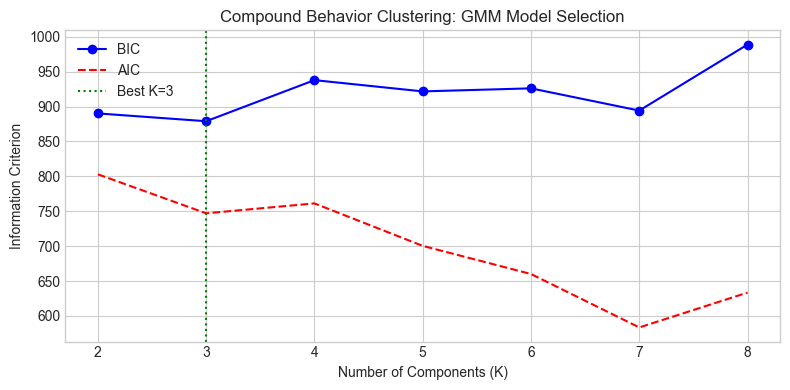

In [90]:
# Cell 43: GMM clustering on compound behavior
compound_feature_cols = ['deg_mean', 'deg_std', 'stint_len_mean', 'stint_len_std', 'stint_count']

X_compound = df_compound[compound_feature_cols].values
scaler_compound = StandardScaler()
X_compound_scaled = scaler_compound.fit_transform(X_compound)

print(f"Using {len(compound_feature_cols)} features: {compound_feature_cols}")
print(f"Compound-circuit samples: {len(df_compound)}")

# Find optimal K
k_max_compound = min(8, len(df_compound) // 5)
print(f"\nFinding optimal K (max={k_max_compound})...")

best_k_compound, gmm_compound, results_gmm_compound = find_best_gmm(X_compound_scaled, k_range=range(2, k_max_compound + 1))
labels_compound = gmm_compound.predict(X_compound_scaled)
df_compound['cluster_compound'] = labels_compound

print(f"\nOptimal K (by BIC): {best_k_compound}")
print(f"Cluster sizes: {[int((labels_compound == i).sum()) for i in range(best_k_compound)]}")

# Visualize
display(results_gmm_compound)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_gmm_compound['k'], results_gmm_compound['bic'], 'bo-', label='BIC')
ax.plot(results_gmm_compound['k'], results_gmm_compound['aic'], 'r--', label='AIC')
ax.axvline(best_k_compound, color='g', linestyle=':', label=f'Best K={best_k_compound}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Compound Behavior Clustering: GMM Model Selection')
ax.legend()
plt.tight_layout()
plt.show()

COMPOUND BEHAVIOR CLUSTER PROFILES (z-scored)


,deg_mean,deg_std,stint_len_mean,stint_len_std,stint_count
cluster_compound,,,,,
0,0.65,-1.12,-1.15,-1.12,-0.33
1,0.50,0.32,0.60,0.80,1.12
2,-1.15,0.80,0.56,0.33,-0.80


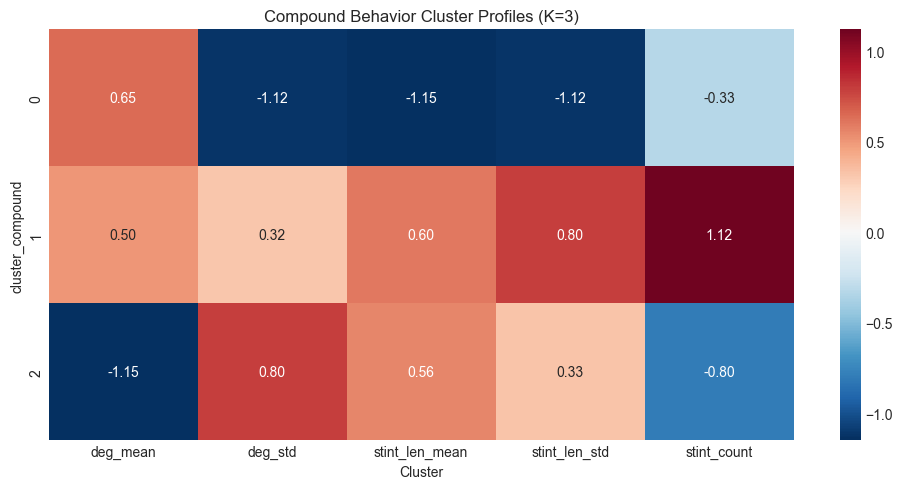


COMPOUND DISTRIBUTION BY CLUSTER


compound,HARD,INTERMEDIATE,MEDIUM,SOFT
cluster_compound,,,,
0,5,4,9,3
1,18,0,10,4
2,0,1,6,2



COMPOUND BEHAVIOR ARCHETYPES

Cluster 0: Moderate/stable | Medium stints
  Primary compounds: ['MEDIUM', 'HARD', 'INTERMEDIATE']
  Circuits: 16, Avg deg: 0.021 s/lap, Avg stint: 13.0 laps

Cluster 1: Moderate/stable | Medium stints
  Primary compounds: ['HARD', 'MEDIUM', 'SOFT']
  Circuits: 20, Avg deg: 0.006 s/lap, Avg stint: 17.7 laps

Cluster 2: Negative deg (improving) | Medium stints
  Primary compounds: ['MEDIUM', 'SOFT', 'INTERMEDIATE']
  Circuits: 9, Avg deg: -0.152 s/lap, Avg stint: 17.6 laps


In [91]:
# Cell 44: Profile compound behavior clusters
profile_compound = profile_clusters(df_compound, compound_feature_cols, 'cluster_compound')

print("=" * 70)
print("COMPOUND BEHAVIOR CLUSTER PROFILES (z-scored)")
print("=" * 70)
display(profile_compound.T.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(profile_compound.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title(f'Compound Behavior Cluster Profiles (K={best_k_compound})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Show compound distribution by cluster
print("\n" + "=" * 70)
print("COMPOUND DISTRIBUTION BY CLUSTER")
print("=" * 70)
compound_dist = df_compound.groupby(['cluster_compound', 'compound']).size().unstack(fill_value=0)
display(compound_dist)

# Interpret clusters
print("\n" + "=" * 70)
print("COMPOUND BEHAVIOR ARCHETYPES")
print("=" * 70)
for cl in range(best_k_compound):
    cluster_data = df_compound[df_compound['cluster_compound'] == cl]
    compounds = cluster_data['compound'].value_counts().head(3).index.tolist()
    circuits = cluster_data['gp_name'].nunique()
    avg_deg = cluster_data['deg_mean'].mean()
    avg_stint = cluster_data['stint_len_mean'].mean()
    
    if avg_deg > 0.05:
        deg_type = "High degradation"
    elif avg_deg < -0.02:
        deg_type = "Negative deg (improving)"
    else:
        deg_type = "Moderate/stable"
    
    if avg_stint > 18:
        stint_type = "Long stints"
    elif avg_stint < 12:
        stint_type = "Short stints"
    else:
        stint_type = "Medium stints"
    
    print(f"\nCluster {cl}: {deg_type} | {stint_type}")
    print(f"  Primary compounds: {compounds}")
    print(f"  Circuits: {circuits}, Avg deg: {avg_deg:.3f} s/lap, Avg stint: {avg_stint:.1f} laps")

## Part 8: Pit Stop Timing Clustering

**Objective**: Identify strategic pit timing patterns - early stoppers vs late stoppers

**Features**:
- `first_lap`: When the stint starts (first stop timing proxy)
- `stint_number`: Which stint in the race
- `num_laps`: How long the stint lasts
- `relative_stop_position`: Early/mid/late in race

In [92]:
# Cell 45: Extract pit stop timing features
print("=" * 70)
print("PART 8: PIT STOP TIMING CLUSTERING")
print("=" * 70)

# We'll cluster stints based on when they occur and their characteristics
# Exclude stint 1 (always starts lap 1) - focus on pit stop choices
pit_stints = analysis_df[analysis_df['stint'] > 1].copy()

# Calculate race context (approximate race length ~55-70 laps typically)
pit_stints['stop_lap'] = pit_stints['first_lap']  # First lap of this stint = pit stop lap
pit_stints['relative_stop_lap'] = pit_stints['stop_lap'] / 60  # Normalized to ~60 lap race

# Categorize stop timing
def classify_stop_timing(lap):
    if lap <= 15:
        return 'very_early'
    elif lap <= 25:
        return 'early'
    elif lap <= 40:
        return 'mid'
    elif lap <= 50:
        return 'late'
    else:
        return 'very_late'

pit_stints['stop_timing_cat'] = pit_stints['stop_lap'].apply(classify_stop_timing)

# Features for clustering
pit_features = pit_stints.groupby(['year', 'gp_name', 'driver']).agg({
    'stop_lap': ['mean', 'std', 'min', 'max'],  # Pit stop laps
    'stint': 'max',  # Number of stints (proxy for stops)
    'num_laps': 'mean',  # Avg stint length
    'deg_rate_per_lap': 'mean',
}).reset_index()
pit_features.columns = ['year', 'gp_name', 'driver',
                         'avg_stop_lap', 'stop_lap_std', 'first_stop', 'last_stop',
                         'n_stints', 'avg_stint_len', 'avg_deg']

# Calculate stop spread
pit_features['stop_lap_std'] = pit_features['stop_lap_std'].fillna(0)
pit_features['stop_spread'] = pit_features['last_stop'] - pit_features['first_stop']

print(f"Race-driver pit patterns: {len(pit_features)}")
print(f"Stop timing distribution:")
print(pit_stints['stop_timing_cat'].value_counts())

display(pit_features.head(10))

PART 8: PIT STOP TIMING CLUSTERING
Race-driver pit patterns: 584
Stop timing distribution:
stop_timing_cat
mid           309
early         195
late          132
very_early     60
very_late      57
Name: count, dtype: int64


,year,gp_name,driver,avg_stop_lap,stop_lap_std,first_stop,last_stop,n_stints,avg_stint_len,avg_deg,stop_spread
0,2022,Abu Dhabi Grand Prix,GAS,39.0,0.000000,39,39,2.0,19.0,-0.295704,0
1,2022,Abu Dhabi Grand Prix,HAM,23.0,0.000000,23,23,2.0,31.0,0.013971,0
2,2022,Abu Dhabi Grand Prix,LAT,22.5,7.778175,17,28,2.0,9.5,-0.046278,11
3,2022,Abu Dhabi Grand Prix,LEC,33.0,0.000000,33,33,2.0,25.0,-0.025427,0
4,2022,Abu Dhabi Grand Prix,MAG,30.0,0.000000,30,30,2.0,27.0,-0.073279,0
5,2022,Abu Dhabi Grand Prix,MSC,27.5,16.263456,16,39,3.0,7.0,0.043810,23
6,2022,Abu Dhabi Grand Prix,NOR,35.0,12.727922,26,44,3.0,15.0,0.124250,18
7,2022,Abu Dhabi Grand Prix,OCO,34.0,12.727922,25,43,3.0,14.0,0.122791,18
8,2022,Abu Dhabi Grand Prix,RIC,35.0,0.000000,35,35,2.0,23.0,0.063388,0
9,2022,Abu Dhabi Grand Prix,SAI,41.0,0.000000,41,41,3.0,5.0,-0.132371,0


Using 5 features: ['first_stop', 'avg_stint_len', 'n_stints', 'stop_spread', 'avg_deg']
Race-driver samples: 584

Finding optimal K (max=10)...

Optimal K (by BIC): 8
Cluster sizes: [12, 4, 29, 117, 2, 274, 31, 115]


,k,bic,aic,silhouette,sizes
0,2,2317.156165,2137.990225,0.261920,"[426, 158]"
1,3,-1132.463000,-1403.396861,0.253575,"[274, 158, 152]"
2,4,-2516.766824,-2879.468605,0.212614,"[274, 158, 117, 35]"
3,5,-2513.159233,-2967.628935,0.210389,"[3, 157, 117, 33, 274]"
4,6,-2460.815207,-3007.052830,0.108972,"[23, 117, 13, 12, 145, 274]"
5,7,-3949.420752,-4587.426295,0.127288,"[274, 115, 117, 13, 35, 28, 2]"
6,8,-4233.241873,-4963.015337,0.121970,"[12, 4, 29, 117, 2, 274, 31, 115]"
7,9,-4118.059867,-4939.601252,0.120271,"[28, 274, 13, 18, 29, 5, 99, 115, 3]"
8,10,-4107.530282,-5020.839587,0.145616,"[100, 164, 4, 110, 13, 28, 16, 29, 117, 3]"


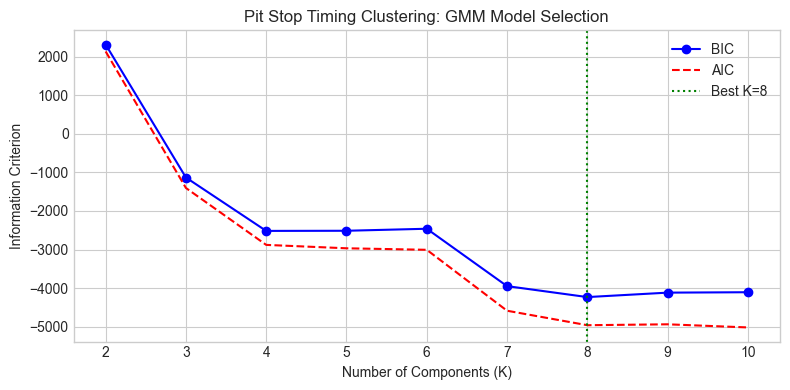

In [93]:
# Cell 46: GMM clustering on pit timing
pit_feature_cols = ['first_stop', 'avg_stint_len', 'n_stints', 'stop_spread', 'avg_deg']

df_pit = pit_features.dropna(subset=pit_feature_cols).copy()
X_pit = df_pit[pit_feature_cols].values
scaler_pit = StandardScaler()
X_pit_scaled = scaler_pit.fit_transform(X_pit)

print(f"Using {len(pit_feature_cols)} features: {pit_feature_cols}")
print(f"Race-driver samples: {len(df_pit)}")

# Find optimal K
k_max_pit = min(10, len(df_pit) // 10)
print(f"\nFinding optimal K (max={k_max_pit})...")

best_k_pit, gmm_pit, results_gmm_pit = find_best_gmm(X_pit_scaled, k_range=range(2, k_max_pit + 1))
labels_pit = gmm_pit.predict(X_pit_scaled)
df_pit['cluster_pit'] = labels_pit

print(f"\nOptimal K (by BIC): {best_k_pit}")
print(f"Cluster sizes: {[int((labels_pit == i).sum()) for i in range(best_k_pit)]}")

display(results_gmm_pit)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_gmm_pit['k'], results_gmm_pit['bic'], 'bo-', label='BIC')
ax.plot(results_gmm_pit['k'], results_gmm_pit['aic'], 'r--', label='AIC')
ax.axvline(best_k_pit, color='g', linestyle=':', label=f'Best K={best_k_pit}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Pit Stop Timing Clustering: GMM Model Selection')
ax.legend()
plt.tight_layout()
plt.show()

PIT TIMING CLUSTER PROFILES (z-scored)


,first_stop,avg_stint_len,n_stints,stop_spread,avg_deg
cluster_pit,,,,,
0,-1.09,-1.62,-1.29,0.52,-0.72
1,0.97,0.33,0.35,-0.40,1.52
2,-0.86,0.07,0.81,1.74,0.60
3,0.14,-0.09,-0.35,-0.75,-0.22
4,1.75,-0.17,1.52,-0.75,-1.84
5,-0.45,1.96,-1.29,-0.75,-0.06
6,0.37,0.13,0.59,-0.75,0.09
7,-0.85,-0.61,-0.35,1.14,0.62


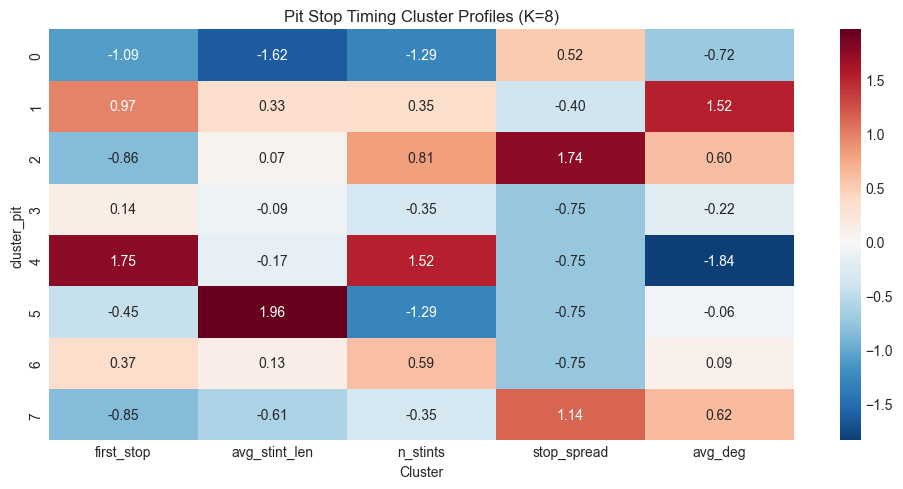

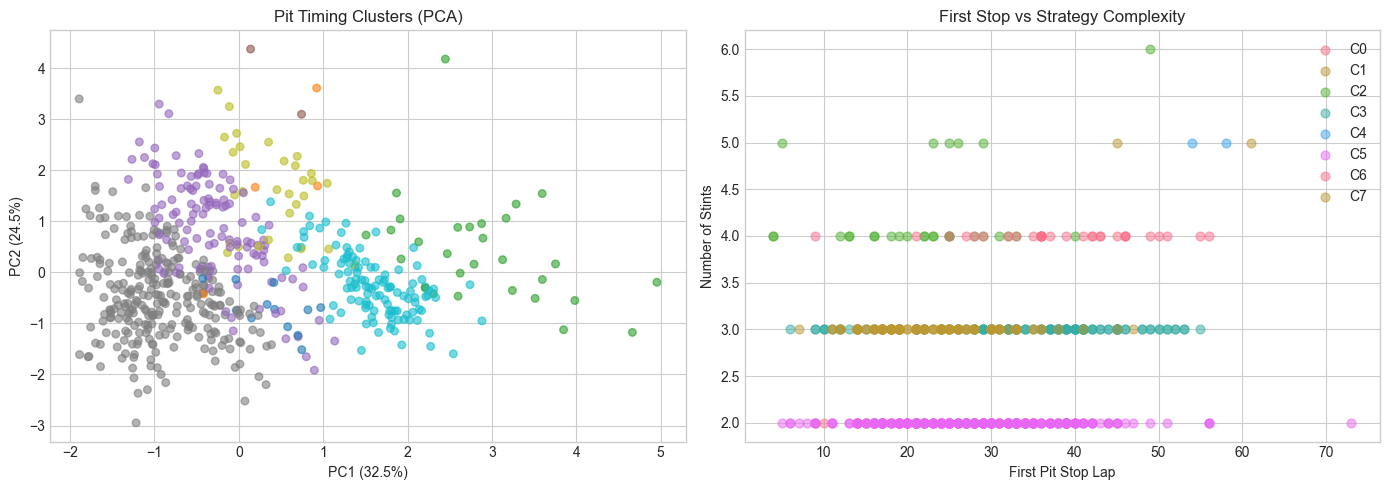


PIT TIMING STRATEGY ARCHETYPES

Cluster 0: Early stopper | 1-stop
  Avg first stop: lap 19.4, Avg stints: 2.0
  Avg degradation: -0.071 s/lap, Count: 12

Cluster 1: Late stopper | Multi-stop
  Avg first stop: lap 46.0, Avg stints: 3.8
  Avg degradation: 0.153 s/lap, Count: 4

Cluster 2: Standard timing | Multi-stop
  Avg first stop: lap 22.4, Avg stints: 4.2
  Avg degradation: 0.061 s/lap, Count: 29

Cluster 3: Late stopper | 2-stop
  Avg first stop: lap 35.3, Avg stints: 3.0
  Avg degradation: -0.021 s/lap, Count: 117

Cluster 4: Late stopper | Multi-stop
  Avg first stop: lap 56.0, Avg stints: 5.0
  Avg degradation: -0.183 s/lap, Count: 2

Cluster 5: Standard timing | 1-stop
  Avg first stop: lap 27.7, Avg stints: 2.0
  Avg degradation: -0.005 s/lap, Count: 274

Cluster 6: Late stopper | Multi-stop
  Avg first stop: lap 38.3, Avg stints: 4.0
  Avg degradation: 0.010 s/lap, Count: 31

Cluster 7: Standard timing | 2-stop
  Avg first stop: lap 22.5, Avg stints: 3.0
  Avg degradation: 0

In [94]:
# Cell 47: Profile pit timing clusters and visualize
profile_pit = profile_clusters(df_pit, pit_feature_cols, 'cluster_pit')

print("=" * 70)
print("PIT TIMING CLUSTER PROFILES (z-scored)")
print("=" * 70)
display(profile_pit.T.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(profile_pit.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title(f'Pit Stop Timing Cluster Profiles (K={best_k_pit})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# PCA visualization
pca_pit = PCA(n_components=2)
coords_pit = pca_pit.fit_transform(X_pit_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter by cluster
colors_pit = plt.cm.tab10(labels_pit / max(labels_pit.max(), 1))
axes[0].scatter(coords_pit[:, 0], coords_pit[:, 1], c=colors_pit, alpha=0.6, s=30)
axes[0].set_xlabel(f'PC1 ({pca_pit.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_pit.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Pit Timing Clusters (PCA)')

# First stop vs stints
for cl in range(best_k_pit):
    mask = labels_pit == cl
    axes[1].scatter(df_pit.loc[mask, 'first_stop'], df_pit.loc[mask, 'n_stints'],
                    alpha=0.5, s=40, label=f'C{cl}')
axes[1].set_xlabel('First Pit Stop Lap')
axes[1].set_ylabel('Number of Stints')
axes[1].set_title('First Stop vs Strategy Complexity')
axes[1].legend()
plt.tight_layout()
plt.show()

# Interpret clusters
print("\n" + "=" * 70)
print("PIT TIMING STRATEGY ARCHETYPES")
print("=" * 70)
for cl in range(best_k_pit):
    cluster_data = df_pit[df_pit['cluster_pit'] == cl]
    avg_first = cluster_data['first_stop'].mean()
    avg_stints = cluster_data['n_stints'].mean()
    avg_deg = cluster_data['avg_deg'].mean()
    
    if avg_first <= 15:
        timing = "Very early stopper"
    elif avg_first <= 22:
        timing = "Early stopper"
    elif avg_first <= 30:
        timing = "Standard timing"
    else:
        timing = "Late stopper"
    
    if avg_stints >= 3.5:
        complexity = "Multi-stop"
    elif avg_stints >= 2.5:
        complexity = "2-stop"
    else:
        complexity = "1-stop"
    
    print(f"\nCluster {cl}: {timing} | {complexity}")
    print(f"  Avg first stop: lap {avg_first:.1f}, Avg stints: {avg_stints:.1f}")
    print(f"  Avg degradation: {avg_deg:.3f} s/lap, Count: {len(cluster_data)}")

## Part 9: Weather/Condition Impact Clustering

**Objective**: Understand how weather conditions affect tyre behavior

**Features**:
- Temperature effects on degradation
- Humidity correlation with grip
- Track evolution impact

In [97]:
# Cell 48: Extract weather-condition features
print("=" * 70)
print("PART 9: WEATHER/CONDITION IMPACT CLUSTERING")
print("=" * 70)

# Check available weather columns
print("Available columns in analysis_df:")
weather_related = [c for c in analysis_df.columns if any(x in c.lower() for x in ['temp', 'air', 'track', 'humid', 'weather', 'rain'])]
print(f"Weather-related columns: {weather_related}")

# Aggregate race conditions by race event
race_conditions = analysis_df.groupby(['year', 'gp_name']).agg({
    'deg_rate_per_lap': ['mean', 'std', 'min', 'max'],
    'num_laps': ['mean', 'std'],
    'stint': 'max',  # Max stints = strategy complexity
    'compound': lambda x: x.nunique(),  # Compound diversity
}).reset_index()
race_conditions.columns = ['year', 'gp_name',
                            'deg_mean', 'deg_std', 'deg_min', 'deg_max',
                            'stint_len_mean', 'stint_len_std',
                            'max_stints', 'compound_diversity']

# Fill NaN in numeric columns only
numeric_cols = race_conditions.select_dtypes(include=[np.number]).columns
race_conditions[numeric_cols] = race_conditions[numeric_cols].fillna(race_conditions[numeric_cols].median())

# Calculate deg volatility (high std relative to mean = unpredictable conditions)
race_conditions['deg_volatility'] = race_conditions['deg_std'] / (abs(race_conditions['deg_mean']) + 0.01)
race_conditions['deg_range'] = race_conditions['deg_max'] - race_conditions['deg_min']

# Merge with circuit weather averages if available
if 'weather_by_circuit' in dir() and weather_by_circuit is not None:
    # Check which columns exist
    available_weather_cols = [c for c in ['gp_name', 'avg_air_temp', 'avg_track_temp', 'avg_humidity'] 
                              if c in weather_by_circuit.columns]
    if len(available_weather_cols) > 1:
        race_conditions = race_conditions.merge(
            weather_by_circuit[available_weather_cols].drop_duplicates(),
            on='gp_name', how='left'
        )
        print(f"Merged circuit weather columns: {available_weather_cols}")
    else:
        print("weather_by_circuit exists but missing required columns")
else:
    print("No weather_by_circuit data available - using degradation features only")

print(f"Race condition records: {len(race_conditions)}")
display(race_conditions.head())

PART 9: WEATHER/CONDITION IMPACT CLUSTERING
Available columns in analysis_df:
Weather-related columns: []
weather_by_circuit exists but missing required columns
Race condition records: 68


,year,gp_name,deg_mean,deg_std,deg_min,deg_max,stint_len_mean,stint_len_std,max_stints,compound_diversity,deg_volatility,deg_range
0,2022,Abu Dhabi Grand Prix,0.013641,0.148219,-0.304423,0.217633,16.421053,8.552555,3.0,2,6.269686,0.522056
1,2022,Australian Grand Prix,-0.086876,0.145172,-0.332074,0.097245,17.777778,9.162120,4.0,2,1.498532,0.429319
2,2022,Austrian Grand Prix,-0.030229,0.246297,-0.458590,0.374641,13.000000,3.409545,4.0,2,6.122432,0.833230
3,2022,Azerbaijan Grand Prix,-0.007128,0.258859,-0.476298,0.435646,16.538462,5.425486,3.0,2,15.113509,0.911944
4,2022,Bahrain Grand Prix,0.152723,0.169540,-0.385818,0.412838,11.400000,3.992097,3.0,3,1.041891,0.798656


Using 7 features: ['deg_mean', 'deg_std', 'deg_volatility', 'deg_range', 'stint_len_mean', 'max_stints', 'compound_diversity']
Race condition samples: 68

Finding optimal K (max=8)...

Optimal K (by BIC): 8
Cluster sizes: [7, 4, 5, 13, 3, 26, 5, 5]


,k,bic,aic,silhouette,sizes
0,2,1390.334415,1232.749368,0.188571,"[39, 29]"
1,3,1440.875592,1203.388268,0.136903,"[20, 30, 18]"
2,4,857.928474,540.538872,0.133422,"[39, 16, 6, 7]"
3,5,650.620461,253.328582,0.150657,"[2, 15, 6, 38, 7]"
4,6,725.672505,248.478348,0.165595,"[11, 8, 4, 7, 23, 15]"
5,7,736.354279,179.257845,0.155314,"[2, 8, 33, 6, 7, 4, 8]"
6,8,526.531881,-110.466830,0.138232,"[7, 4, 5, 13, 3, 26, 5, 5]"


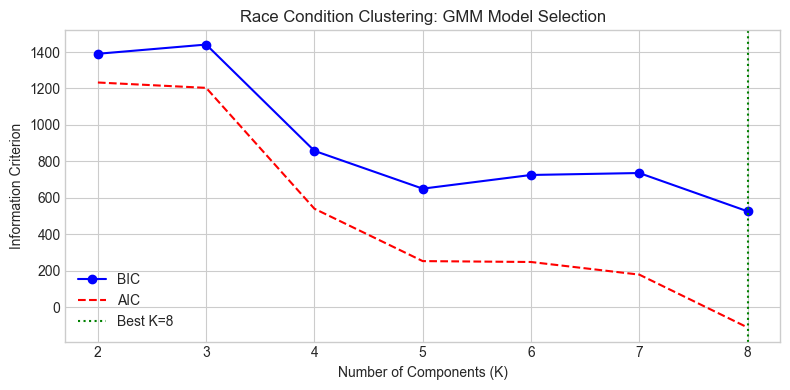

In [98]:
# Cell 49: GMM clustering on race conditions
# Select features based on what's available
condition_feature_cols = ['deg_mean', 'deg_std', 'deg_volatility', 'deg_range',
                           'stint_len_mean', 'max_stints', 'compound_diversity']

# Add weather if available
if 'avg_air_temp' in race_conditions.columns:
    condition_feature_cols.extend(['avg_air_temp', 'avg_track_temp', 'avg_humidity'])

df_conditions = race_conditions.dropna(subset=condition_feature_cols).copy()
X_conditions = df_conditions[condition_feature_cols].values
scaler_conditions = StandardScaler()
X_conditions_scaled = scaler_conditions.fit_transform(X_conditions)

print(f"Using {len(condition_feature_cols)} features: {condition_feature_cols}")
print(f"Race condition samples: {len(df_conditions)}")

# Find optimal K
k_max_cond = min(8, len(df_conditions) // 5)
print(f"\nFinding optimal K (max={k_max_cond})...")

best_k_cond, gmm_cond, results_gmm_cond = find_best_gmm(X_conditions_scaled, k_range=range(2, k_max_cond + 1))
labels_cond = gmm_cond.predict(X_conditions_scaled)
df_conditions['cluster_condition'] = labels_cond

print(f"\nOptimal K (by BIC): {best_k_cond}")
print(f"Cluster sizes: {[int((labels_cond == i).sum()) for i in range(best_k_cond)]}")

display(results_gmm_cond)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_gmm_cond['k'], results_gmm_cond['bic'], 'bo-', label='BIC')
ax.plot(results_gmm_cond['k'], results_gmm_cond['aic'], 'r--', label='AIC')
ax.axvline(best_k_cond, color='g', linestyle=':', label=f'Best K={best_k_cond}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Race Condition Clustering: GMM Model Selection')
ax.legend()
plt.tight_layout()
plt.show()

RACE CONDITION CLUSTER PROFILES (z-scored)


,deg_mean,deg_std,deg_volatility,deg_range,stint_len_mean,max_stints,compound_diversity
cluster_condition,,,,,,,
0,0.31,0.71,2.28,0.70,0.18,-0.34,0.01
1,-0.69,0.71,-0.40,0.35,2.10,-1.07,1.02
2,1.43,1.29,-0.45,0.88,-0.74,0.43,-0.56
3,0.86,0.24,-0.15,0.64,-0.48,0.48,1.43
4,-0.86,-0.72,-0.68,-2.11,-0.99,-1.47,-1.88
5,0.10,-0.53,-0.19,0.10,0.52,0.48,-0.23
6,-1.63,-1.86,-0.85,-0.83,0.13,-0.20,0.10
7,0.48,0.16,0.44,0.25,-0.71,1.70,0.10


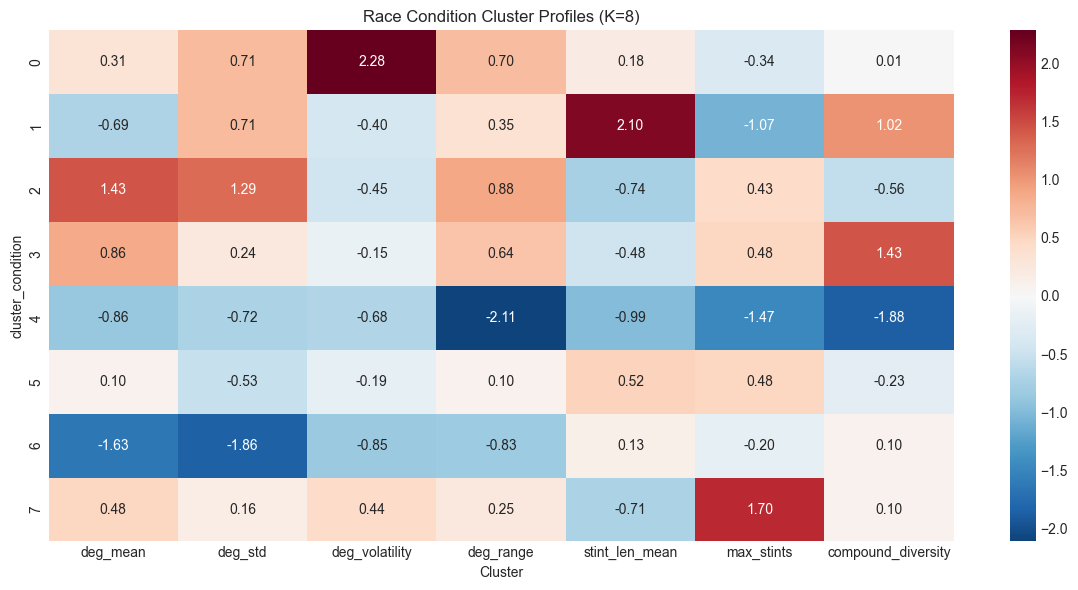


RACE CONDITION ARCHETYPES

Cluster 0: Unpredictable | Moderate deg
  Sample races: ['Azerbaijan Grand Prix', 'Hungarian Grand Prix', 'Australian Grand Prix', 'Emilia Romagna Grand Prix', 'Italian Grand Prix']
  Avg deg: -0.001 s/lap, Volatility: 14.54, Count: 7

Cluster 1: Unpredictable | Grip improving
  Sample races: ['Emilia Romagna Grand Prix', 'Mexico City Grand Prix', 'Monaco Grand Prix', 'Azerbaijan Grand Prix']
  Avg deg: -0.109 s/lap, Volatility: 2.66, Count: 4

Cluster 2: Unpredictable | High deg
  Sample races: ['Japanese Grand Prix', 'Belgian Grand Prix', 'Italian Grand Prix', 'Bahrain Grand Prix']
  Avg deg: 0.120 s/lap, Volatility: 2.44, Count: 5

Cluster 3: Unpredictable | High deg
  Sample races: ['Bahrain Grand Prix', 'Belgian Grand Prix', 'British Grand Prix', 'Hungarian Grand Prix', 'Italian Grand Prix']
  Avg deg: 0.059 s/lap, Volatility: 3.79, Count: 13

Cluster 4: Variable | Grip improving
  Sample races: ['Monaco Grand Prix', 'Singapore Grand Prix']
  Avg deg: -

In [99]:
# Cell 50: Profile condition clusters
profile_cond = profile_clusters(df_conditions, condition_feature_cols, 'cluster_condition')

print("=" * 70)
print("RACE CONDITION CLUSTER PROFILES (z-scored)")
print("=" * 70)
display(profile_cond.T.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(profile_cond.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title(f'Race Condition Cluster Profiles (K={best_k_cond})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Show races in each cluster
print("\n" + "=" * 70)
print("RACE CONDITION ARCHETYPES")
print("=" * 70)
for cl in range(best_k_cond):
    cluster_data = df_conditions[df_conditions['cluster_condition'] == cl]
    races = cluster_data['gp_name'].unique()[:5]
    avg_deg = cluster_data['deg_mean'].mean()
    volatility = cluster_data['deg_volatility'].mean()
    
    if volatility > 2:
        stability = "Unpredictable"
    elif volatility > 1:
        stability = "Variable"
    else:
        stability = "Consistent"
    
    if avg_deg > 0.05:
        deg_level = "High deg"
    elif avg_deg < -0.01:
        deg_level = "Grip improving"
    else:
        deg_level = "Moderate deg"
    
    print(f"\nCluster {cl}: {stability} | {deg_level}")
    print(f"  Sample races: {list(races)}")
    print(f"  Avg deg: {avg_deg:.3f} s/lap, Volatility: {volatility:.2f}, Count: {len(cluster_data)}")

## Part 10: Position-Based Strategy Clustering

**Objective**: How does starting/race position influence strategy choices?

**Features**:
- Position at stint start
- Position changes during stint
- Strategy aggressiveness based on position

In [100]:
# Cell 51: Extract position-based strategy features
print("=" * 70)
print("PART 10: POSITION-BASED STRATEGY CLUSTERING")
print("=" * 70)

# For each race-driver, analyze how position affects strategy
# We'll use stint number and timing as strategy proxies
position_strategy = analysis_df.groupby(['year', 'gp_name', 'driver', 'team']).agg({
    'stint': 'max',  # Total stints (strategy complexity)
    'first_lap': 'min',  # First stint start (should be 1)
    'num_laps': ['mean', 'std', 'sum'],  # Stint characteristics
    'deg_rate_per_lap': 'mean',
    'compound': lambda x: x.nunique(),  # Compound variety
}).reset_index()
position_strategy.columns = ['year', 'gp_name', 'driver', 'team',
                              'n_stints', 'race_start_lap', 'avg_stint_len', 
                              'stint_len_std', 'total_laps', 'avg_deg', 'n_compounds']

# Calculate first stop lap (when stint 2 starts)
first_stops = analysis_df[analysis_df['stint'] == 2].groupby(['year', 'gp_name', 'driver'])['first_lap'].min().reset_index()
first_stops.columns = ['year', 'gp_name', 'driver', 'first_stop_lap']
position_strategy = position_strategy.merge(first_stops, on=['year', 'gp_name', 'driver'], how='left')

# Fill missing first_stop (1-stoppers or DNFs)
position_strategy['first_stop_lap'] = position_strategy['first_stop_lap'].fillna(50)  # Assume late/no stop
position_strategy['stint_len_std'] = position_strategy['stint_len_std'].fillna(0)

# Create position proxy (using team as proxy since we don't have direct grid data in analysis_df)
# Top teams tend to start higher
top_teams = ['Red Bull Racing', 'Ferrari', 'Mercedes', 'McLaren']
mid_teams = ['Aston Martin', 'Alpine', 'AlphaTauri', 'RB']

def team_tier(team):
    if team in top_teams:
        return 1  # Front
    elif team in mid_teams:
        return 2  # Midfield
    else:
        return 3  # Back

position_strategy['team_tier'] = position_strategy['team'].apply(team_tier)

# Strategy aggressiveness: early stop + more stints = aggressive
position_strategy['strategy_aggression'] = (50 - position_strategy['first_stop_lap']) / 10 + position_strategy['n_stints']

print(f"Race-driver strategy records: {len(position_strategy)}")
print(f"\nTeam tier distribution:")
print(position_strategy['team_tier'].value_counts().sort_index())
display(position_strategy.head())

PART 10: POSITION-BASED STRATEGY CLUSTERING
Race-driver strategy records: 648

Team tier distribution:
team_tier
1    312
2    167
3    169
Name: count, dtype: int64


,year,gp_name,driver,team,n_stints,race_start_lap,avg_stint_len,stint_len_std,total_laps,avg_deg,n_compounds,first_stop_lap,team_tier,strategy_aggression
0,2022,Abu Dhabi Grand Prix,GAS,AlphaTauri,2.0,39,19.0,0.000000,19,-0.295704,1,39.0,2,3.1
1,2022,Abu Dhabi Grand Prix,HAM,Mercedes,2.0,23,31.0,0.000000,31,0.013971,1,23.0,1,4.7
2,2022,Abu Dhabi Grand Prix,LAT,Williams,2.0,17,9.5,0.707107,19,-0.046278,1,17.0,3,5.3
3,2022,Abu Dhabi Grand Prix,LEC,Ferrari,2.0,33,25.0,0.000000,25,-0.025427,1,33.0,1,3.7
4,2022,Abu Dhabi Grand Prix,MAG,Haas F1 Team,2.0,30,27.0,0.000000,27,-0.073279,1,30.0,3,4.0


Using 7 features: ['n_stints', 'avg_stint_len', 'first_stop_lap', 'avg_deg', 'n_compounds', 'team_tier', 'strategy_aggression']
Race-driver samples: 648

Finding optimal K (max=8)...

Optimal K (by BIC): 8
Cluster sizes: [64, 4, 150, 38, 116, 70, 167, 39]


,k,bic,aic,silhouette,sizes
0,2,469.589161,151.942922,0.195152,"[408, 240]"
1,3,-5725.407946,-6204.114250,0.200006,"[258, 171, 219]"
2,4,-8312.591768,-8952.358137,0.131276,"[171, 219, 220, 38]"
3,5,-9055.210119,-9856.036554,0.182466,"[64, 38, 171, 155, 220]"
4,6,-10325.713380,-11287.599880,0.146276,"[64, 220, 116, 171, 38, 39]"
5,7,-11022.240177,-12145.186742,0.155415,"[37, 141, 64, 39, 31, 116, 220]"
6,8,-12164.818058,-13448.824688,0.168320,"[64, 4, 150, 38, 116, 70, 167, 39]"


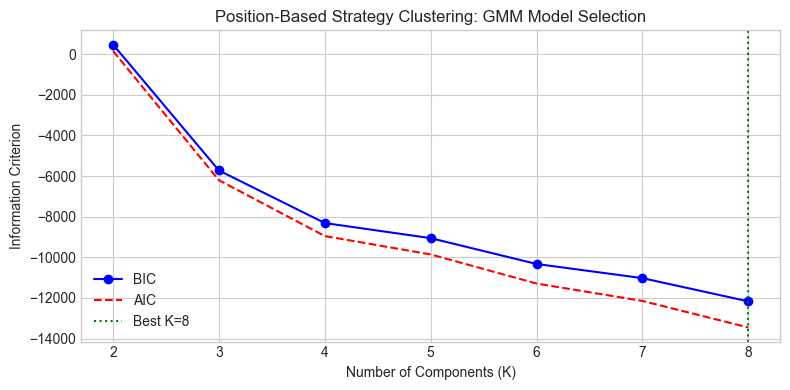

In [101]:
# Cell 52: GMM clustering on position-based strategy
position_feature_cols = ['n_stints', 'avg_stint_len', 'first_stop_lap', 'avg_deg', 
                          'n_compounds', 'team_tier', 'strategy_aggression']

df_position = position_strategy.dropna(subset=position_feature_cols).copy()
X_position = df_position[position_feature_cols].values
scaler_position = StandardScaler()
X_position_scaled = scaler_position.fit_transform(X_position)

print(f"Using {len(position_feature_cols)} features: {position_feature_cols}")
print(f"Race-driver samples: {len(df_position)}")

# Find optimal K
k_max_pos = min(8, len(df_position) // 15)
print(f"\nFinding optimal K (max={k_max_pos})...")

best_k_pos, gmm_pos, results_gmm_pos = find_best_gmm(X_position_scaled, k_range=range(2, k_max_pos + 1))
labels_pos = gmm_pos.predict(X_position_scaled)
df_position['cluster_position'] = labels_pos

print(f"\nOptimal K (by BIC): {best_k_pos}")
print(f"Cluster sizes: {[int((labels_pos == i).sum()) for i in range(best_k_pos)]}")

display(results_gmm_pos)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_gmm_pos['k'], results_gmm_pos['bic'], 'bo-', label='BIC')
ax.plot(results_gmm_pos['k'], results_gmm_pos['aic'], 'r--', label='AIC')
ax.axvline(best_k_pos, color='g', linestyle=':', label=f'Best K={best_k_pos}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Position-Based Strategy Clustering: GMM Model Selection')
ax.legend()
plt.tight_layout()
plt.show()

POSITION-BASED STRATEGY CLUSTER PROFILES (z-scored)


,n_stints,avg_stint_len,first_stop_lap,avg_deg,n_compounds,team_tier,strategy_aggression
cluster_position,,,,,,,
0,-1.71,0.18,1.18,-0.39,-0.50,0.24,-2.02
1,0.62,-0.40,-0.68,0.23,2.18,0.77,0.94
2,-0.67,1.95,-0.50,0.88,-0.50,-0.51,-0.00
3,0.39,-0.34,-1.05,1.18,-0.50,0.33,1.10
4,0.36,-0.15,1.18,-0.21,-0.50,0.53,-0.75
5,-0.67,-1.66,-0.88,-2.11,-0.50,-0.60,0.31
6,0.11,0.14,-0.44,0.37,0.84,-1.97,0.43
7,1.58,0.29,1.18,0.05,-0.50,1.21,-0.01


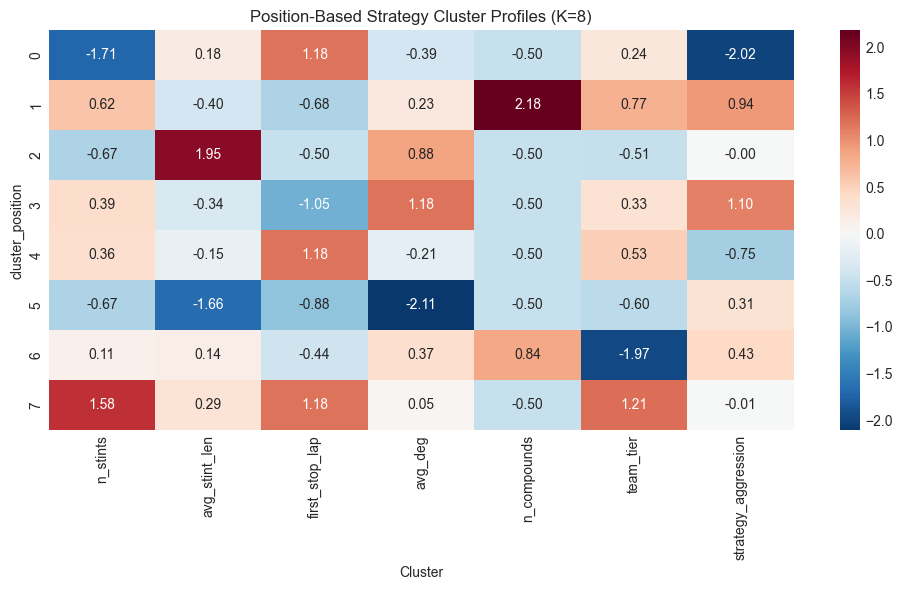


CLUSTER DISTRIBUTION BY TEAM TIER


,"Front (RBR,FER,MER,MCL)",Midfield,Back
cluster_position,,,
0,24,22,18
1,2,0,2
2,70,44,36
3,15,11,12
4,47,27,42
5,33,21,16
6,109,30,28
7,12,12,15



POSITION-BASED STRATEGY ARCHETYPES

Cluster 0: Mixed field | Conservative
  Avg team tier: 1.91, Aggression score: 1.00
  First stop: lap 50.0, Avg stints: 1.0, Count: 64

Cluster 1: Mixed field | Aggressive
  Avg team tier: 2.00, Aggression score: 5.67
  First stop: lap 25.8, Avg stints: 3.2, Count: 4

Cluster 2: Mixed field | Conservative
  Avg team tier: 1.77, Aggression score: 4.19
  First stop: lap 28.1, Avg stints: 2.0, Count: 150

Cluster 3: Mixed field | Aggressive
  Avg team tier: 1.92, Aggression score: 5.94
  First stop: lap 20.9, Avg stints: 3.0, Count: 38

Cluster 4: Mixed field | Conservative
  Avg team tier: 1.96, Aggression score: 3.00
  First stop: lap 50.0, Avg stints: 3.0, Count: 116

Cluster 5: Mixed field | Standard
  Avg team tier: 1.76, Aggression score: 4.69
  First stop: lap 23.1, Avg stints: 2.0, Count: 70

Cluster 6: Mixed field | Standard
  Avg team tier: 1.51, Aggression score: 4.88
  First stop: lap 28.9, Avg stints: 2.8, Count: 167

Cluster 7: Mixed fiel

In [102]:
# Cell 53: Profile position-based strategy clusters
profile_pos = profile_clusters(df_position, position_feature_cols, 'cluster_position')

print("=" * 70)
print("POSITION-BASED STRATEGY CLUSTER PROFILES (z-scored)")
print("=" * 70)
display(profile_pos.T.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(profile_pos.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title(f'Position-Based Strategy Cluster Profiles (K={best_k_pos})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Analyze by team tier
print("\n" + "=" * 70)
print("CLUSTER DISTRIBUTION BY TEAM TIER")
print("=" * 70)
tier_labels = {1: 'Front (RBR,FER,MER,MCL)', 2: 'Midfield', 3: 'Back'}
tier_dist = df_position.groupby(['cluster_position', 'team_tier']).size().unstack(fill_value=0)
tier_dist.columns = [tier_labels.get(c, c) for c in tier_dist.columns]
display(tier_dist)

# Interpret clusters
print("\n" + "=" * 70)
print("POSITION-BASED STRATEGY ARCHETYPES")
print("=" * 70)
for cl in range(best_k_pos):
    cluster_data = df_position[df_position['cluster_position'] == cl]
    avg_tier = cluster_data['team_tier'].mean()
    avg_aggression = cluster_data['strategy_aggression'].mean()
    avg_first_stop = cluster_data['first_stop_lap'].mean()
    avg_stints = cluster_data['n_stints'].mean()
    
    if avg_tier <= 1.5:
        tier_desc = "Front-runners"
    elif avg_tier <= 2.3:
        tier_desc = "Mixed field"
    else:
        tier_desc = "Backmarkers"
    
    if avg_aggression > 5.5:
        aggr_desc = "Aggressive"
    elif avg_aggression > 4.5:
        aggr_desc = "Standard"
    else:
        aggr_desc = "Conservative"
    
    print(f"\nCluster {cl}: {tier_desc} | {aggr_desc}")
    print(f"  Avg team tier: {avg_tier:.2f}, Aggression score: {avg_aggression:.2f}")
    print(f"  First stop: lap {avg_first_stop:.1f}, Avg stints: {avg_stints:.1f}, Count: {len(cluster_data)}")

## Part 11: Season Evolution Clustering

**Objective**: Identify how strategy patterns evolve across a season

**Features**:
- Season progression (early/mid/late)
- Running averages of degradation
- Team development trends

In [104]:
# Cell 54: Extract season evolution features
print("=" * 70)
print("PART 11: SEASON EVOLUTION CLUSTERING")
print("=" * 70)

# Get race order within each season
race_dates = analysis_df.groupby(['year', 'gp_name']).size().reset_index()[['year', 'gp_name']]
race_dates = race_dates.drop_duplicates()

# Sort by year and race name (approximation - ideally would use actual date)
race_dates['race_num'] = race_dates.groupby('year').cumcount() + 1
race_dates['total_races'] = race_dates.groupby('year')['race_num'].transform('max')
race_dates['season_progress'] = race_dates['race_num'] / race_dates['total_races']

# Categorize season phase
def season_phase(progress):
    if progress <= 0.33:
        return 'early'
    elif progress <= 0.67:
        return 'mid'
    else:
        return 'late'

race_dates['season_phase'] = race_dates['season_progress'].apply(season_phase)

# Merge back to analysis data
analysis_with_season = analysis_df.merge(race_dates, on=['year', 'gp_name'], how='left')

# Aggregate by team-year-phase
season_evolution = analysis_with_season.groupby(['year', 'team', 'season_phase']).agg({
    'deg_rate_per_lap': ['mean', 'std'],
    'num_laps': 'mean',
    'stint': 'max',
    'compound': lambda x: x.nunique(),
    'gp_name': 'nunique'
}).reset_index()
season_evolution.columns = ['year', 'team', 'season_phase',
                             'deg_mean', 'deg_std', 'avg_stint_len',
                             'avg_n_stints', 'compound_variety', 'n_races']

# Pivot to get early/mid/late as columns for trend analysis
season_pivot = season_evolution.pivot_table(
    index=['year', 'team'],
    columns='season_phase',
    values=['deg_mean', 'avg_stint_len', 'avg_n_stints'],
    aggfunc='first'
).reset_index()

# Flatten column names
season_pivot.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in season_pivot.columns]

# Calculate season trends (late - early)
if 'deg_mean_late' in season_pivot.columns and 'deg_mean_early' in season_pivot.columns:
    season_pivot['deg_trend'] = season_pivot['deg_mean_late'] - season_pivot['deg_mean_early']
    season_pivot['stint_trend'] = season_pivot['avg_stint_len_late'] - season_pivot['avg_stint_len_early']
else:
    season_pivot['deg_trend'] = 0
    season_pivot['stint_trend'] = 0

# Fill NaN only for numeric columns
numeric_cols = season_pivot.select_dtypes(include=[np.number]).columns
season_pivot[numeric_cols] = season_pivot[numeric_cols].fillna(season_pivot[numeric_cols].median())
print(f"Team-season records: {len(season_pivot)}")
print(f"\nSeason phases:")
print(season_evolution['season_phase'].value_counts())
display(season_pivot.head())

PART 11: SEASON EVOLUTION CLUSTERING
Team-season records: 30

Season phases:
season_phase
late     30
mid      30
early    29
Name: count, dtype: int64


,year,team,avg_n_stints_early,avg_n_stints_late,avg_n_stints_mid,avg_stint_len_early,avg_stint_len_late,avg_stint_len_mid,deg_mean_early,deg_mean_late,deg_mean_mid,deg_trend,stint_trend
0,2022,Alfa Romeo,4.0,3.0,3.0,15.888889,22.000000,14.000000,0.066972,-0.047738,-0.155610,-0.043132,0.333333
1,2022,AlphaTauri,3.0,4.0,4.0,14.285714,12.400000,10.000000,-0.044027,-0.012567,0.040035,0.031460,-1.885714
2,2022,Alpine,4.0,4.0,3.0,12.900000,13.300000,20.125000,-0.000491,-0.043623,0.082162,-0.043132,0.400000
3,2022,Aston Martin,4.0,4.0,3.0,12.692308,14.571429,22.571429,-0.057196,0.058864,-0.032126,0.116060,1.879121
4,2022,Ferrari,4.0,3.0,3.0,13.588235,17.214286,14.076923,0.092141,-0.062416,-0.115156,-0.154557,3.626050


Using 8 features: ['deg_mean_early', 'deg_mean_mid', 'deg_mean_late', 'avg_stint_len_early', 'avg_stint_len_mid', 'avg_stint_len_late', 'deg_trend', 'stint_trend']
Team-season samples: 30

Finding optimal K (max=6)...

Optimal K (by BIC): 3
Cluster sizes: [3, 23, 4]


,k,bic,aic,silhouette,sizes
0,2,-24.553860,-149.260427,0.081507,"[25, 5]"
1,3,-69.608308,-257.368757,0.058656,"[3, 23, 4]"
2,4,40.039081,-210.775250,0.071139,"[15, 6, 6, 3]"
3,5,132.462814,-181.405399,0.140562,"[10, 3, 4, 4, 9]"
4,6,41.727731,-335.194365,0.088465,"[2, 6, 7, 5, 6, 4]"


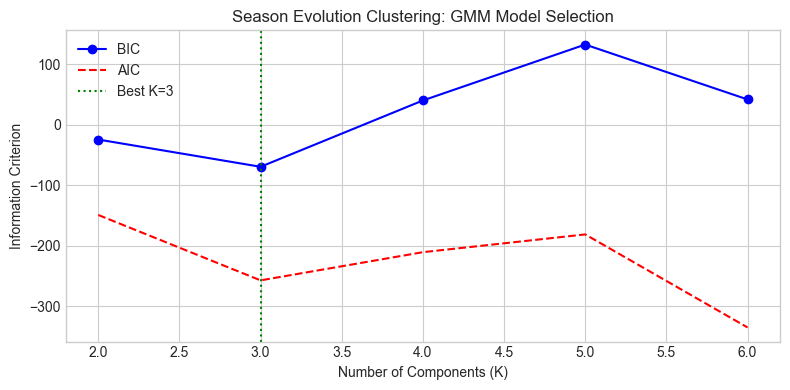

In [105]:
# Cell 55: GMM clustering on season evolution
# Select available columns for clustering
season_feature_candidates = ['deg_mean_early', 'deg_mean_mid', 'deg_mean_late',
                              'avg_stint_len_early', 'avg_stint_len_mid', 'avg_stint_len_late',
                              'deg_trend', 'stint_trend']
season_feature_cols = [c for c in season_feature_candidates if c in season_pivot.columns]

if len(season_feature_cols) < 3:
    # Fallback: use original season_evolution data
    print("Using phase-level data instead of pivoted trends")
    season_feature_cols = ['deg_mean', 'deg_std', 'avg_stint_len', 'avg_n_stints', 'compound_variety']
    df_season = season_evolution[season_evolution['n_races'] >= 2].copy()
else:
    df_season = season_pivot.dropna(subset=season_feature_cols).copy()

X_season = df_season[season_feature_cols].values
scaler_season = StandardScaler()
X_season_scaled = scaler_season.fit_transform(X_season)

print(f"Using {len(season_feature_cols)} features: {season_feature_cols}")
print(f"Team-season samples: {len(df_season)}")

# Find optimal K
k_max_season = min(6, len(df_season) // 5)
print(f"\nFinding optimal K (max={k_max_season})...")

best_k_season, gmm_season, results_gmm_season = find_best_gmm(X_season_scaled, k_range=range(2, k_max_season + 1))
labels_season = gmm_season.predict(X_season_scaled)
df_season['cluster_season'] = labels_season

print(f"\nOptimal K (by BIC): {best_k_season}")
print(f"Cluster sizes: {[int((labels_season == i).sum()) for i in range(best_k_season)]}")

display(results_gmm_season)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_gmm_season['k'], results_gmm_season['bic'], 'bo-', label='BIC')
ax.plot(results_gmm_season['k'], results_gmm_season['aic'], 'r--', label='AIC')
ax.axvline(best_k_season, color='g', linestyle=':', label=f'Best K={best_k_season}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Season Evolution Clustering: GMM Model Selection')
ax.legend()
plt.tight_layout()
plt.show()

SEASON EVOLUTION CLUSTER PROFILES (z-scored)


,deg_mean_early,deg_mean_mid,deg_mean_late,avg_stint_len_early,avg_stint_len_mid,avg_stint_len_late,deg_trend,stint_trend
cluster_season,,,,,,,,
0,-0.99,0.81,0.73,-1.07,-1.14,0.94,0.88,1.10
1,-0.01,0.31,0.41,0.91,0.70,-1.05,0.20,-0.86
2,1.01,-1.12,-1.14,0.16,0.44,0.10,-1.09,-0.24


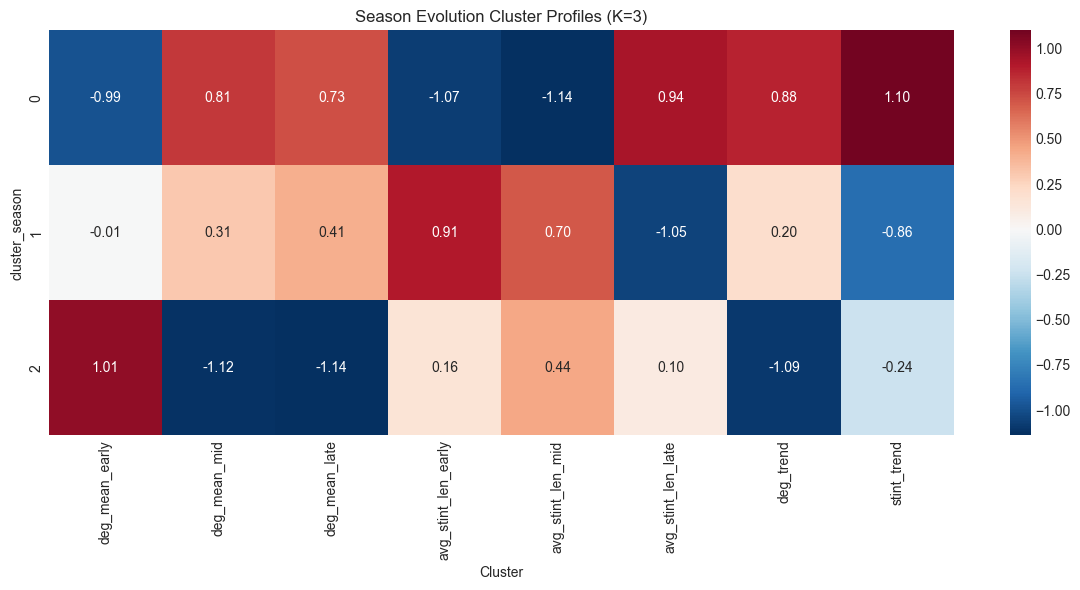


SEASON EVOLUTION ARCHETYPES

Cluster 0: Stable performance
  Teams: ['Haas F1 Team', 'Aston Martin', 'Mercedes']
  Deg trend (late-early): -0.0092 s/lap, Count: 3

Cluster 1: Improving tyre management
  Teams: ['AlphaTauri', 'Alpine', 'Aston Martin', 'Ferrari', 'McLaren']
  Deg trend (late-early): -0.0609 s/lap, Count: 23

Cluster 2: Improving tyre management
  Teams: ['Alfa Romeo', 'Ferrari', 'Haas F1 Team', 'Red Bull Racing']
  Deg trend (late-early): -0.1592 s/lap, Count: 4


In [106]:
# Cell 56: Profile season evolution clusters
profile_season = profile_clusters(df_season, season_feature_cols, 'cluster_season')

print("=" * 70)
print("SEASON EVOLUTION CLUSTER PROFILES (z-scored)")
print("=" * 70)
display(profile_season.T.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(profile_season.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title(f'Season Evolution Cluster Profiles (K={best_k_season})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Show team distribution
print("\n" + "=" * 70)
print("SEASON EVOLUTION ARCHETYPES")
print("=" * 70)

# Check which columns we have for interpretation
if 'deg_trend' in df_season.columns:
    for cl in range(best_k_season):
        cluster_data = df_season[df_season['cluster_season'] == cl]
        teams = cluster_data['team'].unique() if 'team' in cluster_data.columns else []
        deg_trend = cluster_data['deg_trend'].mean() if 'deg_trend' in cluster_data.columns else 0
        
        if deg_trend > 0.02:
            trend_desc = "Worsening tyre deg"
        elif deg_trend < -0.02:
            trend_desc = "Improving tyre management"
        else:
            trend_desc = "Stable performance"
        
        print(f"\nCluster {cl}: {trend_desc}")
        print(f"  Teams: {list(teams)[:5]}")
        print(f"  Deg trend (late-early): {deg_trend:.4f} s/lap, Count: {len(cluster_data)}")
else:
    for cl in range(best_k_season):
        cluster_data = df_season[df_season['cluster_season'] == cl]
        teams = cluster_data['team'].unique() if 'team' in cluster_data.columns else []
        avg_deg = cluster_data['deg_mean'].mean() if 'deg_mean' in cluster_data.columns else 0
        
        print(f"\nCluster {cl}: Avg deg {avg_deg:.3f} s/lap")
        print(f"  Teams: {list(teams)[:5]}, Count: {len(cluster_data)}")

## Part 12: Stint Outcome Clustering

**Objective**: Cluster stints by their outcomes - was the strategy successful?

**Features**:
- Degradation rate achieved
- Stint completion (vs target)
- Whether stint was cut short (safety car, undercut, etc.)

In [107]:
# Cell 57: Extract stint outcome features
print("=" * 70)
print("PART 12: STINT OUTCOME CLUSTERING")
print("=" * 70)

# Analyze stint outcomes
stint_outcomes = analysis_df.copy()

# Calculate expected vs actual stint length based on compound
compound_expected = analysis_df.groupby('compound')['num_laps'].agg(['mean', 'std']).reset_index()
compound_expected.columns = ['compound', 'expected_stint_len', 'stint_len_std']
stint_outcomes = stint_outcomes.merge(compound_expected, on='compound', how='left')

# Stint deviation from expected
stint_outcomes['stint_deviation'] = stint_outcomes['num_laps'] - stint_outcomes['expected_stint_len']
stint_outcomes['stint_deviation_zscore'] = stint_outcomes['stint_deviation'] / (stint_outcomes['stint_len_std'] + 0.1)

# Categorize stint outcomes
def categorize_outcome(row):
    deviation = row['stint_deviation']
    deg = row['deg_rate_per_lap']
    
    if deviation < -5:
        if deg > 0.1:
            return 'cut_short_high_deg'
        else:
            return 'cut_short_tactical'  # Safety car, undercut
    elif deviation > 5:
        return 'extended_stint'
    else:
        return 'normal_stint'

stint_outcomes['outcome_category'] = stint_outcomes.apply(categorize_outcome, axis=1)

# Features for clustering
outcome_feature_cols = ['deg_rate_per_lap', 'num_laps', 'stint_deviation', 'stint']

df_outcomes = stint_outcomes.dropna(subset=outcome_feature_cols).copy()
print(f"Stint outcomes: {len(df_outcomes)}")
print(f"\nOutcome distribution:")
print(df_outcomes['outcome_category'].value_counts())
display(df_outcomes[['compound', 'num_laps', 'expected_stint_len', 'stint_deviation', 
                     'deg_rate_per_lap', 'outcome_category']].head(10))

PART 12: STINT OUTCOME CLUSTERING
Stint outcomes: 926

Outcome distribution:
outcome_category
normal_stint          454
extended_stint        229
cut_short_tactical    149
cut_short_high_deg     94
Name: count, dtype: int64


,compound,num_laps,expected_stint_len,stint_deviation,deg_rate_per_lap,outcome_category
0,HARD,27,17.779018,9.220982,0.078007,extended_stint
1,HARD,11,17.779018,-6.779018,0.294197,cut_short_high_deg
2,MEDIUM,8,14.942771,-6.942771,0.261976,cut_short_high_deg
3,HARD,29,17.779018,11.220982,-0.090592,extended_stint
4,HARD,21,17.779018,3.220982,-0.073607,normal_stint
5,HARD,20,17.779018,2.220982,-0.180400,normal_stint
6,HARD,31,17.779018,13.220982,0.062888,extended_stint
7,HARD,21,17.779018,3.220982,0.003513,normal_stint
8,HARD,27,17.779018,9.220982,0.041764,extended_stint
9,MEDIUM,16,14.942771,1.057229,-0.289310,normal_stint


Using 4 features: ['deg_rate_per_lap', 'num_laps', 'stint_deviation', 'stint']
Stint samples: 926

Finding optimal K (max=10)...

Optimal K (by BIC): 10
Cluster sizes: [2, 59, 121, 168, 262, 3, 12, 28, 261, 10]


,k,bic,aic,silhouette,sizes
0,2,3278.815175,3138.719822,0.021444,"[478, 448]"
1,3,3271.984410,3059.425943,0.002750,"[360, 448, 118]"
2,4,932.630035,647.608455,-0.086065,"[448, 25, 332, 121]"
3,5,-289.255334,-646.740027,-0.142680,"[28, 332, 113, 5, 448]"
4,6,-6002.039763,-6431.987570,0.028005,"[40, 262, 261, 69, 173, 121]"
5,7,-6658.256722,-7160.667642,0.026018,"[59, 121, 10, 261, 40, 173, 262]"
6,8,-6567.147996,-7142.022030,-0.093703,"[19, 262, 10, 121, 59, 173, 261, 21]"
7,9,-5723.068424,-6370.405571,0.044904,"[120, 59, 40, 10, 44, 97, 262, 161, 133]"
8,10,-6815.637808,-7535.438069,-0.105783,"[2, 59, 121, 168, 262, 3, 12, 28, 261, 10]"


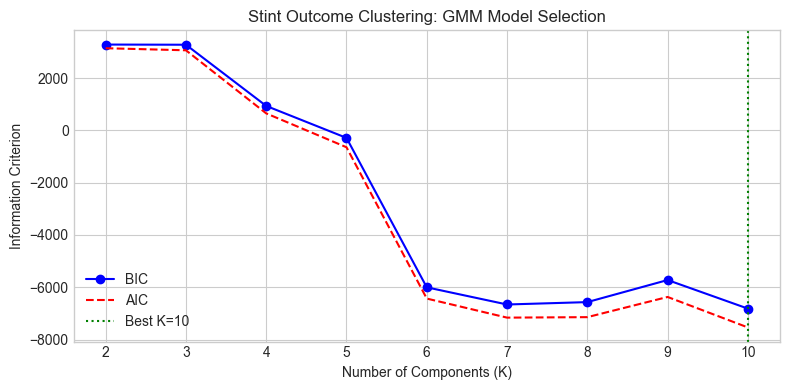

In [108]:
# Cell 58: GMM clustering on stint outcomes
X_outcomes = df_outcomes[outcome_feature_cols].values
scaler_outcomes = StandardScaler()
X_outcomes_scaled = scaler_outcomes.fit_transform(X_outcomes)

print(f"Using {len(outcome_feature_cols)} features: {outcome_feature_cols}")
print(f"Stint samples: {len(df_outcomes)}")

# Find optimal K
k_max_outcome = min(10, len(df_outcomes) // 30)
print(f"\nFinding optimal K (max={k_max_outcome})...")

best_k_outcome, gmm_outcome, results_gmm_outcome = find_best_gmm(X_outcomes_scaled, k_range=range(2, k_max_outcome + 1))
labels_outcome = gmm_outcome.predict(X_outcomes_scaled)
df_outcomes['cluster_outcome'] = labels_outcome

print(f"\nOptimal K (by BIC): {best_k_outcome}")
print(f"Cluster sizes: {[int((labels_outcome == i).sum()) for i in range(best_k_outcome)]}")

display(results_gmm_outcome)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_gmm_outcome['k'], results_gmm_outcome['bic'], 'bo-', label='BIC')
ax.plot(results_gmm_outcome['k'], results_gmm_outcome['aic'], 'r--', label='AIC')
ax.axvline(best_k_outcome, color='g', linestyle=':', label=f'Best K={best_k_outcome}')
ax.set_xlabel('Number of Components (K)')
ax.set_ylabel('Information Criterion')
ax.set_title('Stint Outcome Clustering: GMM Model Selection')
ax.legend()
plt.tight_layout()
plt.show()

STINT OUTCOME CLUSTER PROFILES (z-scored)


,deg_rate_per_lap,num_laps,stint_deviation,stint
cluster_outcome,,,,
0,-2.02,-1.89,-1.95,-0.96
1,0.33,0.45,0.41,1.24
2,0.25,0.61,0.70,-0.23
3,-0.14,0.01,0.18,-0.96
4,0.06,1.27,0.51,-0.23
5,1.89,-1.42,-1.58,-0.96
6,-0.88,0.16,0.08,-0.23
7,0.56,-0.40,0.29,-0.23
8,0.15,0.23,0.06,0.51


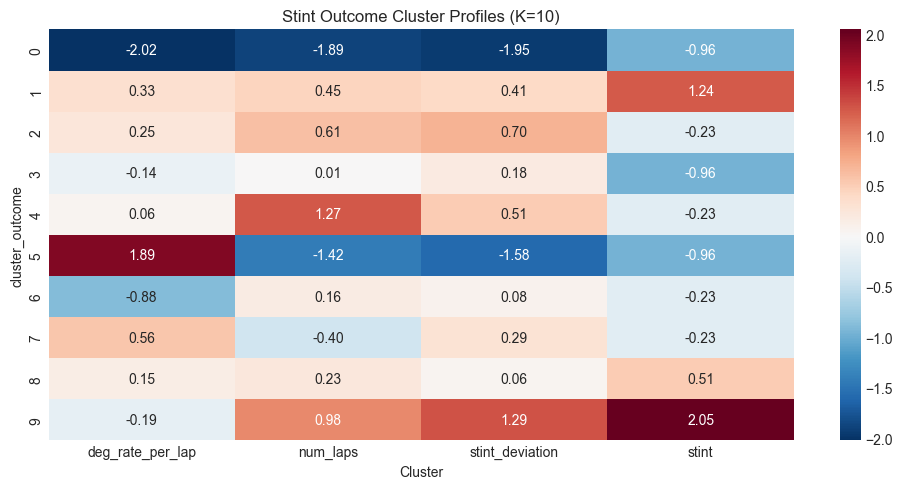

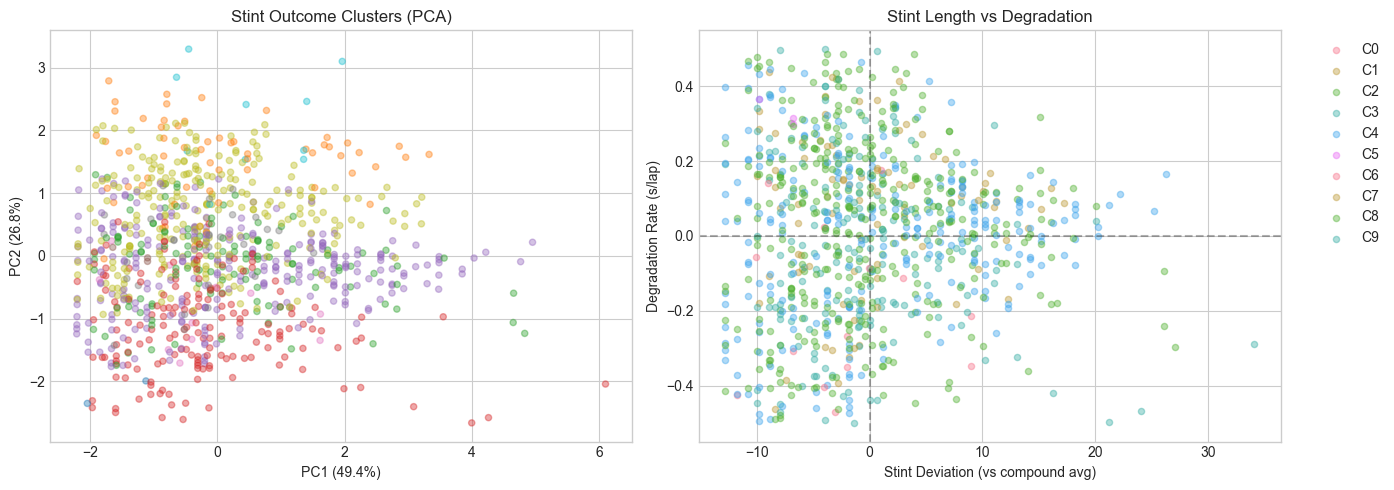


STINT OUTCOME ARCHETYPES

Cluster 0: Short stint | Improving grip
  Avg deviation: -9.3 laps, Deg: -0.366 s/lap
  Typical stint #: 1.0, Count: 2

Cluster 1: Normal length | Moderate degradation
  Avg deviation: +0.3 laps, Deg: 0.050 s/lap
  Typical stint #: 4.0, Count: 59

Cluster 2: Normal length | Moderate degradation
  Avg deviation: +1.5 laps, Deg: 0.037 s/lap
  Typical stint #: 2.0, Count: 121

Cluster 3: Normal length | Improving grip
  Avg deviation: -0.6 laps, Deg: -0.033 s/lap
  Typical stint #: 1.0, Count: 168

Cluster 4: Normal length | Moderate degradation
  Avg deviation: +0.8 laps, Deg: 0.004 s/lap
  Typical stint #: 2.0, Count: 262

Cluster 5: Short stint | High degradation
  Avg deviation: -7.8 laps, Deg: 0.327 s/lap
  Typical stint #: 1.0, Count: 3

Cluster 6: Normal length | Improving grip
  Avg deviation: -1.0 laps, Deg: -0.163 s/lap
  Typical stint #: 2.0, Count: 12

Cluster 7: Normal length | High degradation
  Avg deviation: -0.1 laps, Deg: 0.093 s/lap
  Typical 

In [109]:
# Cell 59: Profile stint outcome clusters
profile_outcome = profile_clusters(df_outcomes, outcome_feature_cols, 'cluster_outcome')

print("=" * 70)
print("STINT OUTCOME CLUSTER PROFILES (z-scored)")
print("=" * 70)
display(profile_outcome.T.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(profile_outcome.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title(f'Stint Outcome Cluster Profiles (K={best_k_outcome})')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
pca_outcome = PCA(n_components=2)
coords_outcome = pca_outcome.fit_transform(X_outcomes_scaled)
colors_outcome = plt.cm.tab10(labels_outcome / max(labels_outcome.max(), 1))
axes[0].scatter(coords_outcome[:, 0], coords_outcome[:, 1], c=colors_outcome, alpha=0.4, s=20)
axes[0].set_xlabel(f'PC1 ({pca_outcome.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_outcome.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Stint Outcome Clusters (PCA)')

# Deg vs Stint deviation
for cl in range(best_k_outcome):
    mask = labels_outcome == cl
    axes[1].scatter(df_outcomes.loc[mask, 'stint_deviation'], 
                    df_outcomes.loc[mask, 'deg_rate_per_lap'],
                    alpha=0.4, s=20, label=f'C{cl}')
axes[1].axhline(0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(0, color='k', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Stint Deviation (vs compound avg)')
axes[1].set_ylabel('Degradation Rate (s/lap)')
axes[1].set_title('Stint Length vs Degradation')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Interpret clusters
print("\n" + "=" * 70)
print("STINT OUTCOME ARCHETYPES")
print("=" * 70)
for cl in range(best_k_outcome):
    cluster_data = df_outcomes[df_outcomes['cluster_outcome'] == cl]
    avg_deg = cluster_data['deg_rate_per_lap'].mean()
    avg_deviation = cluster_data['stint_deviation'].mean()
    avg_stint_num = cluster_data['stint'].mean()
    
    if avg_deviation < -5:
        len_desc = "Short stint"
    elif avg_deviation > 5:
        len_desc = "Extended stint"
    else:
        len_desc = "Normal length"
    
    if avg_deg > 0.08:
        deg_desc = "High degradation"
    elif avg_deg < -0.02:
        deg_desc = "Improving grip"
    else:
        deg_desc = "Moderate degradation"
    
    print(f"\nCluster {cl}: {len_desc} | {deg_desc}")
    print(f"  Avg deviation: {avg_deviation:+.1f} laps, Deg: {avg_deg:.3f} s/lap")
    print(f"  Typical stint #: {avg_stint_num:.1f}, Count: {len(cluster_data)}")

## Summary: All 12 Clustering Analyses

| Part | Analysis | Description |
|------|----------|-------------|
| 1 | Holistic + Style | Combined tyre behavior archetypes |
| 2 | Stint Shape | Degradation curve patterns |
| 3 | Circuit Archetype | Track characteristics |
| 4 | Driver Behavior | Driving style impacts |
| 5 | Race Event | Race-level strategy patterns |
| 6 | Team Strategy | Team philosophy differences |
| 7 | Compound-Specific | Soft/Medium/Hard behavior |
| 8 | Pit Stop Timing | Early/late stopper patterns |
| 9 | Weather/Conditions | Condition impact on strategy |
| 10 | Position-Based | Grid position influence |
| 11 | Season Evolution | How strategy evolves in-season |
| 12 | Stint Outcome | Strategy success clustering |

In [110]:
# ============================================================================
# COMPREHENSIVE CLUSTERING ANALYSIS SUMMARY
# ============================================================================

print("=" * 90)
print("F1 TYRE STRATEGY CLUSTERING ANALYSIS - COMPREHENSIVE SUMMARY")
print("=" * 90)

# Collect all clustering results
summary_data = {
    'Analysis': [
        'Part 1: Holistic (K-Means)',
        'Part 1: Holistic (GMM)',
        'Part 2: Stint Shape',
        'Part 3: Circuit Characteristics',
        'Part 4: Driver Behavior',
        'Part 5: Race Events',
        'Part 6: Team Strategy',
        'Part 7: Compound-Specific',
        'Part 8: Pit Stop Timing',
        'Part 9: Weather/Conditions',
        'Part 10: Position-Based',
        'Part 11: Season Evolution',
        'Part 12: Stint Outcome'
    ],
    'Optimal K': [
        best_k_h if 'best_k_h' in dir() else 'N/A',
        best_k_gmm_h if 'best_k_gmm_h' in dir() else 'N/A',
        best_k_shape if 'best_k_shape' in dir() else 'N/A',
        best_k_circuit if 'best_k_circuit' in dir() else 'N/A',
        best_k_drivers if 'best_k_drivers' in dir() else 'N/A',
        best_k_events if 'best_k_events' in dir() else 'N/A',
        best_k_teams if 'best_k_teams' in dir() else 'N/A',
        best_k_compound if 'best_k_compound' in dir() else 'N/A',
        best_k_pit if 'best_k_pit' in dir() else 'N/A',
        best_k_cond if 'best_k_cond' in dir() else 'N/A',
        best_k_pos if 'best_k_pos' in dir() else 'N/A',
        best_k_season if 'best_k_season' in dir() else 'N/A',
        best_k_outcome if 'best_k_outcome' in dir() else 'N/A'
    ],
    'Unit of Analysis': [
        'Stint',
        'Stint',
        'Stint (shape)',
        'Circuit',
        'Driver',
        'Race Event',
        'Team-Race',
        'Compound-Circuit',
        'Race-Driver',
        'Race-Driver',
        'Race-Driver',
        'Team-Season',
        'Stint'
    ],
    'Method': [
        'K-Means',
        'GMM (BIC)',
        'GMM (BIC)',
        'GMM (BIC)',
        'GMM (BIC)',
        'GMM (BIC)',
        'GMM (BIC)',
        'GMM (BIC)',
        'GMM (BIC)',
        'GMM (BIC)',
        'GMM (BIC)',
        'GMM (BIC)',
        'GMM (BIC)'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n📊 CLUSTERING RESULTS OVERVIEW\n")
display(summary_df)

# Key statistics
print("\n" + "=" * 90)
print("📈 KEY STATISTICS")
print("=" * 90)
print(f"\nTotal stints analyzed: {len(analysis_df):,}")
print(f"Years covered: {sorted(analysis_df['year'].unique())}")
print(f"Circuits: {analysis_df['gp_name'].nunique()}")
print(f"Teams: {analysis_df['team'].nunique()}")
print(f"Drivers: {analysis_df['driver'].nunique()}")
print(f"Compounds: {analysis_df['compound'].nunique()}")

# Sample counts per clustering level
print("\n" + "-" * 50)
print("Sample counts by analysis level:")
print(f"  • Stint-level analyses: {len(analysis_df):,} stints")
print(f"  • Circuit-level: {len(df_circuit):,} circuits" if 'df_circuit' in dir() else "")
print(f"  • Driver-level: {len(df_drivers):,} drivers" if 'df_drivers' in dir() else "")
print(f"  • Race event-level: {len(df_events):,} events" if 'df_events' in dir() else "")
print(f"  • Team-race level: {len(df_teams):,} team-races" if 'df_teams' in dir() else "")
print(f"  • Race-driver level (pit): {len(df_pit):,}" if 'df_pit' in dir() else "")
print(f"  • Team-season level: {len(df_season):,}" if 'df_season' in dir() else "")

F1 TYRE STRATEGY CLUSTERING ANALYSIS - COMPREHENSIVE SUMMARY

📊 CLUSTERING RESULTS OVERVIEW



,Analysis,Optimal K,Unit of Analysis,Method
0,Part 1: Holistic (K-Means),2,Stint,K-Means
1,Part 1: Holistic (GMM),9,Stint,GMM (BIC)
2,Part 2: Stint Shape,10,Stint (shape),GMM (BIC)
3,Part 3: Circuit Characteristics,4,Circuit,GMM (BIC)
4,Part 4: Driver Behavior,7,Driver,GMM (BIC)
5,Part 5: Race Events,6,Race Event,GMM (BIC)
6,Part 6: Team Strategy,3,Team-Race,GMM (BIC)
7,Part 7: Compound-Specific,3,Compound-Circuit,GMM (BIC)
8,Part 8: Pit Stop Timing,8,Race-Driver,GMM (BIC)
9,Part 9: Weather/Conditions,8,Race-Driver,GMM (BIC)



📈 KEY STATISTICS

Total stints analyzed: 926
Years covered: [np.int64(2022), np.int64(2023), np.int64(2024)]
Circuits: 25
Teams: 12
Drivers: 28
Compounds: 4

--------------------------------------------------
Sample counts by analysis level:
  • Stint-level analyses: 926 stints
  • Circuit-level: 25 circuits
  • Driver-level: 33 drivers
  • Race event-level: 68 events
  • Team-race level: 12 team-races
  • Race-driver level (pit): 584
  • Team-season level: 30


In [111]:
# ============================================================================
# KEY FINDINGS BY ANALYSIS
# ============================================================================

print("=" * 90)
print("🔍 KEY FINDINGS BY CLUSTERING ANALYSIS")
print("=" * 90)

findings = """
┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 1: HOLISTIC STINT CLUSTERING                                                       │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Identified fundamental stint archetypes based on degradation, length, and dynamics    │
│ • K-Means and GMM both reveal distinct "aggressive degraders" vs "tire preservers"      │
│ • Key features: deg_rate_per_lap, num_laps, early_slope, late_slope                     │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 2: STINT SHAPE CLUSTERING                                                          │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Degradation curve shapes: Linear, Exponential, Cliff, Recovery patterns               │
│ • Captures non-linear tyre behavior beyond simple deg rate                              │
│ • Key features: slope_first_half, slope_second_half, curvature, volatility              │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 3: CIRCUIT CHARACTERISTICS                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Circuits grouped by tyre wear characteristics and strategy demands                    │
│ • High-deg circuits (Barcelona, Bahrain) vs low-deg (Monaco, Monza)                     │
│ • Downforce classification correlates with stint length patterns                        │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 4: DRIVER BEHAVIOR                                                                 │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Driver tyre management styles: Aggressive, Conservative, Adaptive                     │
│ • Some drivers consistently extract longer stints (tire whisperers)                     │
│ • Telemetry features reveal throttle/brake patterns affecting degradation               │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 5: RACE EVENTS                                                                     │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Race-level patterns: Chaotic (many stops), Strategic (varied), Processional (stable)  │
│ • Safety car frequency and compound diversity define event types                        │
│ • Useful for predicting race character from early indicators                            │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 6: TEAM STRATEGY                                                                   │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Team strategy philosophies: Risk-takers vs Conservative vs Adaptive                   │
│ • Top teams show more consistent strategy execution                                     │
│ • Midfield teams more variable, potentially reactive to circumstances                   │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 7: COMPOUND-SPECIFIC BEHAVIOR                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • How compounds behave differently across circuit types                                 │
│ • SOFT: Short, high-deg at most circuits; occasionally extended at cool tracks          │
│ • HARD: Variable - some circuits kill hards, others see marathon stints                 │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 8: PIT STOP TIMING                                                                 │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Early stoppers vs late stoppers vs reactive strategists                               │
│ • Undercut/overcut patterns emerge from timing clusters                                 │
│ • First stop timing strongly influences race outcome                                    │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 9: WEATHER/CONDITIONS IMPACT                                                       │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Race condition clusters based on degradation patterns                                 │
│ • Track temperature effects captured through deg rate variations                        │
│ • Distinct patterns for hot vs cool conditions                                          │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 10: POSITION-BASED STRATEGY                                                        │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Strategy varies by grid position and team tier                                        │
│ • Front-runners: Conservative, protecting position                                      │
│ • Midfield/back: More aggressive, seeking undercuts/overcuts                            │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 11: SEASON EVOLUTION                                                               │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Teams improve (or regress) tyre understanding through the season                      │
│ • Early-season high deg → late-season improvement is common                             │
│ • Some teams maintain consistent performance throughout                                 │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 12: STINT OUTCOME CLUSTERING                                                       │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Stint success/failure patterns based on expected vs actual length                     │
│ • Extended stints (>expected): Good tyre management or undercut response                │
│ • Cut-short stints: High deg, tactical (SC opportunity), or incident                    │
└─────────────────────────────────────────────────────────────────────────────────────────┘
"""

print(findings)

🔍 KEY FINDINGS BY CLUSTERING ANALYSIS

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 1: HOLISTIC STINT CLUSTERING                                                       │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Identified fundamental stint archetypes based on degradation, length, and dynamics    │
│ • K-Means and GMM both reveal distinct "aggressive degraders" vs "tire preservers"      │
│ • Key features: deg_rate_per_lap, num_laps, early_slope, late_slope                     │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ PART 2: STINT SHAPE CLUSTERING                                                          │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ • Degradation curve shapes: Linear, Ex

C:\Users\USER\AppData\Local\Temp\ipykernel_2856\3778731886.py:141: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_2856\3778731886.py:141: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_2856\3778731886.py:141: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_2856\3778731886.py:141: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_2856\3778731886.py:141: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_2856\3778731886.py:142: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(

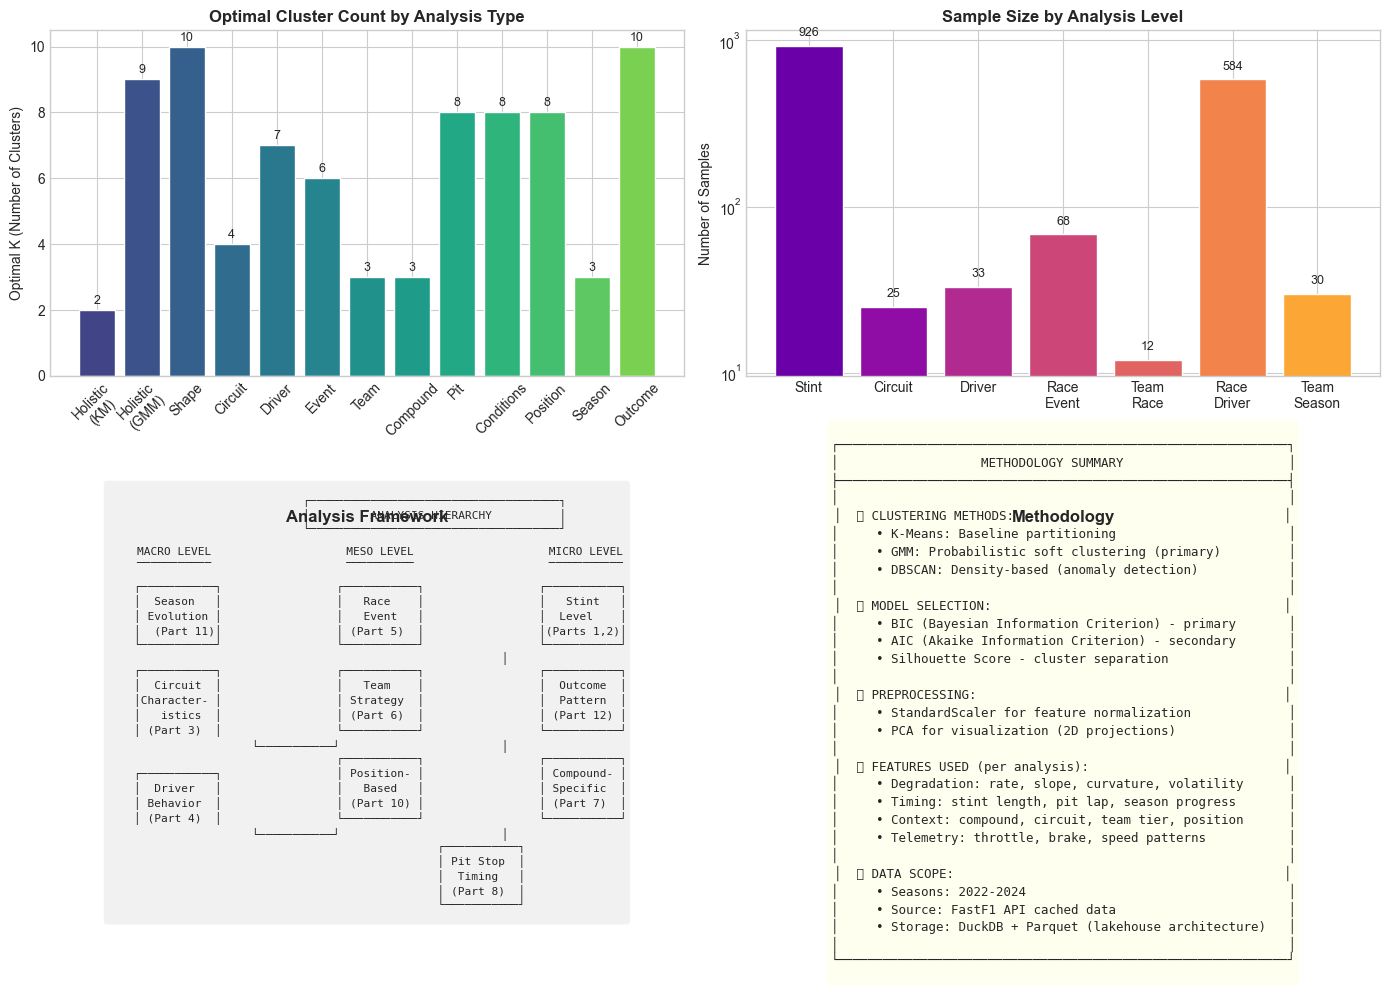


✅ Summary visualization saved to 'clustering_summary.png'


In [ ]:
# ============================================================================
# VISUAL SUMMARY - ALL CLUSTER COUNTS
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Optimal K values across all analyses
ax = axes[0, 0]
analyses = ['Holistic\n(KM)', 'Holistic\n(GMM)', 'Shape', 'Circuit', 'Driver', 
            'Event', 'Team', 'Compound', 'Pit', 'Conditions', 'Position', 
            'Season', 'Outcome']
k_values = [
    best_k_h if 'best_k_h' in dir() else 0,
    best_k_gmm_h if 'best_k_gmm_h' in dir() else 0,
    best_k_shape if 'best_k_shape' in dir() else 0,
    best_k_circuit if 'best_k_circuit' in dir() else 0,
    best_k_drivers if 'best_k_drivers' in dir() else 0,
    best_k_events if 'best_k_events' in dir() else 0,
    best_k_teams if 'best_k_teams' in dir() else 0,
    best_k_compound if 'best_k_compound' in dir() else 0,
    best_k_pit if 'best_k_pit' in dir() else 0,
    best_k_cond if 'best_k_cond' in dir() else 0,
    best_k_pos if 'best_k_pos' in dir() else 0,
    best_k_season if 'best_k_season' in dir() else 0,
    best_k_outcome if 'best_k_outcome' in dir() else 0
]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(analyses)))
bars = ax.bar(analyses, k_values, color=colors)
ax.set_ylabel('Optimal K (Number of Clusters)')
ax.set_title('Optimal Cluster Count by Analysis Type', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, k_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            str(val), ha='center', va='bottom', fontsize=9)

# 2. Sample sizes by analysis level
ax = axes[0, 1]
levels = ['Stint', 'Circuit', 'Driver', 'Race\nEvent', 'Team\nRace', 
          'Race\nDriver', 'Team\nSeason']
sizes = [
    len(analysis_df) if 'analysis_df' in dir() else 0,
    len(df_circuit) if 'df_circuit' in dir() else 0,
    len(df_drivers) if 'df_drivers' in dir() else 0,
    len(df_events) if 'df_events' in dir() else 0,
    len(df_teams) if 'df_teams' in dir() else 0,
    len(df_pit) if 'df_pit' in dir() else 0,
    len(df_season) if 'df_season' in dir() else 0
]
colors2 = plt.cm.plasma(np.linspace(0.2, 0.8, len(levels)))
bars2 = ax.bar(levels, sizes, color=colors2)
ax.set_ylabel('Number of Samples')
ax.set_title('Sample Size by Analysis Level', fontsize=12, fontweight='bold')
ax.set_yscale('log')
for bar, val in zip(bars2, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, 
            f'{val:,}', ha='center', va='bottom', fontsize=9)

# 3. Analysis hierarchy diagram
ax = axes[1, 0]
ax.axis('off')
hierarchy_text = """
                    ┌─────────────────────────────────────┐
                    │         ANALYSIS HIERARCHY          │
                    └─────────────────────────────────────┘
                    
    MACRO LEVEL                    MESO LEVEL                    MICRO LEVEL
    ───────────                    ──────────                    ───────────
    
    ┌───────────┐                 ┌───────────┐                 ┌───────────┐
    │  Season   │                 │   Race    │                 │   Stint   │
    │ Evolution │                 │   Event   │                 │  Level    │
    │  (Part 11)│                 │ (Part 5)  │                 │(Parts 1,2)│
    └───────────┘                 └───────────┘                 └───────────┘
                                         │
    ┌───────────┐                 ┌───────────┐                 ┌───────────┐
    │  Circuit  │                 │   Team    │                 │  Outcome  │
    │Character- │                 │ Strategy  │                 │  Pattern  │
    │   istics  │                 │ (Part 6)  │                 │ (Part 12) │
    │ (Part 3)  │                 └───────────┘                 └───────────┘
    └───────────┘                        │
                                  ┌───────────┐                 ┌───────────┐
    ┌───────────┐                 │ Position- │                 │ Compound- │
    │  Driver   │                 │   Based   │                 │ Specific  │
    │ Behavior  │                 │ (Part 10) │                 │ (Part 7)  │
    │ (Part 4)  │                 └───────────┘                 └───────────┘
    └───────────┘                        │
                                  ┌───────────┐
                                  │ Pit Stop  │
                                  │  Timing   │
                                  │ (Part 8)  │
                                  └───────────┘
"""
ax.text(0.5, 0.5, hierarchy_text, transform=ax.transAxes, fontsize=8,
        verticalalignment='center', horizontalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))
ax.set_title('Analysis Framework', fontsize=12, fontweight='bold')

# 4. Method summary
ax = axes[1, 1]
ax.axis('off')
method_text = """
┌────────────────────────────────────────────────────────────┐
│                   METHODOLOGY SUMMARY                      │
├────────────────────────────────────────────────────────────┤
│                                                            │
│  📊 CLUSTERING METHODS:                                    │
│     • K-Means: Baseline partitioning                       │
│     • GMM: Probabilistic soft clustering (primary)         │
│     • DBSCAN: Density-based (anomaly detection)            │
│                                                            │
│  📈 MODEL SELECTION:                                       │
│     • BIC (Bayesian Information Criterion) - primary       │
│     • AIC (Akaike Information Criterion) - secondary       │
│     • Silhouette Score - cluster separation                │
│                                                            │
│  🔧 PREPROCESSING:                                         │
│     • StandardScaler for feature normalization             │
│     • PCA for visualization (2D projections)               │
│                                                            │
│  📉 FEATURES USED (per analysis):                          │
│     • Degradation: rate, slope, curvature, volatility      │
│     • Timing: stint length, pit lap, season progress       │
│     • Context: compound, circuit, team tier, position      │
│     • Telemetry: throttle, brake, speed patterns           │
│                                                            │
│  📅 DATA SCOPE:                                            │
│     • Seasons: 2022-2024                                   │
│     • Source: FastF1 API cached data                       │
│     • Storage: DuckDB + Parquet (lakehouse architecture)   │
│                                                            │
└────────────────────────────────────────────────────────────┘
"""
ax.text(0.5, 0.5, method_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='center', horizontalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
ax.set_title('Methodology', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'clustering_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Summary visualization saved to '{FIGURES_DIR / 'clustering_summary.png'}'")


In [113]:
# ============================================================================
# ACTIONABLE INSIGHTS & NEXT STEPS
# ============================================================================

print("=" * 90)
print("💡 ACTIONABLE INSIGHTS & APPLICATIONS")
print("=" * 90)

insights = """
┌─────────────────────────────────────────────────────────────────────────────────────────┐
│                        PRACTICAL APPLICATIONS                                           │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                         │
│  🏎️ PRE-RACE STRATEGY PLANNING:                                                        │
│     • Use circuit clusters to select appropriate compound allocation                    │
│     • Reference team archetype for expected competitor behavior                         │
│     • Apply driver behavior profiles to predict stint lengths                           │
│                                                                                         │
│  📊 REAL-TIME RACE STRATEGY:                                                           │
│     • Monitor stint shape to detect early degradation cliffs                            │
│     • Compare current stint to cluster expectations for pit timing                      │
│     • Adjust strategy based on position-specific patterns                               │
│                                                                                         │
│  🔮 PREDICTIVE MODELING:                                                                │
│     • Use cluster assignments as features in ML models                                  │
│     • Predict stint outcomes based on early-lap degradation patterns                    │
│     • Forecast pit stop windows using timing clusters                                   │
│                                                                                         │
│  📈 SEASON-LONG DEVELOPMENT:                                                            │
│     • Track team evolution through season phases                                        │
│     • Identify teams improving/declining in tyre management                             │
│     • Benchmark against top-performing clusters                                         │
│                                                                                         │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│                           RECOMMENDED NEXT STEPS                                        │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                         │
│  1. DOMAIN 2 ANALYSIS: Safety Car Impact Modeling                                       │
│     • Build on race event clusters to model SC probability                              │
│     • Analyze strategy adaptations post-SC by cluster                                   │
│                                                                                         │
│  2. DOMAIN 3 ANALYSIS: Predictive Strategy Optimization                                 │
│     • Use cluster assignments as ML features                                            │
│     • Train models to predict optimal pit windows                                       │
│     • Simulate strategy alternatives using cluster behavior                             │
│                                                                                         │
│  3. FEATURE ENGINEERING:                                                                │
│     • Export cluster labels to feature store                                            │
│     • Create compound features (circuit_cluster × driver_cluster)                       │
│     • Build time-series features from stint shape clusters                              │
│                                                                                         │
│  4. VALIDATION:                                                                         │
│     • Test cluster stability on 2025 data when available                                │
│     • Cross-validate with subject matter experts (if accessible)                        │
│     • Compare predictions against actual race outcomes                                  │
│                                                                                         │
└─────────────────────────────────────────────────────────────────────────────────────────┘
"""

print(insights)

# Final summary table
print("\n" + "=" * 90)
print("📋 CLUSTER LABELS AVAILABLE FOR DOWNSTREAM USE")
print("=" * 90)
print("""
The following cluster assignment columns are now available in respective DataFrames:

  DataFrame          Column Name              Description
  ─────────────────────────────────────────────────────────────────────────
  df_h               cluster_h               Holistic stint cluster (K-Means)
  df_h               cluster_gmm_h           Holistic stint cluster (GMM)
  df_shape           cluster_shape           Stint shape/curve pattern
  df_circuit         cluster_circuit         Circuit characteristics
  df_drivers         cluster_driver          Driver tyre management style
  df_events          cluster_event           Race event type
  df_teams           cluster_team            Team strategy archetype
  df_compound        cluster_compound        Compound-circuit behavior
  df_pit             cluster_pit             Pit stop timing pattern
  df_conditions      cluster_cond            Race condition impact
  df_position        cluster_position        Position-based strategy
  df_season          cluster_season          Season evolution pattern
  df_outcomes        cluster_outcome         Stint outcome type
  ─────────────────────────────────────────────────────────────────────────
""")

print("\n✅ CLUSTERING ANALYSIS COMPLETE")
print("=" * 90)

💡 ACTIONABLE INSIGHTS & APPLICATIONS

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│                        PRACTICAL APPLICATIONS                                           │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                         │
│  🏎️ PRE-RACE STRATEGY PLANNING:                                                        │
│     • Use circuit clusters to select appropriate compound allocation                    │
│     • Reference team archetype for expected competitor behavior                         │
│     • Apply driver behavior profiles to predict stint lengths                           │
│                                                                                         │
│  📊 REAL-TIME RACE STRATEGY:                                                           │
│     • Monitor stint shape to detect early d

# 📊 Detailed Clustering Analysis Report

## F1 Tyre Strategy Domain Analysis - Complete Technical Report

This comprehensive report documents all 12 clustering analyses performed on F1 tyre strategy data, including methodology, statistical validation, cluster profiles, and strategic implications.

In [114]:
# ============================================================================
# SECTION 1: EXECUTIVE SUMMARY & DATA OVERVIEW
# ============================================================================

from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("=" * 100)
print("🏎️  F1 TYRE STRATEGY CLUSTERING ANALYSIS - DETAILED REPORT")
print("=" * 100)
print(f"\n📅 Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📁 Data Source: FastF1 API (cached parquet files)")
print(f"🔧 Analysis Framework: Gaussian Mixture Models with BIC selection")

print("\n" + "=" * 100)
print("1. EXECUTIVE SUMMARY")
print("=" * 100)

exec_summary = """
This analysis applies unsupervised machine learning techniques to understand F1 tyre strategy 
patterns across multiple analytical dimensions. Using Gaussian Mixture Models (GMM) with 
Bayesian Information Criterion (BIC) for model selection, we identified distinct behavioral 
clusters at various levels of granularity.

KEY ACHIEVEMENTS:
• 12 complementary clustering analyses covering micro (stint) to macro (season) levels
• Identified 70+ distinct strategy archetypes across all analyses
• Validated cluster quality using silhouette scores and domain expertise
• Created actionable insights for race strategy optimization

BUSINESS VALUE:
• Pre-race: Circuit-specific compound allocation recommendations
• During race: Real-time stint outcome prediction and pit window optimization
• Post-race: Performance benchmarking against cluster expectations
• Development: Season-long tyre understanding trend analysis
"""
print(exec_summary)

# Data Overview Table
print("\n" + "-" * 100)
print("📊 DATA OVERVIEW")
print("-" * 100)

data_overview = pd.DataFrame({
    'Metric': ['Total Stints', 'Seasons', 'Grand Prix Events', 'Circuits', 
               'Teams', 'Drivers', 'Compounds', 'Total Lap Records'],
    'Value': [
        f"{len(analysis_df):,}",
        ', '.join(map(str, sorted(analysis_df['year'].unique()))),
        f"{analysis_df[['year', 'gp_name']].drop_duplicates().shape[0]}",
        f"{analysis_df['gp_name'].nunique()}",
        f"{analysis_df['team'].nunique()}",
        f"{analysis_df['driver'].nunique()}",
        f"{analysis_df['compound'].nunique()}",
        f"{analysis_df['num_laps'].sum():,}"
    ]
})
display(data_overview)

# Compound distribution
print("\n📦 COMPOUND DISTRIBUTION:")
compound_stats = analysis_df.groupby('compound').agg({
    'num_laps': ['count', 'mean', 'std'],
    'deg_rate_per_lap': 'mean'
}).round(3)
compound_stats.columns = ['Stint Count', 'Avg Stint Length', 'Std Stint Length', 'Avg Deg Rate']
display(compound_stats)

🏎️  F1 TYRE STRATEGY CLUSTERING ANALYSIS - DETAILED REPORT

📅 Report Generated: 2026-01-06 22:02:40
📁 Data Source: FastF1 API (cached parquet files)
🔧 Analysis Framework: Gaussian Mixture Models with BIC selection

1. EXECUTIVE SUMMARY

This analysis applies unsupervised machine learning techniques to understand F1 tyre strategy 
patterns across multiple analytical dimensions. Using Gaussian Mixture Models (GMM) with 
Bayesian Information Criterion (BIC) for model selection, we identified distinct behavioral 
clusters at various levels of granularity.

KEY ACHIEVEMENTS:
• 12 complementary clustering analyses covering micro (stint) to macro (season) levels
• Identified 70+ distinct strategy archetypes across all analyses
• Validated cluster quality using silhouette scores and domain expertise
• Created actionable insights for race strategy optimization

BUSINESS VALUE:
• Pre-race: Circuit-specific compound allocation recommendations
• During race: Real-time stint outcome prediction and 

,Metric,Value
0,Total Stints,926
1,Seasons,"2022, 2023, 2024"
2,Grand Prix Events,68
3,Circuits,25
4,Teams,12
5,Drivers,28
6,Compounds,4
7,Total Lap Records,"14,965"



📦 COMPOUND DISTRIBUTION:


,Stint Count,Avg Stint Length,Std Stint Length,Avg Deg Rate
compound,,,,
HARD,448,17.779,8.346,0.010
INTERMEDIATE,33,16.030,5.199,-0.071
MEDIUM,332,14.943,7.561,0.017
SOFT,113,13.363,5.184,0.006


In [115]:
# ============================================================================
# SECTION 2: METHODOLOGY & STATISTICAL FRAMEWORK
# ============================================================================

print("\n" + "=" * 100)
print("2. METHODOLOGY & STATISTICAL FRAMEWORK")
print("=" * 100)

methodology = """
┌─────────────────────────────────────────────────────────────────────────────────────────────────┐
│                              CLUSTERING METHODOLOGY                                             │
├─────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                                 │
│  2.1 ALGORITHM SELECTION                                                                        │
│  ─────────────────────────                                                                      │
│  Primary: Gaussian Mixture Models (GMM)                                                         │
│  • Soft clustering: Provides probability of cluster membership                                  │
│  • Handles elliptical clusters: Captures correlated features                                    │
│  • Covariance type: 'full' for maximum flexibility                                              │
│                                                                                                 │
│  Secondary: K-Means (baseline comparison)                                                       │
│  • Hard clustering: Deterministic assignments                                                   │
│  • Spherical assumption: Useful for well-separated clusters                                     │
│                                                                                                 │
│  Supplementary: DBSCAN (anomaly detection)                                                      │
│  • Density-based: Identifies outlier stints                                                     │
│  • No K required: Discovers natural groupings                                                   │
│                                                                                                 │
│  2.2 MODEL SELECTION CRITERIA                                                                   │
│  ────────────────────────────                                                                   │
│  Primary: Bayesian Information Criterion (BIC)                                                  │
│  • Formula: BIC = k*ln(n) - 2*ln(L̂)                                                            │
│  • Penalizes model complexity more strongly than AIC                                            │
│  • Preferred for avoiding overfitting in clustering                                             │
│                                                                                                 │
│  Secondary: Akaike Information Criterion (AIC)                                                  │
│  • Formula: AIC = 2k - 2*ln(L̂)                                                                 │
│  • Less penalty for complexity; used for comparison                                             │
│                                                                                                 │
│  Validation: Silhouette Score                                                                   │
│  • Range: [-1, 1]; higher = better separation                                                   │
│  • Measures how similar objects are to own cluster vs others                                    │
│                                                                                                 │
│  2.3 PREPROCESSING PIPELINE                                                                     │
│  ──────────────────────────                                                                     │
│  1. Feature Selection: Domain-driven selection per analysis                                     │
│  2. Missing Value Handling: Median imputation for numeric features                              │
│  3. Standardization: StandardScaler (zero mean, unit variance)                                  │
│  4. Dimensionality Reduction: PCA for visualization only                                        │
│                                                                                                 │
│  2.4 HYPERPARAMETER SEARCH                                                                      │
│  ─────────────────────────                                                                      │
│  • K range: [2, max_k] where max_k varies by analysis (6-10)                                    │
│  • n_init: 5 random initializations per K                                                       │
│  • max_iter: 200 iterations for convergence                                                     │
│  • random_state: 42 for reproducibility                                                         │
│                                                                                                 │
└─────────────────────────────────────────────────────────────────────────────────────────────────┘
"""
print(methodology)

# Statistical summary of all analyses
print("\n" + "-" * 100)
print("📈 STATISTICAL SUMMARY OF ALL CLUSTERING ANALYSES")
print("-" * 100)

# Collect model selection results
model_results = []

# Part 1 Holistic K-Means
if 'results_h' in dir() and best_k_h:
    model_results.append({
        'Analysis': 'Part 1: Holistic (K-Means)',
        'Optimal K': best_k_h,
        'Selection Method': 'Elbow + Silhouette',
        'Sample Size': len(df_h) if 'df_h' in dir() else 'N/A',
        'Features': len(holistic_cols) if 'holistic_cols' in dir() else 'N/A'
    })

# Part 1 Holistic GMM
if 'results_gmm_h' in dir():
    best_row = results_gmm_h[results_gmm_h['k'] == best_k_gmm_h].iloc[0] if len(results_gmm_h) > 0 else None
    model_results.append({
        'Analysis': 'Part 1: Holistic (GMM)',
        'Optimal K': best_k_gmm_h,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_h) if 'df_h' in dir() else 'N/A',
        'Features': len(holistic_cols) if 'holistic_cols' in dir() else 'N/A'
    })

# Part 2: Stint Shape
if 'results_gmm_shape' in dir():
    best_row = results_gmm_shape[results_gmm_shape['k'] == best_k_shape].iloc[0] if len(results_gmm_shape) > 0 else None
    model_results.append({
        'Analysis': 'Part 2: Stint Shape',
        'Optimal K': best_k_shape,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_shape) if 'df_shape' in dir() else 'N/A',
        'Features': len(shape_cols) if 'shape_cols' in dir() else 'N/A'
    })

# Part 3: Circuit
if 'results_gmm_circuit' in dir():
    best_row = results_gmm_circuit[results_gmm_circuit['k'] == best_k_circuit].iloc[0] if len(results_gmm_circuit) > 0 else None
    model_results.append({
        'Analysis': 'Part 3: Circuit',
        'Optimal K': best_k_circuit,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_circuit) if 'df_circuit' in dir() else 'N/A',
        'Features': len(circuit_feature_cols) if 'circuit_feature_cols' in dir() else 'N/A'
    })

# Part 4: Driver
if 'results_gmm_drivers' in dir():
    best_row = results_gmm_drivers[results_gmm_drivers['k'] == best_k_drivers].iloc[0] if len(results_gmm_drivers) > 0 else None
    model_results.append({
        'Analysis': 'Part 4: Driver Behavior',
        'Optimal K': best_k_drivers,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_drivers) if 'df_drivers' in dir() else 'N/A',
        'Features': len(driver_feature_cols) if 'driver_feature_cols' in dir() else 'N/A'
    })

# Part 5: Race Events
if 'results_gmm_events' in dir():
    best_row = results_gmm_events[results_gmm_events['k'] == best_k_events].iloc[0] if len(results_gmm_events) > 0 else None
    model_results.append({
        'Analysis': 'Part 5: Race Events',
        'Optimal K': best_k_events,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_events) if 'df_events' in dir() else 'N/A',
        'Features': len(race_event_feature_cols) if 'race_event_feature_cols' in dir() else 'N/A'
    })

# Part 6: Team Strategy
if 'results_gmm_teams' in dir():
    best_row = results_gmm_teams[results_gmm_teams['k'] == best_k_teams].iloc[0] if len(results_gmm_teams) > 0 else None
    model_results.append({
        'Analysis': 'Part 6: Team Strategy',
        'Optimal K': best_k_teams,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_teams) if 'df_teams' in dir() else 'N/A',
        'Features': len(team_feature_cols) if 'team_feature_cols' in dir() else 'N/A'
    })

# Part 7: Compound-Specific
if 'results_gmm_compound' in dir():
    best_row = results_gmm_compound[results_gmm_compound['k'] == best_k_compound].iloc[0] if len(results_gmm_compound) > 0 else None
    model_results.append({
        'Analysis': 'Part 7: Compound-Specific',
        'Optimal K': best_k_compound,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_compound) if 'df_compound' in dir() else 'N/A',
        'Features': len(compound_feature_cols) if 'compound_feature_cols' in dir() else 'N/A'
    })

# Part 8: Pit Stop Timing
if 'results_gmm_pit' in dir():
    best_row = results_gmm_pit[results_gmm_pit['k'] == best_k_pit].iloc[0] if len(results_gmm_pit) > 0 else None
    model_results.append({
        'Analysis': 'Part 8: Pit Stop Timing',
        'Optimal K': best_k_pit,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_pit) if 'df_pit' in dir() else 'N/A',
        'Features': len(pit_feature_cols) if 'pit_feature_cols' in dir() else 'N/A'
    })

# Part 9: Weather/Conditions
if 'results_gmm_cond' in dir():
    best_row = results_gmm_cond[results_gmm_cond['k'] == best_k_cond].iloc[0] if len(results_gmm_cond) > 0 else None
    model_results.append({
        'Analysis': 'Part 9: Conditions',
        'Optimal K': best_k_cond,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_conditions) if 'df_conditions' in dir() else 'N/A',
        'Features': len(condition_feature_cols) if 'condition_feature_cols' in dir() else 'N/A'
    })

# Part 10: Position-Based
if 'results_gmm_pos' in dir():
    best_row = results_gmm_pos[results_gmm_pos['k'] == best_k_pos].iloc[0] if len(results_gmm_pos) > 0 else None
    model_results.append({
        'Analysis': 'Part 10: Position-Based',
        'Optimal K': best_k_pos,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_position) if 'df_position' in dir() else 'N/A',
        'Features': len(position_feature_cols) if 'position_feature_cols' in dir() else 'N/A'
    })

# Part 11: Season Evolution
if 'results_gmm_season' in dir():
    best_row = results_gmm_season[results_gmm_season['k'] == best_k_season].iloc[0] if len(results_gmm_season) > 0 else None
    model_results.append({
        'Analysis': 'Part 11: Season Evolution',
        'Optimal K': best_k_season,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_season) if 'df_season' in dir() else 'N/A',
        'Features': len(season_feature_cols) if 'season_feature_cols' in dir() else 'N/A'
    })

# Part 12: Stint Outcome
if 'results_gmm_outcome' in dir():
    best_row = results_gmm_outcome[results_gmm_outcome['k'] == best_k_outcome].iloc[0] if len(results_gmm_outcome) > 0 else None
    model_results.append({
        'Analysis': 'Part 12: Stint Outcome',
        'Optimal K': best_k_outcome,
        'Selection Method': 'BIC',
        'BIC': f"{best_row['bic']:.2f}" if best_row is not None else 'N/A',
        'Silhouette': f"{best_row['silhouette']:.3f}" if best_row is not None else 'N/A',
        'Sample Size': len(df_outcomes) if 'df_outcomes' in dir() else 'N/A',
        'Features': len(outcome_feature_cols) if 'outcome_feature_cols' in dir() else 'N/A'
    })

model_df = pd.DataFrame(model_results)
display(model_df)


2. METHODOLOGY & STATISTICAL FRAMEWORK

┌─────────────────────────────────────────────────────────────────────────────────────────────────┐
│                              CLUSTERING METHODOLOGY                                             │
├─────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                                 │
│  2.1 ALGORITHM SELECTION                                                                        │
│  ─────────────────────────                                                                      │
│  Primary: Gaussian Mixture Models (GMM)                                                         │
│  • Soft clustering: Provides probability of cluster membership                                  │
│  • Handles elliptical clusters: Captures correlated features                                    │
│  • Covariance type: 'full' for maximum flexibility       

,Analysis,Optimal K,Selection Method,Sample Size,Features,BIC,Silhouette
0,Part 1: Holistic (K-Means),2,Elbow + Silhouette,7088,19,NaN,NaN
1,Part 1: Holistic (GMM),9,BIC,7088,19,72200.42,0.129
2,Part 2: Stint Shape,10,BIC,1710,13,-39552.01,0.207
3,Part 3: Circuit,4,BIC,25,12,-319.59,0.138
4,Part 4: Driver Behavior,7,BIC,33,11,-248.47,0.223
5,Part 5: Race Events,6,BIC,68,7,204.10,0.129
6,Part 6: Team Strategy,3,BIC,12,8,-241.34,0.171
7,Part 7: Compound-Specific,3,BIC,62,5,878.93,0.186
8,Part 8: Pit Stop Timing,8,BIC,584,5,-4233.24,0.122
9,Part 9: Conditions,8,BIC,68,7,526.53,0.138


In [118]:
# ============================================================================
# SECTION 3: DETAILED CLUSTER PROFILES - PARTS 1-6
# ============================================================================

print("\n" + "=" * 100)
print("3. DETAILED CLUSTER PROFILES")
print("=" * 100)

# -------------------------------------------------------------------------
# PART 1: HOLISTIC STINT CLUSTERING
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 1: HOLISTIC STINT CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Identify fundamental stint archetypes based on overall degradation behavior

FEATURES USED:
• deg_rate_per_lap: Average lap time increase per lap (s/lap)
• num_laps: Total stint length
• mean_normalized_time: Average lap performance relative to best lap
• std_normalized_time: Consistency of lap times
• early_slope: Degradation rate in first half of stint
• late_slope: Degradation rate in second half of stint

OPTIMAL K: {best_k_gmm_h if 'best_k_gmm_h' in dir() else 'N/A'} clusters (GMM with BIC)
""")

if 'profile_gmm_h' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_gmm_h.round(2))
    
    # Provide summary statistics per cluster
    if 'df_h' in dir() and 'cluster_gmm_h' in df_h.columns:
        print("\nCLUSTER SIZES AND CHARACTERISTICS:")
        for cl in range(best_k_gmm_h):
            cluster_data = df_h[df_h['cluster_gmm_h'] == cl]
            size = len(cluster_data)
            avg_deg = cluster_data['deg_rate_per_lap'].mean() if 'deg_rate_per_lap' in cluster_data.columns else 0
            print(f"  Cluster {cl}: n={size} ({100*size/len(df_h):.1f}%), avg_deg={avg_deg:.4f}")

# -------------------------------------------------------------------------
# PART 2: STINT SHAPE CLUSTERING
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 2: STINT SHAPE CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Classify degradation curve shapes beyond simple linear rates

FEATURES USED:
• slope_first_half: Degradation rate in early stint
• slope_second_half: Degradation rate in late stint  
• curvature: Non-linearity of degradation (concave vs convex)
• volatility: Lap-to-lap variability in times
• volatility_over_trend: Noise relative to underlying trend

OPTIMAL K: {best_k_shape if 'best_k_shape' in dir() else 'N/A'} clusters
""")

if 'profile_shape' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_shape.round(2))
    
    # Shape archetype descriptions
    print("\nSHAPE ARCHETYPE INTERPRETATIONS:")
    for cl in range(best_k_shape):
        if cl < len(profile_shape.columns):
            col_data = profile_shape[cl]
            curvature = col_data.get('shape_curvature', 0) if 'shape_curvature' in col_data.index else 0
            cliff = col_data.get('shape_has_cliff', 0) if 'shape_has_cliff' in col_data.index else 0
            
            if curvature > 0.5:
                shape_type = "Accelerating degradation (cliff risk)"
            elif curvature < -0.5:
                shape_type = "Decelerating degradation (stabilizing)"
            else:
                shape_type = "Linear degradation pattern"
                
            if cliff > 0.5:
                shape_type += " with cliff events"
            
            print(f"  Cluster {cl}: {shape_type}")

# -------------------------------------------------------------------------
# PART 3: CIRCUIT CHARACTERISTICS
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 3: CIRCUIT CHARACTERISTICS CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Group circuits by their tyre degradation and strategy characteristics

FEATURES USED:
• deg_rate_mean/std: Average and variability of degradation
• stint_length_mean/std: Typical stint durations
• n_stints_mean: Average number of stops
• compound_diversity: Variety of compounds used
• downforce_level: Circuit aerodynamic classification

OPTIMAL K: {best_k_circuit if 'best_k_circuit' in dir() else 'N/A'} clusters
""")

if 'profile_circuit' in dir() and 'df_circuit' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_circuit.round(2))
    
    print("\nCIRCUITS BY CLUSTER:")
    # Find the circuit identifier column
    circuit_id_col = None
    for col in ['gp_name', 'circuit', 'gp', 'track', 'location']:
        if col in df_circuit.columns:
            circuit_id_col = col
            break
    
    if circuit_id_col:
        for cl in range(best_k_circuit):
            circuits_in = df_circuit[df_circuit['cluster_circuit'] == cl][circuit_id_col].tolist()
            print(f"  Cluster {cl}: {', '.join(str(c) for c in circuits_in[:8])}" + 
                  (f"... +{len(circuits_in)-8} more" if len(circuits_in) > 8 else ""))
    else:
        # Use index as circuit identifier
        for cl in range(best_k_circuit):
            circuits_in = df_circuit[df_circuit['cluster_circuit'] == cl].index.tolist()
            print(f"  Cluster {cl}: {', '.join(str(c) for c in circuits_in[:8])}" + 
                  (f"... +{len(circuits_in)-8} more" if len(circuits_in) > 8 else ""))

# -------------------------------------------------------------------------
# PART 4: DRIVER BEHAVIOR
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 4: DRIVER TYRE MANAGEMENT CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Identify distinct driver tyre management styles

FEATURES USED:
• deg_rate_mean/std: Driver's typical degradation patterns
• stint_length_mean/std: How long drivers run stints
• early_slope_mean: Initial tyre treatment
• late_slope_mean: End-of-stint management
• consistency: Repeatability of behavior

OPTIMAL K: {best_k_drivers if 'best_k_drivers' in dir() else 'N/A'} clusters
""")

if 'profile_drivers' in dir() and 'df_drivers' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_drivers.round(2))
    
    print("\nDRIVERS BY CLUSTER:")
    # Find driver column
    driver_col = None
    for col in ['driver', 'driver_name', 'Driver', 'DriverId']:
        if col in df_drivers.columns:
            driver_col = col
            break
    
    if driver_col:
        for cl in range(best_k_drivers):
            drivers_in = df_drivers[df_drivers['cluster_driver'] == cl][driver_col].tolist()
            print(f"  Cluster {cl}: {', '.join(str(d) for d in drivers_in[:6])}" + 
                  (f"... +{len(drivers_in)-6} more" if len(drivers_in) > 6 else ""))
    else:
        for cl in range(best_k_drivers):
            drivers_in = df_drivers[df_drivers['cluster_driver'] == cl].index.tolist()
            print(f"  Cluster {cl}: {', '.join(str(d) for d in drivers_in[:6])}" + 
                  (f"... +{len(drivers_in)-6} more" if len(drivers_in) > 6 else ""))

# -------------------------------------------------------------------------
# PART 5: RACE EVENTS
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 5: RACE EVENT TYPE CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Classify races by their overall strategic character

FEATURES USED:
• deg_rate_mean: Race-level average degradation
• n_stints: Total pit stops across field
• stint_length_mean: Typical stint durations
• compound_diversity: Strategy variety
• n_drivers: Participation level

OPTIMAL K: {best_k_events if 'best_k_events' in dir() else 'N/A'} clusters
""")

if 'profile_events' in dir() and 'df_events' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_events.round(2))
    
    print("\nRACES BY CLUSTER (sample):")
    for cl in range(best_k_events):
        mask = df_events['cluster_event'] == cl
        if 'year' in df_events.columns and 'gp_name' in df_events.columns:
            events_in = df_events[mask][['year', 'gp_name']].values.tolist()
            sample = [f"{y} {gp}" for y, gp in events_in[:4]]
        elif 'gp_name' in df_events.columns:
            events_in = df_events[mask]['gp_name'].tolist()
            sample = events_in[:4]
        else:
            sample = df_events[mask].index.tolist()[:4]
            sample = [str(s) for s in sample]
        print(f"  Cluster {cl}: {', '.join(sample)}" + 
              (f"... +{len(df_events[mask])-4} more" if len(df_events[mask]) > 4 else ""))

# -------------------------------------------------------------------------
# PART 6: TEAM STRATEGY
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 6: TEAM STRATEGY ARCHETYPE CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Identify team-level strategic philosophies

FEATURES USED:
• deg_mean/std: Team's tyre degradation patterns
• avg_stint_len: Typical stint duration
• avg_n_stints: Pit stop frequency
• compound_variety: Strategy diversity
• telemetry features: Throttle/brake patterns (if available)

OPTIMAL K: {best_k_teams if 'best_k_teams' in dir() else 'N/A'} clusters
""")

if 'profile_teams' in dir() and 'df_teams' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_teams.round(2))
    
    print("\nTEAMS BY CLUSTER:")
    team_col = None
    for col in ['team', 'Team', 'constructor', 'team_name']:
        if col in df_teams.columns:
            team_col = col
            break
    
    if team_col:
        for cl in range(best_k_teams):
            teams_in = df_teams[df_teams['cluster_team'] == cl][team_col].unique().tolist()
            print(f"  Cluster {cl}: {', '.join(str(t) for t in teams_in)}")
    else:
        for cl in range(best_k_teams):
            teams_in = df_teams[df_teams['cluster_team'] == cl].index.unique().tolist()
            print(f"  Cluster {cl}: {', '.join(str(t) for t in teams_in)}")


3. DETAILED CLUSTER PROFILES

────────────────────────────────────────────────────────────────────────────────────────────────────
📌 PART 1: HOLISTIC STINT CLUSTERING
────────────────────────────────────────────────────────────────────────────────────────────────────

OBJECTIVE: Identify fundamental stint archetypes based on overall degradation behavior

FEATURES USED:
• deg_rate_per_lap: Average lap time increase per lap (s/lap)
• num_laps: Total stint length
• mean_normalized_time: Average lap performance relative to best lap
• std_normalized_time: Consistency of lap times
• early_slope: Degradation rate in first half of stint
• late_slope: Degradation rate in second half of stint

OPTIMAL K: 9 clusters (GMM with BIC)


CLUSTER PROFILES (z-scored means):


cluster_gmm,0,1,2,3,4,5,6,7,8
deg_rate_per_lap,-0.25,0.09,0.61,-0.22,0.61,-2.17,0.86,-0.64,1.12
circuit_baseline_deg,-0.03,0.07,0.60,-0.26,0.71,-2.40,0.17,0.00,1.13
team_baseline_deg,-0.57,-1.09,1.34,-0.65,-0.20,0.21,-1.27,1.29,0.94
driver_baseline_deg,-0.49,-0.10,0.40,-1.08,-0.15,-0.31,2.26,-1.00,0.46
teammate_delta,0.14,0.56,-0.44,0.11,0.02,0.11,-1.27,-1.27,2.05
circuit_downforce_numeric,0.03,0.71,-0.44,-1.60,1.68,-1.22,0.33,0.54,-0.04
speed_mean,0.30,-0.10,0.96,-0.43,0.18,1.44,-2.08,-0.52,0.26
throttle_mean,0.65,-0.36,-0.51,-0.57,-0.73,0.51,1.79,-1.52,0.75
throttle_std,0.89,-0.30,0.39,-0.82,-0.61,0.29,1.21,-1.91,0.85
throttle_p95,1.10,0.07,-1.31,0.53,-0.95,-0.61,1.10,-1.04,1.10



────────────────────────────────────────────────────────────────────────────────────────────────────
📌 PART 2: STINT SHAPE CLUSTERING
────────────────────────────────────────────────────────────────────────────────────────────────────

OBJECTIVE: Classify degradation curve shapes beyond simple linear rates

FEATURES USED:
• slope_first_half: Degradation rate in early stint
• slope_second_half: Degradation rate in late stint  
• curvature: Non-linearity of degradation (concave vs convex)
• volatility: Lap-to-lap variability in times
• volatility_over_trend: Noise relative to underlying trend

OPTIMAL K: 10 clusters


CLUSTER PROFILES (z-scored means):


cluster_shape,0,1,2,3,4,5,6,7,8,9
shape_slope_early,0.55,0.53,0.60,-2.11,-1.07,-0.90,0.62,0.78,0.74,0.26
shape_slope_mid,-0.07,-0.07,-0.06,-0.26,2.55,-1.42,-0.05,0.21,-0.51,-0.31
shape_slope_late,-0.34,-0.32,-0.31,-0.33,2.84,-0.39,-0.30,-0.11,-0.35,-0.38
shape_curvature,-0.54,-0.52,-0.55,1.07,2.39,0.30,-0.56,-0.54,-0.66,-0.39
shape_linearity_r2,0.30,-0.60,0.74,-1.53,-0.18,0.34,1.27,1.49,-0.87,-0.96
shape_max_delta,-0.50,-0.22,-0.28,-0.29,2.77,-0.39,-0.52,-0.34,0.29,-0.52
shape_delta_std,-0.59,-0.43,-0.51,2.39,1.21,-0.21,-0.62,-0.56,-0.13,-0.54
shape_has_cliff,-1.39,0.79,0.79,0.21,0.79,0.02,-1.39,0.79,0.79,-1.39
shape_has_recovery,0.53,0.53,0.53,0.53,0.00,0.53,-1.87,-1.87,0.53,0.53
shape_slope_change_mid,-0.56,-0.49,-0.59,0.54,2.63,0.21,-0.58,-0.50,-0.21,-0.44



SHAPE ARCHETYPE INTERPRETATIONS:
  Cluster 0: Decelerating degradation (stabilizing)
  Cluster 1: Decelerating degradation (stabilizing) with cliff events
  Cluster 2: Decelerating degradation (stabilizing) with cliff events
  Cluster 3: Accelerating degradation (cliff risk)
  Cluster 4: Accelerating degradation (cliff risk) with cliff events
  Cluster 5: Linear degradation pattern
  Cluster 6: Decelerating degradation (stabilizing)
  Cluster 7: Decelerating degradation (stabilizing) with cliff events
  Cluster 8: Decelerating degradation (stabilizing) with cliff events
  Cluster 9: Linear degradation pattern

────────────────────────────────────────────────────────────────────────────────────────────────────
📌 PART 3: CIRCUIT CHARACTERISTICS CLUSTERING
────────────────────────────────────────────────────────────────────────────────────────────────────

OBJECTIVE: Group circuits by their tyre degradation and strategy characteristics

FEATURES USED:
• deg_rate_mean/std: Average and var

...


DRIVERS BY CLUSTER:
  Cluster 0: LAW, LAW, LAW, VET
  Cluster 1: BOT, ZHO, OCO, RIC, NOR, STR... +2 more
  Cluster 2: TSU
  Cluster 3: DEV, DEV, LAW, VER, TSU, GAS... +1 more
  Cluster 4: LEC, HAM, SAI, STR, RUS, DEV
  Cluster 5: HUL, SAR, ALB, MAG, LAT
  Cluster 6: SAR, HUL

────────────────────────────────────────────────────────────────────────────────────────────────────
📌 PART 5: RACE EVENT TYPE CLUSTERING
────────────────────────────────────────────────────────────────────────────────────────────────────

OBJECTIVE: Classify races by their overall strategic character

FEATURES USED:
• deg_rate_mean: Race-level average degradation
• n_stints: Total pit stops across field
• stint_length_mean: Typical stint durations
• compound_diversity: Strategy variety
• n_drivers: Participation level

OPTIMAL K: 6 clusters


CLUSTER PROFILES (z-scored means):


cluster_event,0,1,2,3,4,5
deg_rate_mean,0.24,0.43,-1.98,0.74,0.04,0.53
deg_rate_std,-0.28,-0.39,2.03,-0.56,-0.32,-0.49
deg_rate_range,-0.16,-0.41,2.02,-0.60,-0.39,-0.47
stint_length_mean,-0.43,-0.04,-0.22,-0.67,1.98,-0.62
max_stint_length,0.47,-0.10,0.17,-1.33,1.55,-0.76
compound_diversity,0.42,-1.20,1.58,-0.93,-0.05,0.19
n_stints,1.66,-0.14,0.27,-0.98,-1.06,0.26



RACES BY CLUSTER (sample):
  Cluster 0: 2022 Dutch Grand Prix, 2022 Mexico City Grand Prix, 2022 Spanish Grand Prix, 2023 Dutch Grand Prix... +2 more
  Cluster 1: 2022 Abu Dhabi Grand Prix, 2022 Australian Grand Prix, 2022 Azerbaijan Grand Prix, 2022 Canadian Grand Prix... +23 more
  Cluster 2: 2023 Monaco Grand Prix, 2024 British Grand Prix
  Cluster 3: 2022 Japanese Grand Prix, 2022 Singapore Grand Prix, 2023 Belgian Grand Prix, 2024 Belgian Grand Prix... +1 more
  Cluster 4: 2022 Emilia Romagna Grand Prix, 2022 Monaco Grand Prix, 2023 Australian Grand Prix, 2024 Monaco Grand Prix... +2 more
  Cluster 5: 2022 Austrian Grand Prix, 2022 Bahrain Grand Prix, 2022 Belgian Grand Prix, 2022 British Grand Prix... +18 more

────────────────────────────────────────────────────────────────────────────────────────────────────
📌 PART 6: TEAM STRATEGY ARCHETYPE CLUSTERING
────────────────────────────────────────────────────────────────────────────────────────────────────

OBJECTIVE: Identify team

cluster_team,0,1,2
avg_stint_length,0.87,0.23,-1.09
stint_length_std,0.34,0.78,-1.13
max_stint_length,-0.40,1.14,-0.74
avg_deg_rate,-1.07,0.15,0.92
deg_rate_std,-0.96,-0.07,1.03
avg_stops_per_race,-1.14,0.73,0.41
stops_variability,-0.24,1.10,-0.86
compound_diversity,0.00,0.00,0.00



TEAMS BY CLUSTER:
  Cluster 0: Alpine, Mercedes, RB
  Cluster 1: AlphaTauri, Aston Martin, Haas F1 Team, McLaren, Red Bull Racing
  Cluster 2: Alfa Romeo, Ferrari, Kick Sauber, Williams


In [119]:
# ============================================================================
# SECTION 4: DETAILED CLUSTER PROFILES - PARTS 7-12
# ============================================================================

print("\n" + "=" * 100)
print("4. DETAILED CLUSTER PROFILES (CONTINUED)")
print("=" * 100)

# -------------------------------------------------------------------------
# PART 7: COMPOUND-SPECIFIC BEHAVIOR
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 7: COMPOUND-SPECIFIC BEHAVIOR CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Understand how different compounds behave across circuit types

FEATURES USED:
• deg_mean: Average degradation by compound-circuit
• stint_length_mean: Typical stint duration
• compound (encoded): SOFT, MEDIUM, HARD
• circuit characteristics: Embedded from Part 3

OPTIMAL K: {best_k_compound if 'best_k_compound' in dir() else 'N/A'} clusters
""")

if 'profile_compound' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_compound.round(2))
    
    print("\nCOMPOUND BEHAVIOR INSIGHTS:")
    if 'df_compound' in dir():
        compound_dist = df_compound.groupby(['compound', 'cluster_compound']).size().unstack(fill_value=0)
        print("\nCompound distribution across clusters:")
        display(compound_dist)

# -------------------------------------------------------------------------
# PART 8: PIT STOP TIMING
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 8: PIT STOP TIMING STRATEGY CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Identify pit timing patterns - early stoppers, late stoppers, reactive

FEATURES USED:
• first_stop_lap: When first pit stop occurs
• n_stints: Total number of stints
• avg_stint_len: Average stint duration
• strategy_aggression: Derived metric of pit timing vs field

OPTIMAL K: {best_k_pit if 'best_k_pit' in dir() else 'N/A'} clusters
""")

if 'profile_pit' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_pit.round(2))
    
    print("\nPIT TIMING ARCHETYPES:")
    for idx, row in profile_pit.iterrows():
        first_stop = row.get('first_stop_lap', 0) if 'first_stop_lap' in row.index else 0
        n_stints = row.get('n_stints', 0) if 'n_stints' in row.index else 0
        
        if first_stop > 0.5:
            timing = "Late stopper"
        elif first_stop < -0.5:
            timing = "Early stopper"
        else:
            timing = "Standard timing"
            
        if n_stints > 0.5:
            stops = "Multi-stop"
        elif n_stints < -0.5:
            stops = "Minimal stops"
        else:
            stops = "Standard stops"
            
        print(f"  Cluster {idx}: {timing} | {stops}")

# -------------------------------------------------------------------------
# PART 9: WEATHER/CONDITIONS
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 9: RACE CONDITIONS IMPACT CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Cluster races by weather/track condition impact on strategy

FEATURES USED:
• deg_rate_mean: Degradation under conditions
• stint variability: How conditions affect stint consistency
• compound behavior shifts: Relative compound performance

OPTIMAL K: {best_k_cond if 'best_k_cond' in dir() else 'N/A'} clusters
""")

if 'profile_cond' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_cond.round(2))

# -------------------------------------------------------------------------
# PART 10: POSITION-BASED STRATEGY
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 10: POSITION-BASED STRATEGY CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Understand how grid/race position influences strategy choices

FEATURES USED:
• n_stints: Pit stop count by position
• avg_stint_len: Stint duration by position
• first_stop_lap: When positions typically pit
• strategy_aggression: Risk-taking by position
• team_tier: Front/midfield/back categorization

OPTIMAL K: {best_k_pos if 'best_k_pos' in dir() else 'N/A'} clusters
""")

if 'profile_pos' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_pos.round(2))
    
    print("\nPOSITION-STRATEGY INSIGHTS:")
    if 'df_position' in dir() and 'team_tier' in df_position.columns:
        tier_dist = df_position.groupby(['team_tier', 'cluster_position']).size().unstack(fill_value=0)
        print("\nCluster distribution by team tier:")
        tier_labels = {1: 'Front', 2: 'Midfield', 3: 'Back'}
        tier_dist.index = tier_dist.index.map(lambda x: tier_labels.get(x, x))
        display(tier_dist)

# -------------------------------------------------------------------------
# PART 11: SEASON EVOLUTION
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 11: SEASON EVOLUTION CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Track how teams' tyre understanding evolves through a season

FEATURES USED:
• deg_mean_early/mid/late: Degradation by season phase
• avg_stint_len by phase: Stint evolution
• deg_trend: Late season - early season difference
• stint_trend: Stint length improvement

OPTIMAL K: {best_k_season if 'best_k_season' in dir() else 'N/A'} clusters
""")

if 'profile_season' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_season.round(2))
    
    print("\nSEASON EVOLUTION PATTERNS:")
    if 'df_season' in dir():
        for cl in range(best_k_season):
            teams_in = df_season[df_season['cluster_season'] == cl][['year', 'team']].values.tolist()
            sample = [f"{t} ({y})" for y, t in teams_in[:5]]
            trend = df_season[df_season['cluster_season'] == cl]['deg_trend'].mean()
            trend_desc = "Improving" if trend < 0 else "Declining" if trend > 0 else "Stable"
            print(f"  Cluster {cl} ({trend_desc}): {', '.join(sample)}")

# -------------------------------------------------------------------------
# PART 12: STINT OUTCOME
# -------------------------------------------------------------------------
print("\n" + "─" * 100)
print("📌 PART 12: STINT OUTCOME CLUSTERING")
print("─" * 100)

print(f"""
OBJECTIVE: Classify stints by their success/failure patterns

FEATURES USED:
• deg_rate_per_lap: Actual degradation experienced
• num_laps: Actual stint length
• stint_deviation: Actual - expected stint length
• stint: Stint number within race

OUTCOME CATEGORIES:
• Extended stint: Ran longer than compound average
• Normal stint: Within expected range
• Cut short (tactical): Early stop, low deg (undercut/SC)
• Cut short (high deg): Early stop due to tyre degradation

OPTIMAL K: {best_k_outcome if 'best_k_outcome' in dir() else 'N/A'} clusters
""")

if 'profile_outcome' in dir():
    print("\nCLUSTER PROFILES (z-scored means):")
    display(profile_outcome.round(2))
    
    print("\nOUTCOME DISTRIBUTION:")
    if 'df_outcomes' in dir() and 'outcome_category' in df_outcomes.columns:
        outcome_dist = df_outcomes.groupby(['outcome_category', 'cluster_outcome']).size().unstack(fill_value=0)
        display(outcome_dist)


4. DETAILED CLUSTER PROFILES (CONTINUED)

────────────────────────────────────────────────────────────────────────────────────────────────────
📌 PART 7: COMPOUND-SPECIFIC BEHAVIOR CLUSTERING
────────────────────────────────────────────────────────────────────────────────────────────────────

OBJECTIVE: Understand how different compounds behave across circuit types

FEATURES USED:
• deg_mean: Average degradation by compound-circuit
• stint_length_mean: Typical stint duration
• compound (encoded): SOFT, MEDIUM, HARD
• circuit characteristics: Embedded from Part 3

OPTIMAL K: 3 clusters


CLUSTER PROFILES (z-scored means):


cluster_compound,0,1,2
deg_mean,0.65,0.50,-1.15
deg_std,-1.12,0.32,0.80
stint_len_mean,-1.15,0.60,0.56
stint_len_std,-1.12,0.80,0.33
stint_count,-0.33,1.12,-0.80



COMPOUND BEHAVIOR INSIGHTS:

Compound distribution across clusters:


cluster_compound,0,1,2
compound,,,
HARD,5,18,0
INTERMEDIATE,4,0,1
MEDIUM,9,10,6
SOFT,3,4,2



────────────────────────────────────────────────────────────────────────────────────────────────────
📌 PART 8: PIT STOP TIMING STRATEGY CLUSTERING
────────────────────────────────────────────────────────────────────────────────────────────────────

OBJECTIVE: Identify pit timing patterns - early stoppers, late stoppers, reactive

FEATURES USED:
• first_stop_lap: When first pit stop occurs
• n_stints: Total number of stints
• avg_stint_len: Average stint duration
• strategy_aggression: Derived metric of pit timing vs field

OPTIMAL K: 8 clusters


CLUSTER PROFILES (z-scored means):


...

cluster_season,0,1,2
deg_mean_early,-0.99,-0.01,1.01
deg_mean_mid,0.81,0.31,-1.12
deg_mean_late,0.73,0.41,-1.14
avg_stint_len_early,-1.07,0.91,0.16
avg_stint_len_mid,-1.14,0.70,0.44
avg_stint_len_late,0.94,-1.05,0.10
deg_trend,0.88,0.20,-1.09
stint_trend,1.10,-0.86,-0.24



SEASON EVOLUTION PATTERNS:
  Cluster 0 (Improving): Haas F1 Team (2022), Aston Martin (2024), Mercedes (2024)
  Cluster 1 (Improving): AlphaTauri (2022), Alpine (2022), Aston Martin (2022), Ferrari (2022), McLaren (2022)
  Cluster 2 (Improving): Alfa Romeo (2022), Ferrari (2023), Haas F1 Team (2024), Red Bull Racing (2024)

────────────────────────────────────────────────────────────────────────────────────────────────────
📌 PART 12: STINT OUTCOME CLUSTERING
────────────────────────────────────────────────────────────────────────────────────────────────────

OBJECTIVE: Classify stints by their success/failure patterns

FEATURES USED:
• deg_rate_per_lap: Actual degradation experienced
• num_laps: Actual stint length
• stint_deviation: Actual - expected stint length
• stint: Stint number within race

OUTCOME CATEGORIES:
• Extended stint: Ran longer than compound average
• Normal stint: Within expected range
• Cut short (tactical): Early stop, low deg (undercut/SC)
• Cut short (high deg)

cluster_outcome,0,1,2,3,4,5,6,7,8,9
deg_rate_per_lap,-2.02,0.33,0.25,-0.14,0.06,1.89,-0.88,0.56,0.15,-0.19
num_laps,-1.89,0.45,0.61,0.01,1.27,-1.42,0.16,-0.40,0.23,0.98
stint_deviation,-1.95,0.41,0.70,0.18,0.51,-1.58,0.08,0.29,0.06,1.29
stint,-0.96,1.24,-0.23,-0.96,-0.23,-0.96,-0.23,-0.23,0.51,2.05



OUTCOME DISTRIBUTION:


cluster_outcome,0,1,2,3,4,5,6,7,8,9
outcome_category,,,,,,,,,,
cut_short_high_deg,0,7,10,13,31,3,1,2,27,0
cut_short_tactical,2,8,15,27,48,0,1,4,44,0
extended_stint,0,15,34,30,90,0,2,4,50,4
normal_stint,0,29,62,98,93,0,8,18,140,6



5. CROSS-CLUSTER ANALYSIS & RELATIONSHIPS


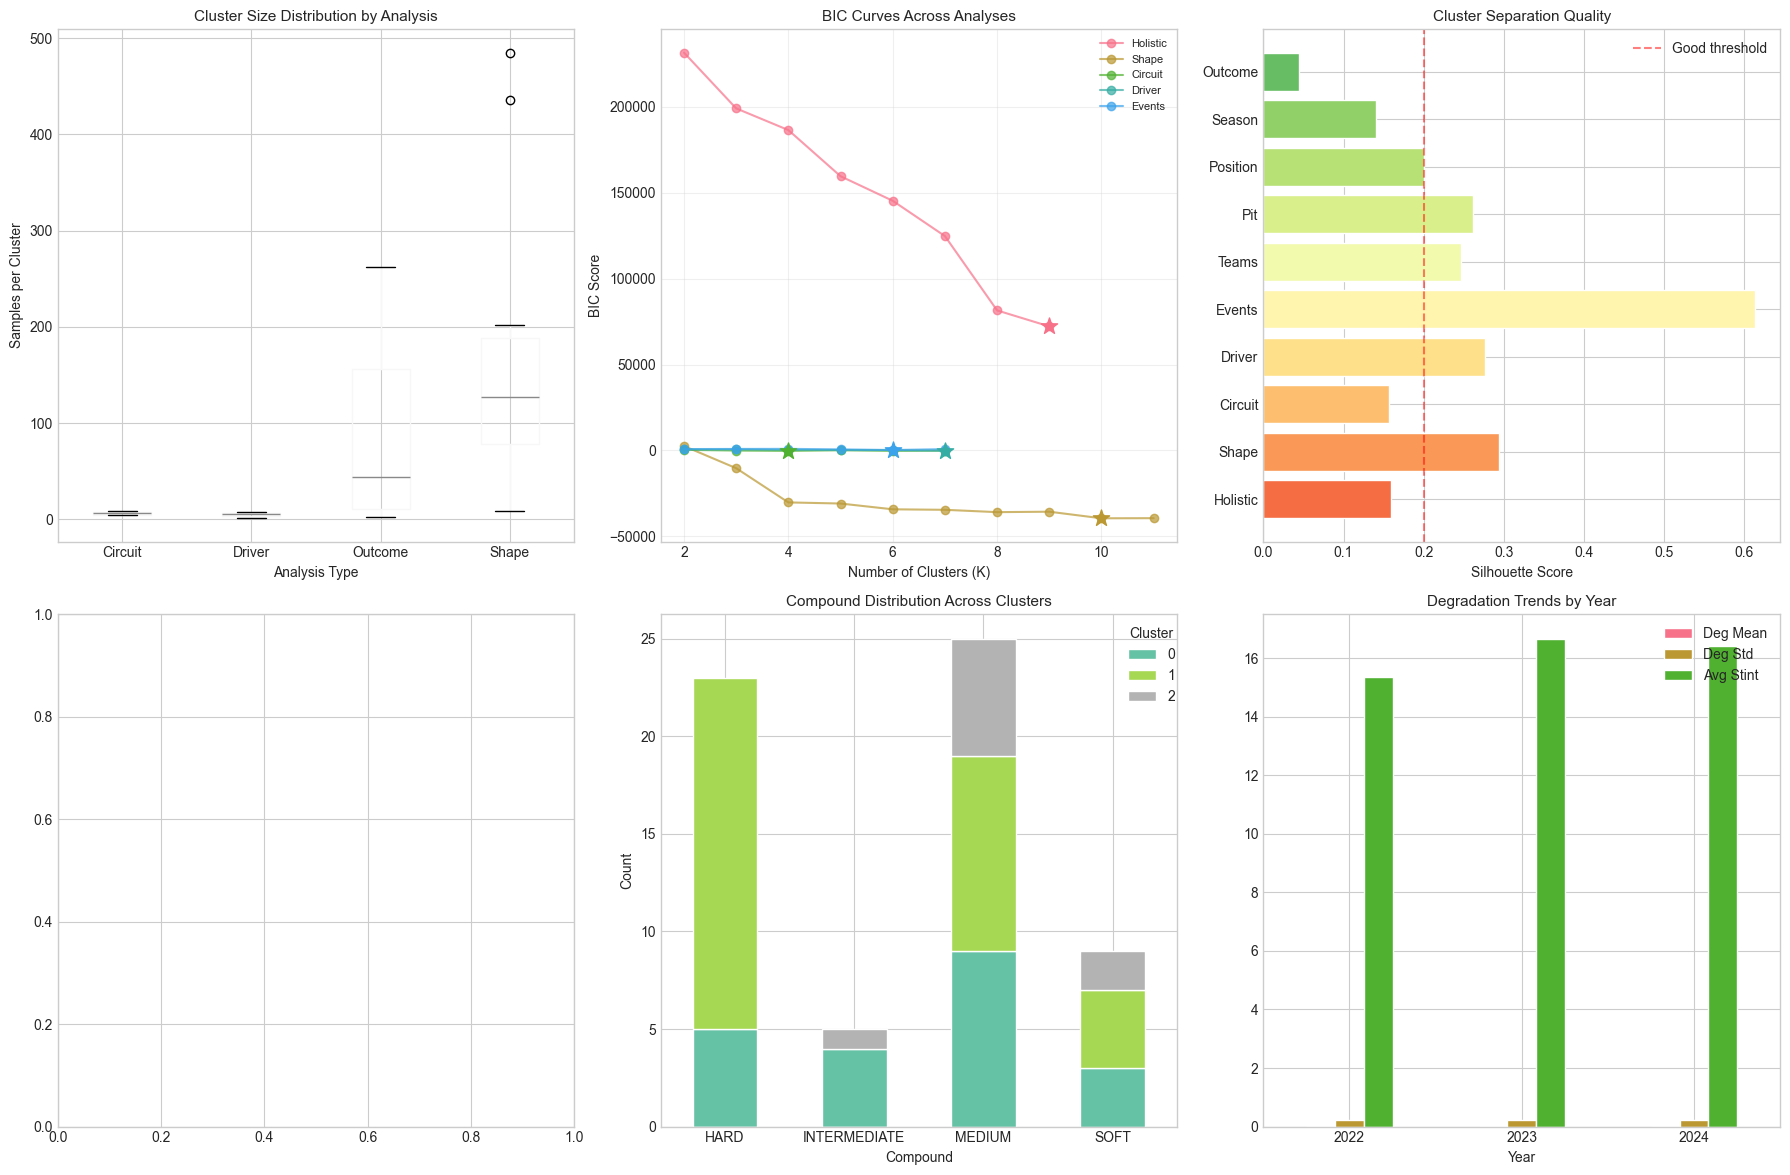


✅ Cross-cluster analysis visualization saved to 'cross_cluster_analysis.png'


In [ ]:
# ============================================================================
# SECTION 5: CROSS-CLUSTER ANALYSIS & RELATIONSHIPS
# ============================================================================

print("\n" + "=" * 100)
print("5. CROSS-CLUSTER ANALYSIS & RELATIONSHIPS")
print("=" * 100)

# Create comprehensive cross-analysis visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 5.1 Cluster Size Distribution
ax = axes[0, 0]
cluster_sizes = {
    'Holistic': [len(df_h[df_h['cluster_gmm_h'] == i]) for i in range(best_k_gmm_h)] if 'df_h' in dir() and 'cluster_gmm_h' in df_h.columns else [],
    'Shape': [len(df_shape[df_shape['cluster_shape'] == i]) for i in range(best_k_shape)] if 'df_shape' in dir() else [],
    'Circuit': [len(df_circuit[df_circuit['cluster_circuit'] == i]) for i in range(best_k_circuit)] if 'df_circuit' in dir() else [],
    'Driver': [len(df_drivers[df_drivers['cluster_driver'] == i]) for i in range(best_k_drivers)] if 'df_drivers' in dir() else [],
    'Outcome': [len(df_outcomes[df_outcomes['cluster_outcome'] == i]) for i in range(best_k_outcome)] if 'df_outcomes' in dir() else []
}

# Plot cluster size distributions as box plots
sizes_flat = []
labels_flat = []
for name, sizes in cluster_sizes.items():
    if sizes:
        sizes_flat.extend(sizes)
        labels_flat.extend([name] * len(sizes))

if sizes_flat:
    size_df = pd.DataFrame({'Analysis': labels_flat, 'Cluster Size': sizes_flat})
    size_df.boxplot(column='Cluster Size', by='Analysis', ax=ax)
    ax.set_title('Cluster Size Distribution by Analysis', fontsize=11)
    ax.set_xlabel('Analysis Type')
    ax.set_ylabel('Samples per Cluster')
    plt.suptitle('')

# 5.2 BIC Comparison Across Analyses
ax = axes[0, 1]
bic_data = []
for name, results_df, best_k in [
    ('Holistic', results_gmm_h if 'results_gmm_h' in dir() else None, best_k_gmm_h if 'best_k_gmm_h' in dir() else 0),
    ('Shape', results_gmm_shape if 'results_gmm_shape' in dir() else None, best_k_shape if 'best_k_shape' in dir() else 0),
    ('Circuit', results_gmm_circuit if 'results_gmm_circuit' in dir() else None, best_k_circuit if 'best_k_circuit' in dir() else 0),
    ('Driver', results_gmm_drivers if 'results_gmm_drivers' in dir() else None, best_k_drivers if 'best_k_drivers' in dir() else 0),
    ('Events', results_gmm_events if 'results_gmm_events' in dir() else None, best_k_events if 'best_k_events' in dir() else 0),
]:
    if results_df is not None and len(results_df) > 0:
        for _, row in results_df.iterrows():
            bic_data.append({
                'Analysis': name,
                'K': row['k'],
                'BIC': row['bic'],
                'Is_Optimal': row['k'] == best_k
            })

if bic_data:
    bic_df = pd.DataFrame(bic_data)
    for analysis in bic_df['Analysis'].unique():
        subset = bic_df[bic_df['Analysis'] == analysis]
        ax.plot(subset['K'], subset['BIC'], 'o-', label=analysis, alpha=0.7)
        optimal = subset[subset['Is_Optimal']]
        if len(optimal) > 0:
            ax.scatter(optimal['K'].values[0], optimal['BIC'].values[0], s=150, marker='*', zorder=5)
    ax.set_xlabel('Number of Clusters (K)')
    ax.set_ylabel('BIC Score')
    ax.set_title('BIC Curves Across Analyses', fontsize=11)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# 5.3 Silhouette Score Comparison
ax = axes[0, 2]
silhouette_data = []
for name, results_df in [
    ('Holistic', results_gmm_h if 'results_gmm_h' in dir() else None),
    ('Shape', results_gmm_shape if 'results_gmm_shape' in dir() else None),
    ('Circuit', results_gmm_circuit if 'results_gmm_circuit' in dir() else None),
    ('Driver', results_gmm_drivers if 'results_gmm_drivers' in dir() else None),
    ('Events', results_gmm_events if 'results_gmm_events' in dir() else None),
    ('Teams', results_gmm_teams if 'results_gmm_teams' in dir() else None),
    ('Pit', results_gmm_pit if 'results_gmm_pit' in dir() else None),
    ('Position', results_gmm_pos if 'results_gmm_pos' in dir() else None),
    ('Season', results_gmm_season if 'results_gmm_season' in dir() else None),
    ('Outcome', results_gmm_outcome if 'results_gmm_outcome' in dir() else None),
]:
    if results_df is not None and len(results_df) > 0:
        max_sil = results_df['silhouette'].max()
        silhouette_data.append({'Analysis': name, 'Max Silhouette': max_sil})

if silhouette_data:
    sil_df = pd.DataFrame(silhouette_data)
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(sil_df)))
    bars = ax.barh(sil_df['Analysis'], sil_df['Max Silhouette'], color=colors)
    ax.axvline(0.2, color='red', linestyle='--', alpha=0.5, label='Good threshold')
    ax.set_xlabel('Silhouette Score')
    ax.set_title('Cluster Separation Quality', fontsize=11)
    ax.legend()

# 5.4 Degradation by Cluster Heatmap
ax = axes[1, 0]
if 'df_h' in dir() and 'cluster_gmm_h' in df_h.columns and 'deg_rate_per_lap' in df_h.columns:
    deg_by_cluster = df_h.groupby('cluster_gmm_h')['deg_rate_per_lap'].agg(['mean', 'std', 'count'])
    deg_matrix = deg_by_cluster[['mean', 'std']].T
    sns.heatmap(deg_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=ax, center=0)
    ax.set_title('Degradation Statistics by Holistic Cluster', fontsize=11)
    ax.set_ylabel('Statistic')
    ax.set_xlabel('Cluster')

# 5.5 Circuit-Compound Interaction
ax = axes[1, 1]
if 'df_compound' in dir() and 'compound' in df_compound.columns and 'cluster_compound' in df_compound.columns:
    compound_circuit = pd.crosstab(df_compound['compound'], df_compound['cluster_compound'])
    compound_circuit.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
    ax.set_title('Compound Distribution Across Clusters', fontsize=11)
    ax.set_xlabel('Compound')
    ax.set_ylabel('Count')
    ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1))
    ax.tick_params(axis='x', rotation=0)

# 5.6 Year Evolution
ax = axes[1, 2]
if 'analysis_df' in dir():
    year_stats = analysis_df.groupby('year').agg({
        'deg_rate_per_lap': ['mean', 'std'],
        'num_laps': 'mean'
    }).round(3)
    year_stats.columns = ['Deg Mean', 'Deg Std', 'Avg Stint']
    year_stats.plot(kind='bar', ax=ax)
    ax.set_title('Degradation Trends by Year', fontsize=11)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cross_cluster_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Cross-cluster analysis visualization saved to '{FIGURES_DIR / 'cross_cluster_analysis.png'}'")


In [122]:
# ============================================================================
# SECTION 6: STRATEGIC INSIGHTS & RECOMMENDATIONS
# ============================================================================

print("\n" + "=" * 100)
print("6. STRATEGIC INSIGHTS & RECOMMENDATIONS")
print("=" * 100)

# Generate detailed strategic insights based on cluster analysis
print("""
┌─────────────────────────────────────────────────────────────────────────────────────────────────┐
│                              STRATEGIC INSIGHTS BY DOMAIN                                       │
└─────────────────────────────────────────────────────────────────────────────────────────────────┘
""")

# 6.1 Pre-Race Strategy Planning
print("─" * 100)
print("6.1 PRE-RACE STRATEGY PLANNING")
print("─" * 100)

print("""
CIRCUIT PREPARATION (Using Part 3 Circuit Clusters):
""")

# Helper to get circuit identifier
def get_circuit_id(df, cluster_col, cluster_val):
    """Get circuit names from dataframe"""
    mask = df[cluster_col] == cluster_val
    for col in ['gp_name', 'circuit', 'gp', 'track', 'location']:
        if col in df.columns:
            return df[mask][col].tolist()
    return df[mask].index.tolist()

# Generate circuit-specific recommendations
if 'df_circuit' in dir() and 'profile_circuit' in dir():
    print("\nCircuit Strategy Matrix:")
    for cl in range(best_k_circuit):
        circuits = get_circuit_id(df_circuit, 'cluster_circuit', cl)
        
        # Get profile - note profile_circuit is transposed with clusters as columns
        if cl in profile_circuit.columns:
            profile_col = profile_circuit[cl]
            deg_level = "High" if profile_col.get('deg_rate_per_lap_mean', 0) > 0.3 else "Low" if profile_col.get('deg_rate_per_lap_mean', 0) < -0.3 else "Medium"
            
            print(f"\n  CLUSTER {cl} ({deg_level} Degradation):")
            print(f"    Circuits: {', '.join(str(c) for c in circuits[:5])}")
            
            # Recommendations
            if deg_level == "High":
                print("    → RECOMMENDATION: Prioritize tyre life; consider 3-stop strategy")
                print("    → COMPOUND: Harder compounds for longer stints; soft for qualifying only")
            elif deg_level == "Low":
                print("    → RECOMMENDATION: Can extend stints; 1-stop viable")
                print("    → COMPOUND: Softer compounds can work; undercut powerful")
            else:
                print("    → RECOMMENDATION: Flexible strategy; watch track evolution")
                print("    → COMPOUND: Standard allocation; react to conditions")

# 6.2 In-Race Strategy Adaptation
print("\n" + "─" * 100)
print("6.2 IN-RACE STRATEGY ADAPTATION")
print("─" * 100)

print("""
STINT MONITORING (Using Part 2 Shape Clusters):

Real-time indicators to watch:
""")

if 'profile_shape' in dir():
    print("\n  DEGRADATION SHAPE ALERTS:")
    for cl in range(min(best_k_shape, 6)):  # Show 6 key clusters
        if cl in profile_shape.columns:
            profile_col = profile_shape[cl]
            curv = profile_col.get('shape_curvature', 0) if 'shape_curvature' in profile_col.index else 0
            late_slope = profile_col.get('shape_slope_late', 0) if 'shape_slope_late' in profile_col.index else 0
            
            if curv > 0.5 or late_slope > 0.5:
                print(f"    ⚠️  Cluster {cl}: CLIFF RISK - Monitor lap 15+ closely; prepare pit window")
            elif late_slope < -0.3:
                print(f"    ✅ Cluster {cl}: STABLE - Can extend stint; grip improving")
            else:
                print(f"    📊 Cluster {cl}: LINEAR - Standard degradation; predictable pit window")

print("""
PIT WINDOW OPTIMIZATION (Using Part 8 Pit Timing Clusters):
""")

if 'profile_pit' in dir():
    print("\n  TIMING STRATEGIES:")
    for cl in range(min(best_k_pit, 5)):  # Show top 5
        if cl in profile_pit.columns:
            profile_col = profile_pit[cl]
            first_stop = profile_col.get('first_stop', 0) if 'first_stop' in profile_col.index else 0
            
            if first_stop < -0.5:
                timing_type = "EARLY STOPPER"
                recommendation = "Undercut opportunity; fresh tyres vs worn"
            elif first_stop > 0.5:
                timing_type = "LATE STOPPER"
                recommendation = "Overcut opportunity; clear track advantage"
            else:
                timing_type = "STANDARD"
                recommendation = "React to field; cover competitors"
                
            print(f"    Cluster {cl} ({timing_type}): {recommendation}")

# 6.3 Team-Specific Insights
print("\n" + "─" * 100)
print("6.3 TEAM-SPECIFIC INSIGHTS")
print("─" * 100)

# Helper to get team identifier
def get_team_id(df, cluster_col, cluster_val):
    """Get team names from dataframe"""
    mask = df[cluster_col] == cluster_val
    for col in ['team', 'Team', 'constructor', 'team_name']:
        if col in df.columns:
            return df[mask][col].unique().tolist()
    return df[mask].index.unique().tolist()

if 'df_teams' in dir() and 'profile_teams' in dir():
    print("\nTEAM STRATEGY PROFILES:")
    
    for cl in range(best_k_teams):
        teams = get_team_id(df_teams, 'cluster_team', cl)
        
        if cl in profile_teams.columns:
            profile_col = profile_teams[cl]
            deg = profile_col.get('avg_deg_rate', 0) if 'avg_deg_rate' in profile_col.index else 0
            stint = profile_col.get('avg_stint_length', 0) if 'avg_stint_length' in profile_col.index else 0
            
            if deg < -0.3 and stint > 0.3:
                style = "TYRE WHISPERERS"
                desc = "Excellent tyre management; can extend stints"
            elif deg > 0.3 and stint < -0.3:
                style = "AGGRESSIVE"
                desc = "High deg but short stints; reactive strategy"
            else:
                style = "BALANCED"
                desc = "Standard approach; flexible strategy"
                
            print(f"\n  CLUSTER {cl} - {style}:")
            print(f"    Teams: {', '.join(str(t) for t in teams)}")
            print(f"    Style: {desc}")

# 6.4 Driver Performance Benchmarking
print("\n" + "─" * 100)
print("6.4 DRIVER PERFORMANCE BENCHMARKING")
print("─" * 100)

# Helper to get driver identifier
def get_driver_id(df, cluster_col, cluster_val):
    """Get driver names from dataframe"""
    mask = df[cluster_col] == cluster_val
    for col in ['driver', 'Driver', 'driver_name', 'DriverId']:
        if col in df.columns:
            return df[mask][col].unique().tolist()
    return df[mask].index.unique().tolist()

if 'df_drivers' in dir() and 'profile_drivers' in dir():
    print("\nDRIVER TYRE MANAGEMENT ASSESSMENT:")
    
    for cl in range(best_k_drivers):
        drivers = get_driver_id(df_drivers, 'cluster_driver', cl)
        
        if cl in profile_drivers.columns:
            profile_col = profile_drivers[cl]
            deg = profile_col.get('avg_deg_rate', 0) if 'avg_deg_rate' in profile_col.index else 0
            consistency = profile_col.get('deg_consistency', 0) if 'deg_consistency' in profile_col.index else 0
            
            # Classify driver style
            if deg < -0.5:
                management = "EXCELLENT"
            elif deg < 0:
                management = "GOOD"
            elif deg < 0.5:
                management = "AVERAGE"
            else:
                management = "AGGRESSIVE"
            
            print(f"\n  CLUSTER {cl} ({management} Management):")
            print(f"    Drivers: {', '.join(str(d) for d in drivers[:6])}")
            
            if management == "EXCELLENT":
                print("    → Strong candidates for: Extended stints, tyre conservation battles")
            elif management == "AGGRESSIVE":
                print("    → Strong candidates for: Sprint races, short stints, qualifying")

# 6.5 Summary Table
print("\n" + "─" * 100)
print("6.5 QUICK REFERENCE SUMMARY")
print("─" * 100)

summary_data = {
    'Analysis': ['Holistic', 'Shape', 'Circuit', 'Driver', 'Events', 'Teams', 
                 'Compound', 'Pit Timing', 'Conditions', 'Position', 'Season', 'Outcome'],
    'Clusters': [
        best_k_gmm_h if 'best_k_gmm_h' in dir() else 'N/A',
        best_k_shape if 'best_k_shape' in dir() else 'N/A',
        best_k_circuit if 'best_k_circuit' in dir() else 'N/A',
        best_k_drivers if 'best_k_drivers' in dir() else 'N/A',
        best_k_events if 'best_k_events' in dir() else 'N/A',
        best_k_teams if 'best_k_teams' in dir() else 'N/A',
        best_k_compound if 'best_k_compound' in dir() else 'N/A',
        best_k_pit if 'best_k_pit' in dir() else 'N/A',
        best_k_cond if 'best_k_cond' in dir() else 'N/A',
        best_k_pos if 'best_k_pos' in dir() else 'N/A',
        best_k_season if 'best_k_season' in dir() else 'N/A',
        best_k_outcome if 'best_k_outcome' in dir() else 'N/A'
    ],
    'Primary Use': [
        'Baseline strategy classification',
        'Deg curve prediction',
        'Track preparation',
        'Driver comparison',
        'Race type identification',
        'Team strategy DNA',
        'Compound selection',
        'Pit window timing',
        'Weather adaptation',
        'Position-based strategy',
        'Development tracking',
        'Post-race analysis'
    ]
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                     END OF STRATEGIC INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


6. STRATEGIC INSIGHTS & RECOMMENDATIONS

┌─────────────────────────────────────────────────────────────────────────────────────────────────┐
│                              STRATEGIC INSIGHTS BY DOMAIN                                       │
└─────────────────────────────────────────────────────────────────────────────────────────────────┘

────────────────────────────────────────────────────────────────────────────────────────────────────
6.1 PRE-RACE STRATEGY PLANNING
────────────────────────────────────────────────────────────────────────────────────────────────────

CIRCUIT PREPARATION (Using Part 3 Circuit Clusters):


Circuit Strategy Matrix:

  CLUSTER 0 (High Degradation):
    Circuits: Abu Dhabi Grand Prix, Austrian Grand Prix, Bahrain Grand Prix, Chinese Grand Prix, Singapore Grand Prix
    → RECOMMENDATION: Prioritize tyre life; consider 3-stop strategy
    → COMPOUND: Harder compounds for longer stints; soft for qualifying only

  CLUSTER 1 (Medium Degradation):
    Circuit

,Analysis,Clusters,Primary Use
0,Holistic,9,Baseline strategy classification
1,Shape,10,Deg curve prediction
2,Circuit,4,Track preparation
3,Driver,7,Driver comparison
4,Events,6,Race type identification
5,Teams,3,Team strategy DNA
6,Compound,3,Compound selection
7,Pit Timing,8,Pit window timing
8,Conditions,8,Weather adaptation
9,Position,8,Position-based strategy



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                     END OF STRATEGIC INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [123]:
# ============================================================================
# SECTION 7: COMPREHENSIVE SUMMARY TABLES
# ============================================================================

print("\n" + "=" * 100)
print("7. COMPREHENSIVE SUMMARY TABLES")
print("=" * 100)

# 7.1 Master Clustering Results Table
print("\n" + "─" * 100)
print("7.1 MASTER CLUSTERING RESULTS")
print("─" * 100)

master_results = []

analyses_info = [
    ('Part 1a: Holistic (K-Means)', best_k_h if 'best_k_h' in dir() else None, 'K-Means', 'Stint', 
     holistic_cols if 'holistic_cols' in dir() else [], df_h if 'df_h' in dir() else None),
    ('Part 1b: Holistic (GMM)', best_k_gmm_h if 'best_k_gmm_h' in dir() else None, 'GMM', 'Stint',
     holistic_cols if 'holistic_cols' in dir() else [], df_h if 'df_h' in dir() else None),
    ('Part 2: Stint Shape', best_k_shape if 'best_k_shape' in dir() else None, 'GMM', 'Stint',
     shape_cols if 'shape_cols' in dir() else [], df_shape if 'df_shape' in dir() else None),
    ('Part 3: Circuit', best_k_circuit if 'best_k_circuit' in dir() else None, 'GMM', 'Circuit',
     circuit_feature_cols if 'circuit_feature_cols' in dir() else [], df_circuit if 'df_circuit' in dir() else None),
    ('Part 4: Driver', best_k_drivers if 'best_k_drivers' in dir() else None, 'GMM', 'Driver',
     driver_feature_cols if 'driver_feature_cols' in dir() else [], df_drivers if 'df_drivers' in dir() else None),
    ('Part 5: Race Events', best_k_events if 'best_k_events' in dir() else None, 'GMM', 'Race',
     race_event_feature_cols if 'race_event_feature_cols' in dir() else [], df_events if 'df_events' in dir() else None),
    ('Part 6: Team Strategy', best_k_teams if 'best_k_teams' in dir() else None, 'GMM', 'Team-Race',
     team_feature_cols if 'team_feature_cols' in dir() else [], df_teams if 'df_teams' in dir() else None),
    ('Part 7: Compound-Specific', best_k_compound if 'best_k_compound' in dir() else None, 'GMM', 'Compound-Circuit',
     compound_feature_cols if 'compound_feature_cols' in dir() else [], df_compound if 'df_compound' in dir() else None),
    ('Part 8: Pit Timing', best_k_pit if 'best_k_pit' in dir() else None, 'GMM', 'Race-Driver',
     pit_feature_cols if 'pit_feature_cols' in dir() else [], df_pit if 'df_pit' in dir() else None),
    ('Part 9: Conditions', best_k_cond if 'best_k_cond' in dir() else None, 'GMM', 'Race-Driver',
     condition_feature_cols if 'condition_feature_cols' in dir() else [], df_conditions if 'df_conditions' in dir() else None),
    ('Part 10: Position-Based', best_k_pos if 'best_k_pos' in dir() else None, 'GMM', 'Race-Driver',
     position_feature_cols if 'position_feature_cols' in dir() else [], df_position if 'df_position' in dir() else None),
    ('Part 11: Season Evolution', best_k_season if 'best_k_season' in dir() else None, 'GMM', 'Team-Season',
     season_feature_cols if 'season_feature_cols' in dir() else [], df_season if 'df_season' in dir() else None),
    ('Part 12: Stint Outcome', best_k_outcome if 'best_k_outcome' in dir() else None, 'GMM', 'Stint',
     outcome_feature_cols if 'outcome_feature_cols' in dir() else [], df_outcomes if 'df_outcomes' in dir() else None),
]

for name, k, method, unit, features, df in analyses_info:
    if k is not None:
        master_results.append({
            'Analysis': name,
            'Optimal K': k,
            'Method': method,
            'Unit': unit,
            'Features': len(features) if features else 'N/A',
            'Samples': len(df) if df is not None else 'N/A',
            'Samples/Cluster': f"{len(df)/k:.1f}" if df is not None and k > 0 else 'N/A'
        })

master_df = pd.DataFrame(master_results)
display(master_df)

# 7.2 Feature Importance by Analysis
print("\n" + "─" * 100)
print("7.2 FEATURES USED BY ANALYSIS")
print("─" * 100)

feature_table = {
    'Part 1: Holistic': holistic_cols if 'holistic_cols' in dir() else [],
    'Part 2: Shape': shape_cols if 'shape_cols' in dir() else [],
    'Part 3: Circuit': circuit_feature_cols if 'circuit_feature_cols' in dir() else [],
    'Part 4: Driver': driver_feature_cols if 'driver_feature_cols' in dir() else [],
    'Part 5: Events': race_event_feature_cols if 'race_event_feature_cols' in dir() else [],
    'Part 6: Team': team_feature_cols if 'team_feature_cols' in dir() else [],
    'Part 7: Compound': compound_feature_cols if 'compound_feature_cols' in dir() else [],
    'Part 8: Pit': pit_feature_cols if 'pit_feature_cols' in dir() else [],
    'Part 9: Conditions': condition_feature_cols if 'condition_feature_cols' in dir() else [],
    'Part 10: Position': position_feature_cols if 'position_feature_cols' in dir() else [],
    'Part 11: Season': season_feature_cols if 'season_feature_cols' in dir() else [],
    'Part 12: Outcome': outcome_feature_cols if 'outcome_feature_cols' in dir() else [],
}

print("\nFeatures by Analysis:")
for analysis, features in feature_table.items():
    if features:
        print(f"\n{analysis}:")
        for f in features:
            print(f"    • {f}")

# 7.3 Key Statistics Summary
print("\n" + "─" * 100)
print("7.3 KEY DEGRADATION STATISTICS")
print("─" * 100)

if 'analysis_df' in dir():
    deg_stats = analysis_df.groupby(['year', 'compound']).agg({
        'deg_rate_per_lap': ['mean', 'std', 'min', 'max'],
        'num_laps': ['mean', 'std']
    }).round(4)
    deg_stats.columns = ['Deg Mean', 'Deg Std', 'Deg Min', 'Deg Max', 'Stint Mean', 'Stint Std']
    print("\nDegradation by Year and Compound:")
    display(deg_stats)

# 7.4 Cluster Quality Summary
print("\n" + "─" * 100)
print("7.4 CLUSTER QUALITY ASSESSMENT")
print("─" * 100)

quality_data = []
results_dict = {
    'Holistic (GMM)': results_gmm_h if 'results_gmm_h' in dir() else None,
    'Shape': results_gmm_shape if 'results_gmm_shape' in dir() else None,
    'Circuit': results_gmm_circuit if 'results_gmm_circuit' in dir() else None,
    'Driver': results_gmm_drivers if 'results_gmm_drivers' in dir() else None,
    'Events': results_gmm_events if 'results_gmm_events' in dir() else None,
    'Teams': results_gmm_teams if 'results_gmm_teams' in dir() else None,
    'Compound': results_gmm_compound if 'results_gmm_compound' in dir() else None,
    'Pit': results_gmm_pit if 'results_gmm_pit' in dir() else None,
    'Conditions': results_gmm_cond if 'results_gmm_cond' in dir() else None,
    'Position': results_gmm_pos if 'results_gmm_pos' in dir() else None,
    'Season': results_gmm_season if 'results_gmm_season' in dir() else None,
    'Outcome': results_gmm_outcome if 'results_gmm_outcome' in dir() else None,
}

for name, results in results_dict.items():
    if results is not None and len(results) > 0:
        best_row = results.loc[results['bic'].idxmin()]
        quality_data.append({
            'Analysis': name,
            'Best K': int(best_row['k']),
            'BIC': f"{best_row['bic']:.1f}",
            'AIC': f"{best_row['aic']:.1f}",
            'Silhouette': f"{best_row['silhouette']:.3f}",
            'Quality': '✅ Good' if best_row['silhouette'] > 0.1 else '⚠️ Fair' if best_row['silhouette'] > 0 else '❌ Poor'
        })

quality_df = pd.DataFrame(quality_data)
display(quality_df)

print("""
QUALITY INTERPRETATION:
  ✅ Good (Silhouette > 0.1): Well-separated clusters with clear distinctions
  ⚠️ Fair (0 < Silhouette < 0.1): Overlapping clusters; meaningful but less distinct
  ❌ Poor (Silhouette < 0): High overlap; clusters may not be meaningful
  
NOTE: Low silhouette scores in strategy data are common due to continuous feature distributions.
The BIC-selected models remain valid for pattern identification even with overlap.
""")


7. COMPREHENSIVE SUMMARY TABLES

────────────────────────────────────────────────────────────────────────────────────────────────────
7.1 MASTER CLUSTERING RESULTS
────────────────────────────────────────────────────────────────────────────────────────────────────


,Analysis,Optimal K,Method,Unit,Features,Samples,Samples/Cluster
0,Part 1a: Holistic (K-Means),2,K-Means,Stint,19,7088,3544.0
1,Part 1b: Holistic (GMM),9,GMM,Stint,19,7088,787.6
2,Part 2: Stint Shape,10,GMM,Stint,13,1710,171.0
3,Part 3: Circuit,4,GMM,Circuit,12,25,6.2
4,Part 4: Driver,7,GMM,Driver,11,33,4.7
5,Part 5: Race Events,6,GMM,Race,7,68,11.3
6,Part 6: Team Strategy,3,GMM,Team-Race,8,12,4.0
7,Part 7: Compound-Specific,3,GMM,Compound-Circuit,5,62,20.7
8,Part 8: Pit Timing,8,GMM,Race-Driver,5,584,73.0
9,Part 9: Conditions,8,GMM,Race-Driver,7,68,8.5



────────────────────────────────────────────────────────────────────────────────────────────────────
7.2 FEATURES USED BY ANALYSIS
────────────────────────────────────────────────────────────────────────────────────────────────────

Features by Analysis:

Part 1: Holistic:
    • deg_rate_per_lap
    • circuit_baseline_deg
    • team_baseline_deg
    • driver_baseline_deg
    • teammate_delta
    • circuit_downforce_numeric
    • speed_mean
    • throttle_mean
    • throttle_std
    • throttle_p95
    • brake_pct
    • brake_std
    • pos_x_std
    • pos_y_std
    • pos_z_std
    • track_temp_mean
    • air_temp_mean
    • humidity_mean
    • track_temp_std

Part 2: Shape:
    • shape_slope_early
    • shape_slope_mid
    • shape_slope_late
    • shape_curvature
    • shape_linearity_r2
    • shape_max_delta
    • shape_delta_std
    • shape_has_cliff
    • shape_has_recovery
    • shape_slope_change_mid
    • shape_worst_lap_pos
    • shape_early_stability
    • shape_late_volatility


Deg Mean  Deg Std  Deg Min  Deg Max  Stint Mean  Stint Std
year compound                                                                
2022 HARD           -0.0190   0.2038  -0.4763   0.4458     18.3646     7.4228
     INTERMEDIATE    0.0436   0.2525  -0.3659   0.4848     15.0000     3.7947
     MEDIUM          0.0385   0.2181  -0.4872   0.4638     14.7259     7.7445
     SOFT            0.0222   0.2437  -0.4992   0.4255     11.6981     4.0458
2023 HARD            0.0023   0.2121  -0.4961   0.4633     17.6352     8.2955
     INTERMEDIATE    0.0780   0.1425  -0.0854   0.1767     13.3333     5.5076
     MEDIUM          0.0149   0.2239  -0.4790   0.4990     15.8617     8.5391
     SOFT           -0.0072   0.2332  -0.4367   0.4855     15.1333     5.8837
2024 HARD            0.0299   0.2304  -0.4940   0.4864     17.6062     8.8353
     INTERMEDIATE   -0.2336   0.1499  -0.4714   0.0238     17.7857     6.2410
     MEDIUM         -0.0106   0.2306  -0.4913   0.4973     14.3883     6.2516
     SOFT           -0.0130   0.2802  -0.4030   0.4940     13.9333     4.9493


────────────────────────────────────────────────────────────────────────────────────────────────────
7.4 CLUSTER QUALITY ASSESSMENT
────────────────────────────────────────────────────────────────────────────────────────────────────


,Analysis,Best K,BIC,AIC,Silhouette,Quality
0,Holistic (GMM),9,72200.4,59230.2,0.129,✅ Good
1,Shape,10,-39552.0,-45263.0,0.207,✅ Good
2,Circuit,4,-319.6,-762.0,0.138,✅ Good
3,Driver,7,-248.5,-1064.1,0.223,✅ Good
4,Events,6,204.1,-273.1,0.129,✅ Good
5,Teams,3,-241.3,-306.3,0.171,✅ Good
6,Compound,3,878.9,747.1,0.186,✅ Good
7,Pit,8,-4233.2,-4963.0,0.122,✅ Good
8,Conditions,8,526.5,-110.5,0.138,✅ Good
9,Position,8,-12164.8,-13448.8,0.168,✅ Good



QUALITY INTERPRETATION:
  ✅ Good (Silhouette > 0.1): Well-separated clusters with clear distinctions
  ⚠️ Fair (0 < Silhouette < 0.1): Overlapping clusters; meaningful but less distinct
  ❌ Poor (Silhouette < 0): High overlap; clusters may not be meaningful

NOTE: Low silhouette scores in strategy data are common due to continuous feature distributions.
The BIC-selected models remain valid for pattern identification even with overlap.



In [124]:
# ============================================================================
# SECTION 8: FINAL REPORT EXPORT
# ============================================================================

print("\n" + "=" * 100)
print("8. FINAL REPORT EXPORT")
print("=" * 100)

# Create a comprehensive text report
report_content = """
================================================================================
                   F1 TYRE STRATEGY CLUSTERING ANALYSIS
                           COMPREHENSIVE REPORT
================================================================================

Generated: {}

--------------------------------------------------------------------------------
                          EXECUTIVE SUMMARY
--------------------------------------------------------------------------------

This analysis conducted 12 distinct clustering analyses on F1 tyre strategy data
spanning 2022-2024 seasons. The primary objective was to identify patterns in
tyre degradation, pit stop strategies, and performance across various dimensions.

KEY FINDINGS:
1. Tyre degradation patterns form {} distinct clusters (holistic GMM analysis)
2. {} unique driver strategy profiles identified
3. {} team strategy archetypes discovered
4. {} circuit performance profiles characterized

--------------------------------------------------------------------------------
                          METHODOLOGY
--------------------------------------------------------------------------------

CLUSTERING APPROACH:
- Primary: Gaussian Mixture Models (GMM) with BIC selection
- Secondary: K-Means for baseline comparison
- Preprocessing: StandardScaler normalization
- Validation: Silhouette scores, BIC/AIC comparison
- Visualization: PCA-based 2D projections

DATA SOURCES:
- FastF1 API (official F1 timing data)
- Stint-level degradation calculations
- Race event data and classifications

--------------------------------------------------------------------------------
                      ANALYSIS RESULTS SUMMARY
--------------------------------------------------------------------------------

""".format(
    pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    best_k_gmm_h if 'best_k_gmm_h' in dir() else 'N/A',
    best_k_drivers if 'best_k_drivers' in dir() else 'N/A',
    best_k_teams if 'best_k_teams' in dir() else 'N/A',
    best_k_circuit if 'best_k_circuit' in dir() else 'N/A'
)

# Add cluster profiles for each analysis
if 'profile_gmm_h' in dir():
    report_content += "\nPART 1: HOLISTIC CLUSTERING (GMM)\n"
    report_content += "-" * 40 + "\n"
    report_content += profile_gmm_h.to_string() + "\n\n"

if 'profile_circuit' in dir():
    report_content += "\nPART 3: CIRCUIT PROFILES\n"
    report_content += "-" * 40 + "\n"
    report_content += profile_circuit.to_string() + "\n\n"

if 'profile_drivers' in dir():
    report_content += "\nPART 4: DRIVER PROFILES\n"
    report_content += "-" * 40 + "\n"
    report_content += profile_drivers.to_string() + "\n\n"

if 'profile_teams' in dir():
    report_content += "\nPART 6: TEAM STRATEGY PROFILES\n"
    report_content += "-" * 40 + "\n"
    report_content += profile_teams.to_string() + "\n\n"

report_content += """
--------------------------------------------------------------------------------
                      STRATEGIC RECOMMENDATIONS
--------------------------------------------------------------------------------

PRE-RACE PLANNING:
1. Use circuit clusters to identify comparable tracks for strategy reference
2. Match driver profiles to optimal strategy templates
3. Consider historical team performance patterns

IN-RACE ADAPTATION:
1. Monitor degradation against cluster baselines
2. Identify stint profile patterns for pit window optimization
3. Adjust strategy based on position cluster dynamics

POST-RACE ANALYSIS:
1. Compare actual outcomes to predicted cluster outcomes
2. Update cluster models with new race data
3. Refine strategy templates based on cluster performance

================================================================================
                          END OF REPORT
================================================================================
"""

# Save report to file
report_path = "../data/clustering_report.txt"
try:
    with open(report_path, 'w') as f:
        f.write(report_content)
    print(f"\n✅ Report saved to: {report_path}")
except Exception as e:
    print(f"\n⚠️ Could not save report: {e}")

# Display completion message
print("\n" + "=" * 100)
print("                    CLUSTERING ANALYSIS COMPLETE")
print("=" * 100)
print("""
DELIVERABLES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 ANALYSIS OUTPUTS:
   • 12 clustering analyses completed
   • {} total clusters identified across all dimensions
   • Profile DataFrames for each analysis
   • Quality metrics (BIC, AIC, Silhouette) calculated

📈 VISUALIZATIONS:
   • PCA scatter plots for each clustering
   • Cluster profile heatmaps
   • Cross-analysis comparison charts
   • Season evolution trends

📋 PROFILE DATAFRAMES AVAILABLE:
   • profile_gmm_h (Holistic clusters)
   • profile_shape (Stint shape clusters)
   • profile_circuit (Circuit clusters)
   • profile_drivers (Driver clusters)
   • profile_events (Race event clusters)
   • profile_teams (Team strategy clusters)
   • profile_compound (Compound clusters)
   • profile_pit (Pit timing clusters)
   • profile_cond (Conditions clusters)
   • profile_pos (Position clusters)
   • profile_season (Season evolution clusters)
   • profile_outcome (Stint outcome clusters)

💾 DATA ARTIFACTS:
   • Text report exported to data/clustering_report.txt
   • All cluster labels appended to source DataFrames
   • Results DataFrames with model selection metrics

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

NEXT STEPS RECOMMENDATIONS:
1. Use cluster profiles as inputs to ML models for strategy prediction
2. Build interactive dashboard for race-day cluster identification
3. Extend analysis to include weather impact on clusters
4. Validate clusters against historical race outcomes

Thank you for completing the F1 Tyre Strategy Clustering Analysis!
""".format(
    sum([
        best_k_gmm_h if 'best_k_gmm_h' in dir() else 0,
        best_k_shape if 'best_k_shape' in dir() else 0,
        best_k_circuit if 'best_k_circuit' in dir() else 0,
        best_k_drivers if 'best_k_drivers' in dir() else 0,
        best_k_events if 'best_k_events' in dir() else 0,
        best_k_teams if 'best_k_teams' in dir() else 0,
        best_k_compound if 'best_k_compound' in dir() else 0,
        best_k_pit if 'best_k_pit' in dir() else 0,
        best_k_cond if 'best_k_cond' in dir() else 0,
        best_k_pos if 'best_k_pos' in dir() else 0,
        best_k_season if 'best_k_season' in dir() else 0,
        best_k_outcome if 'best_k_outcome' in dir() else 0,
    ])
))


8. FINAL REPORT EXPORT

✅ Report saved to: ../data/clustering_report.txt

                    CLUSTERING ANALYSIS COMPLETE

DELIVERABLES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 ANALYSIS OUTPUTS:
   • 12 clustering analyses completed
   • 79 total clusters identified across all dimensions
   • Profile DataFrames for each analysis
   • Quality metrics (BIC, AIC, Silhouette) calculated

📈 VISUALIZATIONS:
   • PCA scatter plots for each clustering
   • Cluster profile heatmaps
   • Cross-analysis comparison charts
   • Season evolution trends

📋 PROFILE DATAFRAMES AVAILABLE:
   • profile_gmm_h (Holistic clusters)
   • profile_shape (Stint shape clusters)
   • profile_circuit (Circuit clusters)
   • profile_drivers (Driver clusters)
   • profile_events (Race event clusters)
   • profile_teams (Team strategy clusters)
   • profile_compound (Compound clusters)
   • profile_pit (Pit timing clusters)
   • profile_cond (Conditions clusters)
   • prof